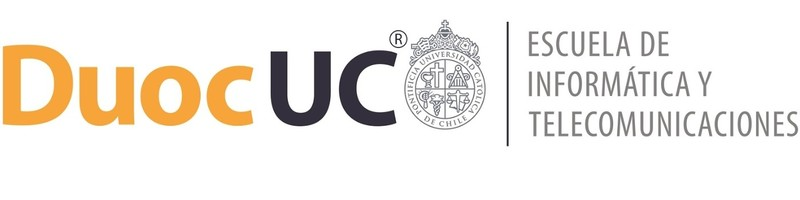

# Metodología CRISP-DM en Notebook
## Spotify Tracks: preparación, modelamiento supervisado y no supervisado

**Asignatura:** Machine Learning (MLY1101)
**Institución:** Duoc UC
**Evaluación:** Evaluación Parcial N.º 2 (continuación de la EP1)
**Integrantes:** Alejandra González, Constanza González, Diego Villar.

El proyecto estudia si los atributos medibles de una canción permiten anticipar su
popularidad en Spotify. La EP1 dejó una base limpia y un pipeline de preparación; esta
EP2 revisa y corrige esa base, incorpora el **artista** como predictor, entrena y compara
**4 modelos de regresión**, **4 modelos de clasificación** (con comparación de métodos de
balanceo) y **2 modelos no supervisados (K-Means y DBSCAN)**, y traduce los resultados a
recomendaciones de negocio.

### Metodología y alcance de la entrega

| Fase CRISP-DM | Contenido | Estado en EP2 |
|---|---|---|
| 1. Business Understanding | Problema, objetivos, KPIs (actualizados para EP2) | Completa |
| 2. Data Understanding | Carga, estructura, calidad y exploración inicial | Completa (EP1) |
| 3. Data Preparation | Limpieza, EDA, representación 1 canción = 1 fila, partición sin fuga, codificación del artista, targets | Completa (corregida en EP2) |
| 4. Modeling | 4 regresiones, 4 clasificaciones + balanceo, K-Means y DBSCAN | **Nueva en EP2** |
| 5. Evaluation | Métricas en prueba, KPIs, sesgo por género, importancia de variables | **Nueva en EP2** |
| 6. Deployment | Modelos serializados, uso y plan de monitoreo | **Propuesta en EP2** |

CRISP-DM es iterativa: la revisión de la EP1 (sección 0) es justamente una vuelta a la
Fase 3 motivada por lo que exige el modelamiento.

> **Tiempo de ejecución:** "Restart & Run All" tarda aproximadamente 35–45 minutos en
> un equipo de 4 núcleos (la mayor parte corresponde a la validación cruzada de la
> Fase 4). Dependencias: `pip install -r requirements.txt`.

## 0. Revisión del notebook EP1 y correcciones aplicadas

Antes de modelar se revisó el notebook de la EP1 completo. Se mantienen sus reglas de
limpieza y su EDA (Fases 1–3), pero se detectaron los siguientes problemas, que se
corrigen en este notebook:

| # | Problema detectado en EP1 | Riesgo | Corrección en EP2 |
|---|---|---|---|
| 1 | El README planteaba **regresión** (MAE, RMSE, R²) y el notebook **clasificación** (accuracy, F1). | Objetivo y KPIs inconsistentes. | Se abordan ambos enfoques, tal como pide la pauta EP2, con KPIs unificados (sección 1.1). |
| 2 | Partición agrupada solo por `id_cancion`. Hay ~4.700 pares *artista + título* publicados con **IDs distintos** (reediciones, recopilatorios); cerca de la mitad tiene audio idéntico. | **Fuga de información**: la misma grabación puede quedar en train y en test con otro ID, inflando las métricas. | Partición y validación cruzada agrupadas por `clave_cancion` = artista + título normalizados (sección 3.12). |
| 3 | El pipeline usaba **una fila por canción-género**; la representación multi-género (1 canción = 1 fila) se construyó pero no se usó. | Canciones con varios géneros pesan más en el entrenamiento y en las métricas. | El modelamiento usa 1 canción = 1 fila con géneros *multi-hot* (sección 3.11). |
| 4 | `spotify_multigenero.csv` se construía desde `df_limpio`, con el compás **ya imputado** fuera del pipeline. | Imputación aprendida fuera de la validación cruzada. | Se construye desde `df_base` (compás sin imputar); la moda se aprende dentro del pipeline en cada pliegue. |
| 5 | Target de clasificación por **terciles** aprendidos en train (cortes ≈ 22 y 45). | "Alto" incluía canciones con popularidad 45, sin significado de negocio; clases artificialmente balanceadas que ocultan el desbalance real. | Umbrales de negocio fijos: bajo < 30, medio 30–59, alto ≥ 60 (sección 3.14). Al ser fijos, no se aprenden de los datos y no generan fuga. |
| 6 | `RUTA_DATOS = '../data/raw/...'` (ruta relativa fija). | Falla si el notebook no se ejecuta desde `notebooks/` (p. ej., Colab). | `RUTA_DATOS = None` por defecto: se usa la búsqueda automática de rutas candidatas. |
| 7 | Celdas de forma: "Conclusiones Fase 3" vacía, referencia a una celda "más abajo" que estaba arriba, código de sesgos antes de su título, celda que solo imprimía `sys.executable`. | Documentación incompleta. | Se completan y reordenan. |

Las reglas de limpieza de la EP1 (eliminación de 158 filas, imputación de álbum,
tratamiento de compás) **no cambian**: siguen justificadas y el balance de filas es el mismo.

### 0.1 Decisiones de diseño del equipo (versión 2 del EP2)

| Decisión | Motivo | Implementación |
|---|---|---|
| **Incluir el artista** en el pipeline | El equipo considera que el artista influye fuertemente en la popularidad (reputación, base de seguidores). | *Target encoding* suavizado con *cross-fitting* (sección 3.13); en canciones con varios artistas se usa el **máximo**. Se compara siempre contra el modelo sin artista. |
| **K-Means y DBSCAN** como modelos no supervisados | Requisito de la asignatura (laboratorio de estrategia de modelamiento). | DBSCAN reemplaza al clustering jerárquico de la versión anterior (sección 4.5). |
| **Árbol de decisión** en lugar de Ridge (versión 3) | Se pidió un cuarto modelo de regresión que no sea lineal. | `DecisionTreeRegressor` (sección 4.2). |
| **Mismo objetivo para K-Means y DBSCAN** (versión 3) | Poder compararlos y declarar un ganador. | Ambos agrupan por audio y se evalúan contra el **macro-género** (10 familias), con PCA 3D (secciones 4.4–4.6). |
| **ROC-AUC como métrica principal** de clasificación (versión 3) | Recomendación docente. | Selección del balanceo, de los hiperparámetros y del ganador por ROC-AUC; curvas ROC en la Fase 5. |

Los resultados de la versión sin artista se conservan en `data/processed/*_sin_artista.csv`
como referencia.

## Fase 1: Business Understanding

---


### 1.1 Contexto, problema de negocio, objetivos y KPIs

### Problema de negocio
Un equipo de inteligencia musical necesita determinar si los **atributos medibles** de una
canción (características de audio, género, contenido explícito) y el **historial de su
artista** permiten anticipar su
nivel de popularidad, para apoyar decisiones de curaduría editorial, armado de playlists y
promoción.

### Objetivo general
Desarrollar, comparar y evaluar modelos de Machine Learning que estimen la popularidad de
una canción, tanto como **valor continuo (regresión, 0–100)** como **nivel de popularidad
(clasificación: bajo / medio / alto)**, y descubrir mediante **aprendizaje no supervisado**
perfiles sonoros, nichos y canciones atípicas útiles para la curaduría.

### Objetivos específicos
- **Analítico:** identificar qué atributos se asocian con mayor popularidad y cuánto
  aporta el artista frente a las características de la canción.
- **Regresión:** entrenar y comparar 4 algoritmos contra un baseline, con MAE, RMSE y R².
- **Clasificación:** entrenar y comparar 4 algoritmos, evaluando distintos métodos de
  balanceo de clases, con F1 macro, accuracy y recall de la clase "alto".
- **No supervisado:** agrupar las canciones solo por su sonido con **K-Means y DBSCAN** (mismo
  objetivo, mismas variables y misma evaluación) y comprobar cuál recupera mejor las familias
  musicales del catálogo (**macro-géneros**).
- **Ética:** cuantificar el error del modelo por género para detectar sesgos.

### KPIs
| KPI | Tipo | Umbral | Origen |
|-----|------|--------|--------|
| Cobertura de datos (filas conservadas) | Calidad | ≥ 99% | EP1 |
| Canciones (artista + título) compartidas entre train y test | Calidad | 0 | EP1, reforzado en EP2 |
| MAE | Regresión | < 10 puntos | EP1 (README) |
| RMSE | Regresión | < 15 puntos | EP1 (README) |
| R² | Regresión | > 0,20 | EP1 (README) |
| Accuracy | Clasificación | > 0,50 | EP1 (notebook) |
| F1 macro | Clasificación | > 0,45 | EP1 (notebook) |
| Recall de la clase "alto" | Clasificación | ≥ 0,60 | EP2: no dejar pasar posibles éxitos |
| ROC-AUC macro (one-vs-rest) | Clasificación | ≥ 0,80 | EP2 v3: recomendación docente (métrica principal) |
| Silhouette del K-Means | No supervisado | ≥ 0,15 | EP2: estructura de grupos al menos débil-moderada |

Todos los umbrales se fijan **antes** de mirar el conjunto de prueba. El modelo se
considera útil para el negocio si además **supera claramente al baseline** (predecir la
media o la clase más frecuente).

### 1.2 Fuente de datos y herramientas colaborativas

**Fuente:** Spotify_Tracks_Dataset.csv — Kaggle (*Spotify Tracks Dataset*, MaharshiPandya).

**Limitación:** sin fecha de extracción ni versión de API. La popularidad puede estar desactualizada.

| Herramienta | Uso |
|-------------|-----|
| Python / pandas / numpy | Manipulación de datos |
| matplotlib / seaborn | Visualización |
| scikit-learn | Pipeline ML |
| Jupyter Notebook | Documentación reproducible |
| Git / GitHub | Control de versiones grupal |
| Google Colab | Ejecución compartida |


### 1.3 Datos disponibles y diccionario de variables

| Variable | Tipo | Rol | Descripción |
|----------|------|-----|-------------|
| id_cancion | Texto | Identificador | ID único de Spotify — excluir del modelo |
| artistas | Texto | Metadato | Nombre(s) del artista |
| nombre_album | Texto | Metadato | Nombre del álbum |
| nombre_cancion | Texto | Metadato | Nombre de la canción |
| popularidad | Numérica (int) | **TARGET** | Popularidad 0–100 |
| duracion_ms | Numérica | Feature | Duración en ms |
| contenido_explicito | Booleana | Feature | Contenido explícito |
| bailabilidad | Float 0–1 | Feature | Aptitud para bailar |
| energia | Float 0–1 | Feature | Intensidad percibida |
| tonalidad | Categórica | Feature | Tonalidad (0=C…11=B) |
| volumen_db | Float (dB) | Feature | Volumen promedio |
| modo | Categórica | Feature | Mayor(1)/Menor(0) |
| presencia_habla | Float 0–1 | Feature | Presencia de voz hablada |
| acusticidad | Float 0–1 | Feature | Nivel acústico |
| instrumentalidad | Float 0–1 | Feature | Nivel instrumental |
| presencia_en_vivo | Float 0–1 | Feature | Presencia de audiencia en vivo |
| positividad | Float 0–1 | Feature | Positividad musical |
| tempo_bpm | Float (BPM) | Feature | Velocidad |
| compas | Categórica | Feature | Compás musical |
| genero_musical | Categórica | Feature | Género musical (cantidad calculada al ejecutar) |

> **Nota:** tonalidad, modo y compas son **códigos musicales**, no magnitudes. Se tratarán como categóricas.

### Equivalencias con el archivo original

| Original | Español |
|---|---|
| track_id | id_cancion |
| artists | artistas |
| album_name | nombre_album |
| track_name | nombre_cancion |
| popularity | popularidad |
| duration_ms | duracion_ms |
| explicit | contenido_explicito |
| danceability | bailabilidad |
| energy | energia |
| key | tonalidad |
| loudness | volumen_db |
| mode | modo |
| speechiness | presencia_habla |
| acousticness | acusticidad |
| instrumentalness | instrumentalidad |
| liveness | presencia_en_vivo |
| valence | positividad |
| tempo | tempo_bpm |
| time_signature | compas |
| track_genre | genero_musical |


### 1.4 Criterio de éxito

La entrega es exitosa si: (1) la base de modelamiento no tiene nulos ni fuga de
información entre entrenamiento y prueba; (2) al menos un modelo de regresión y uno de
clasificación superan al baseline y cumplen los KPIs de la sección 1.1, evaluados una sola
vez sobre el conjunto de prueba; (3) los modelos no supervisados entregan grupos
interpretables y accionables para la curaduría; y (4) se documentan los sesgos y
limitaciones observados.

## Fase 2: Data Understanding


### 2.1 Importaciones, traducción de variables y configuración

Los nombres se traducen al español desde la carga, antes de generar tablas o
gráficos. El CSV original no se modifica. Todas las librerías del proyecto se
importan en esta celda para que el notebook sea reproducible de principio a fin.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_validate
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    homogeneity_score, completeness_score,
    make_scorer, silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
)
from imblearn.pipeline import Pipeline as PipelineImb
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
import joblib
import matplotlib
import sys
import time
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
SEMILLA = 42

pd.set_option('display.max_columns', None)
# display() está disponible en Jupyter y Google Colab.
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Nombres de datos en español desde la primera lectura del CSV.
# Sin tildes ni espacios en el código; etiquetas legibles para la presentación.
COLUMNAS_ESPANOL = {
    'track_id': 'id_cancion', 'artists': 'artistas',
    'album_name': 'nombre_album', 'track_name': 'nombre_cancion',
    'popularity': 'popularidad', 'duration_ms': 'duracion_ms',
    'explicit': 'contenido_explicito', 'danceability': 'bailabilidad',
    'energy': 'energia', 'key': 'tonalidad', 'loudness': 'volumen_db',
    'mode': 'modo', 'speechiness': 'presencia_habla',
    'acousticness': 'acusticidad', 'instrumentalness': 'instrumentalidad',
    'liveness': 'presencia_en_vivo', 'valence': 'positividad',
    'tempo': 'tempo_bpm', 'time_signature': 'compas',
    'track_genre': 'genero_musical',
}
ETIQUETAS = {
    'id_cancion': 'ID de canción', 'artistas': 'Artistas',
    'nombre_album': 'Nombre del álbum', 'nombre_cancion': 'Nombre de la canción',
    'popularidad': 'Popularidad', 'duracion_ms': 'Duración (ms)',
    'duracion_min': 'Duración (min)', 'contenido_explicito': 'Contenido explícito',
    'bailabilidad': 'Bailabilidad', 'energia': 'Energía',
    'tonalidad': 'Tonalidad', 'volumen_db': 'Volumen (dB)', 'modo': 'Modo musical',
    'presencia_habla': 'Presencia de habla', 'acusticidad': 'Acusticidad',
    'instrumentalidad': 'Instrumentalidad', 'presencia_en_vivo': 'Presencia en vivo',
    'positividad': 'Positividad musical', 'tempo_bpm': 'Tempo (BPM)',
    'compas': 'Compás', 'genero_musical': 'Género musical',
}

# Opcional: indica aquí la ubicación exacta del CSV (por ejemplo, en Colab).
RUTA_DATOS = None  # Ejemplo en Colab: Path('/content/Spotify_Tracks_Dataset.csv')
carpeta_actual = Path.cwd()
PROJECT_ROOT = carpeta_actual.parent if carpeta_actual.name == 'notebooks' else carpeta_actual
candidatas = [
    PROJECT_ROOT / 'data' / 'raw' / 'Spotify_Tracks_Dataset.csv',
    carpeta_actual / 'Spotify_Tracks_Dataset.csv',
    carpeta_actual / 'upload' / 'Spotify_Tracks_Dataset.csv',
]
DATA_PATH = (Path(RUTA_DATOS).expanduser() if RUTA_DATOS is not None
             else next((p for p in candidatas if p.is_file()), candidatas[0]))
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
IMAGES_DIR = PROJECT_ROOT / 'images'
MODELS_DIR = PROJECT_ROOT / 'models'
# Transformadores propios (src/transformadores.py), importables también al cargar los modelos.
sys.path.insert(0, str(PROJECT_ROOT))
from src.transformadores import CodificadorArtista
print('Proyecto:', PROJECT_ROOT)
print('Dataset:', DATA_PATH)


Proyecto: /home/user/machine-learning-spotify
Dataset: /home/user/machine-learning-spotify/data/raw/Spotify_Tracks_Dataset.csv


### 2.2 Carga del dataset

El notebook busca Spotify_Tracks_Dataset.csv en data/raw/, junto al notebook o
en upload/. En el caso de Google Colab también se puede indicar la ruta exacta mediante
RUTA_DATOS.


In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f'No se encontró {DATA_PATH}. Agrega Spotify_Tracks_Dataset.csv en '
        'data/raw/ o junto al notebook, o configura RUTA_DATOS en la sección 0.'
    )

# Renombrar ANTES de cualquier head(), tabla o gráfico.
df_crudo = pd.read_csv(DATA_PATH).rename(columns=COLUMNAS_ESPANOL)
df_crudo = df_crudo.drop(columns=['Unnamed: 0'], errors='ignore')
faltan_columnas = sorted(set(COLUMNAS_ESPANOL.values()) - set(df_crudo.columns))
if faltan_columnas:
    raise ValueError(f'Faltan columnas requeridas en el CSV: {faltan_columnas}')
if df_crudo.columns.duplicated().any():
    raise ValueError('Hay nombres de columna duplicados después de traducir.')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Datos cargados: {len(df_crudo):,} filas × {df_crudo.shape[1]} columnas útiles')
display(df_crudo.head(3))


Datos cargados: 114,000 filas × 20 columnas útiles


,id_cancion,artistas,nombre_album,nombre_cancion,popularidad,duracion_ms,contenido_explicito,bailabilidad,energia,tonalidad,volumen_db,modo,presencia_habla,acusticidad,instrumentalidad,presencia_en_vivo,positividad,tempo_bpm,compas,genero_musical
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.6760,0.4610,1,-6.7460,0,0.1430,0.0322,0.0000,0.3580,0.7150,87.9170,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.4200,0.1660,1,-17.2350,1,0.0763,0.9240,0.0000,0.1010,0.2670,77.4890,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.4380,0.3590,0,-9.7340,1,0.0557,0.2100,0.0000,0.1170,0.1200,76.3320,4,acoustic


### 2.3 Estructura y tipos de datos

Se revisan el tipo de dato, los registros no nulos, los nulos explícitos y la
cantidad de valores únicos de cada variable.


In [3]:
# Inspección de estructura
estructura = pd.DataFrame({
    'variable': df_crudo.columns,
    'tipo_dato':    df_crudo.dtypes.astype(str).values,
    'no_nulos': df_crudo.notna().sum().values,
    'nulos':    df_crudo.isna().sum().values,
    'unicos':   df_crudo.nunique(dropna=True).values
})
display(estructura)


,variable,tipo_dato,no_nulos,nulos,unicos
0,id_cancion,str,114000,0,89741
1,artistas,str,113999,1,31437
2,nombre_album,str,113999,1,46589
3,nombre_cancion,str,113999,1,73608
4,popularidad,int64,114000,0,101
5,duracion_ms,int64,114000,0,50697
6,contenido_explicito,bool,114000,0,2
7,bailabilidad,float64,114000,0,1174
8,energia,float64,114000,0,2083
9,tonalidad,int64,114000,0,12


### 2.4 Auditoría inicial de calidad

La auditoría distingue nulos explícitos, cadenas ?, textos vacíos y ceros. Los
conteos por indicador describen incidencias y no se suman como si fueran filas
únicas, porque un mismo registro puede presentar más de un problema.


,nulos_explicitos,interrogaciones,vacios,ceros
variable,,,,
artistas,1,0,0,0
nombre_album,1,20,0,0
nombre_cancion,1,0,0,0
tempo_bpm,0,0,0,157
bailabilidad,0,0,0,157
energia,0,0,0,1
compas,0,0,0,163
duracion_ms,0,0,0,1


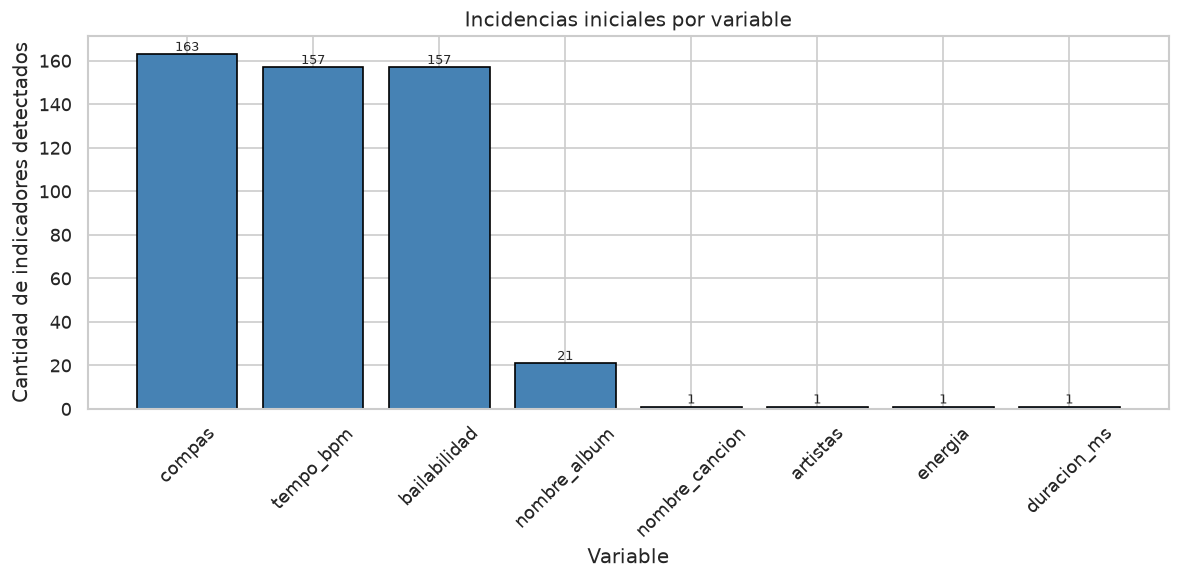

In [4]:
textos_auditoria = ['artistas', 'nombre_album', 'nombre_cancion']
numericas_cero = ['tempo_bpm', 'bailabilidad', 'energia', 'compas', 'duracion_ms']

auditoria_inicial = pd.DataFrame(index=textos_auditoria + numericas_cero)
auditoria_inicial.index.name = 'variable'
auditoria_inicial['nulos_explicitos'] = df_crudo[auditoria_inicial.index].isna().sum()
auditoria_inicial['interrogaciones'] = 0
auditoria_inicial['vacios'] = 0
auditoria_inicial['ceros'] = 0

for columna in textos_auditoria:
    texto = df_crudo[columna].astype('string').str.strip()
    auditoria_inicial.loc[columna, 'interrogaciones'] = int(texto.eq('?').sum())
    auditoria_inicial.loc[columna, 'vacios'] = int(texto.eq('').sum())

for columna in numericas_cero:
    valores = pd.to_numeric(df_crudo[columna], errors='coerce')
    auditoria_inicial.loc[columna, 'ceros'] = int(valores.eq(0).sum())

display(auditoria_inicial)

incidencias_por_variable = auditoria_inicial.sum(axis=1).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(incidencias_por_variable.index, incidencias_por_variable.values,
       color='steelblue', edgecolor='black')
ax.set_title('Incidencias iniciales por variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Cantidad de indicadores detectados')
ax.tick_params(axis='x', rotation=45)
for barra, valor in zip(ax.patches, incidencias_por_variable.values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
            f'{int(valor):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '00_calidad_datos_crudos.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.5 Estadística y distribución preliminar

Esta revisión se realiza sobre los datos crudos. Su finalidad es comprender la
fuente y detectar problemas; las cifras definitivas para presentación se vuelven
a calcular después de la limpieza en la Fase 3.


,count,mean,std,min,25%,50%,75%,max
popularidad,"114,000.0000",33.2385,22.3051,0.0000,17.0000,35.0000,50.0000,100.0000
duracion_ms,"114,000.0000","228,029.1531","107,297.7126",0.0000,"174,066.0000","212,906.0000","261,506.0000","5,237,295.0000"
bailabilidad,"114,000.0000",0.5668,0.1735,0.0000,0.4560,0.5800,0.6950,0.9850
energia,"114,000.0000",0.6414,0.2515,0.0000,0.4720,0.6850,0.8540,1.0000
volumen_db,"114,000.0000",-8.2590,5.0293,-49.5310,-10.0130,-7.0040,-5.0030,4.5320
presencia_habla,"114,000.0000",0.0847,0.1057,0.0000,0.0359,0.0489,0.0845,0.9650
acusticidad,"114,000.0000",0.3149,0.3325,0.0000,0.0169,0.1690,0.5980,0.9960
instrumentalidad,"114,000.0000",0.1560,0.3096,0.0000,0.0000,0.0000,0.0490,1.0000
presencia_en_vivo,"114,000.0000",0.2136,0.1904,0.0000,0.0980,0.1320,0.2730,1.0000
positividad,"114,000.0000",0.4741,0.2593,0.0000,0.2600,0.4640,0.6830,0.9950


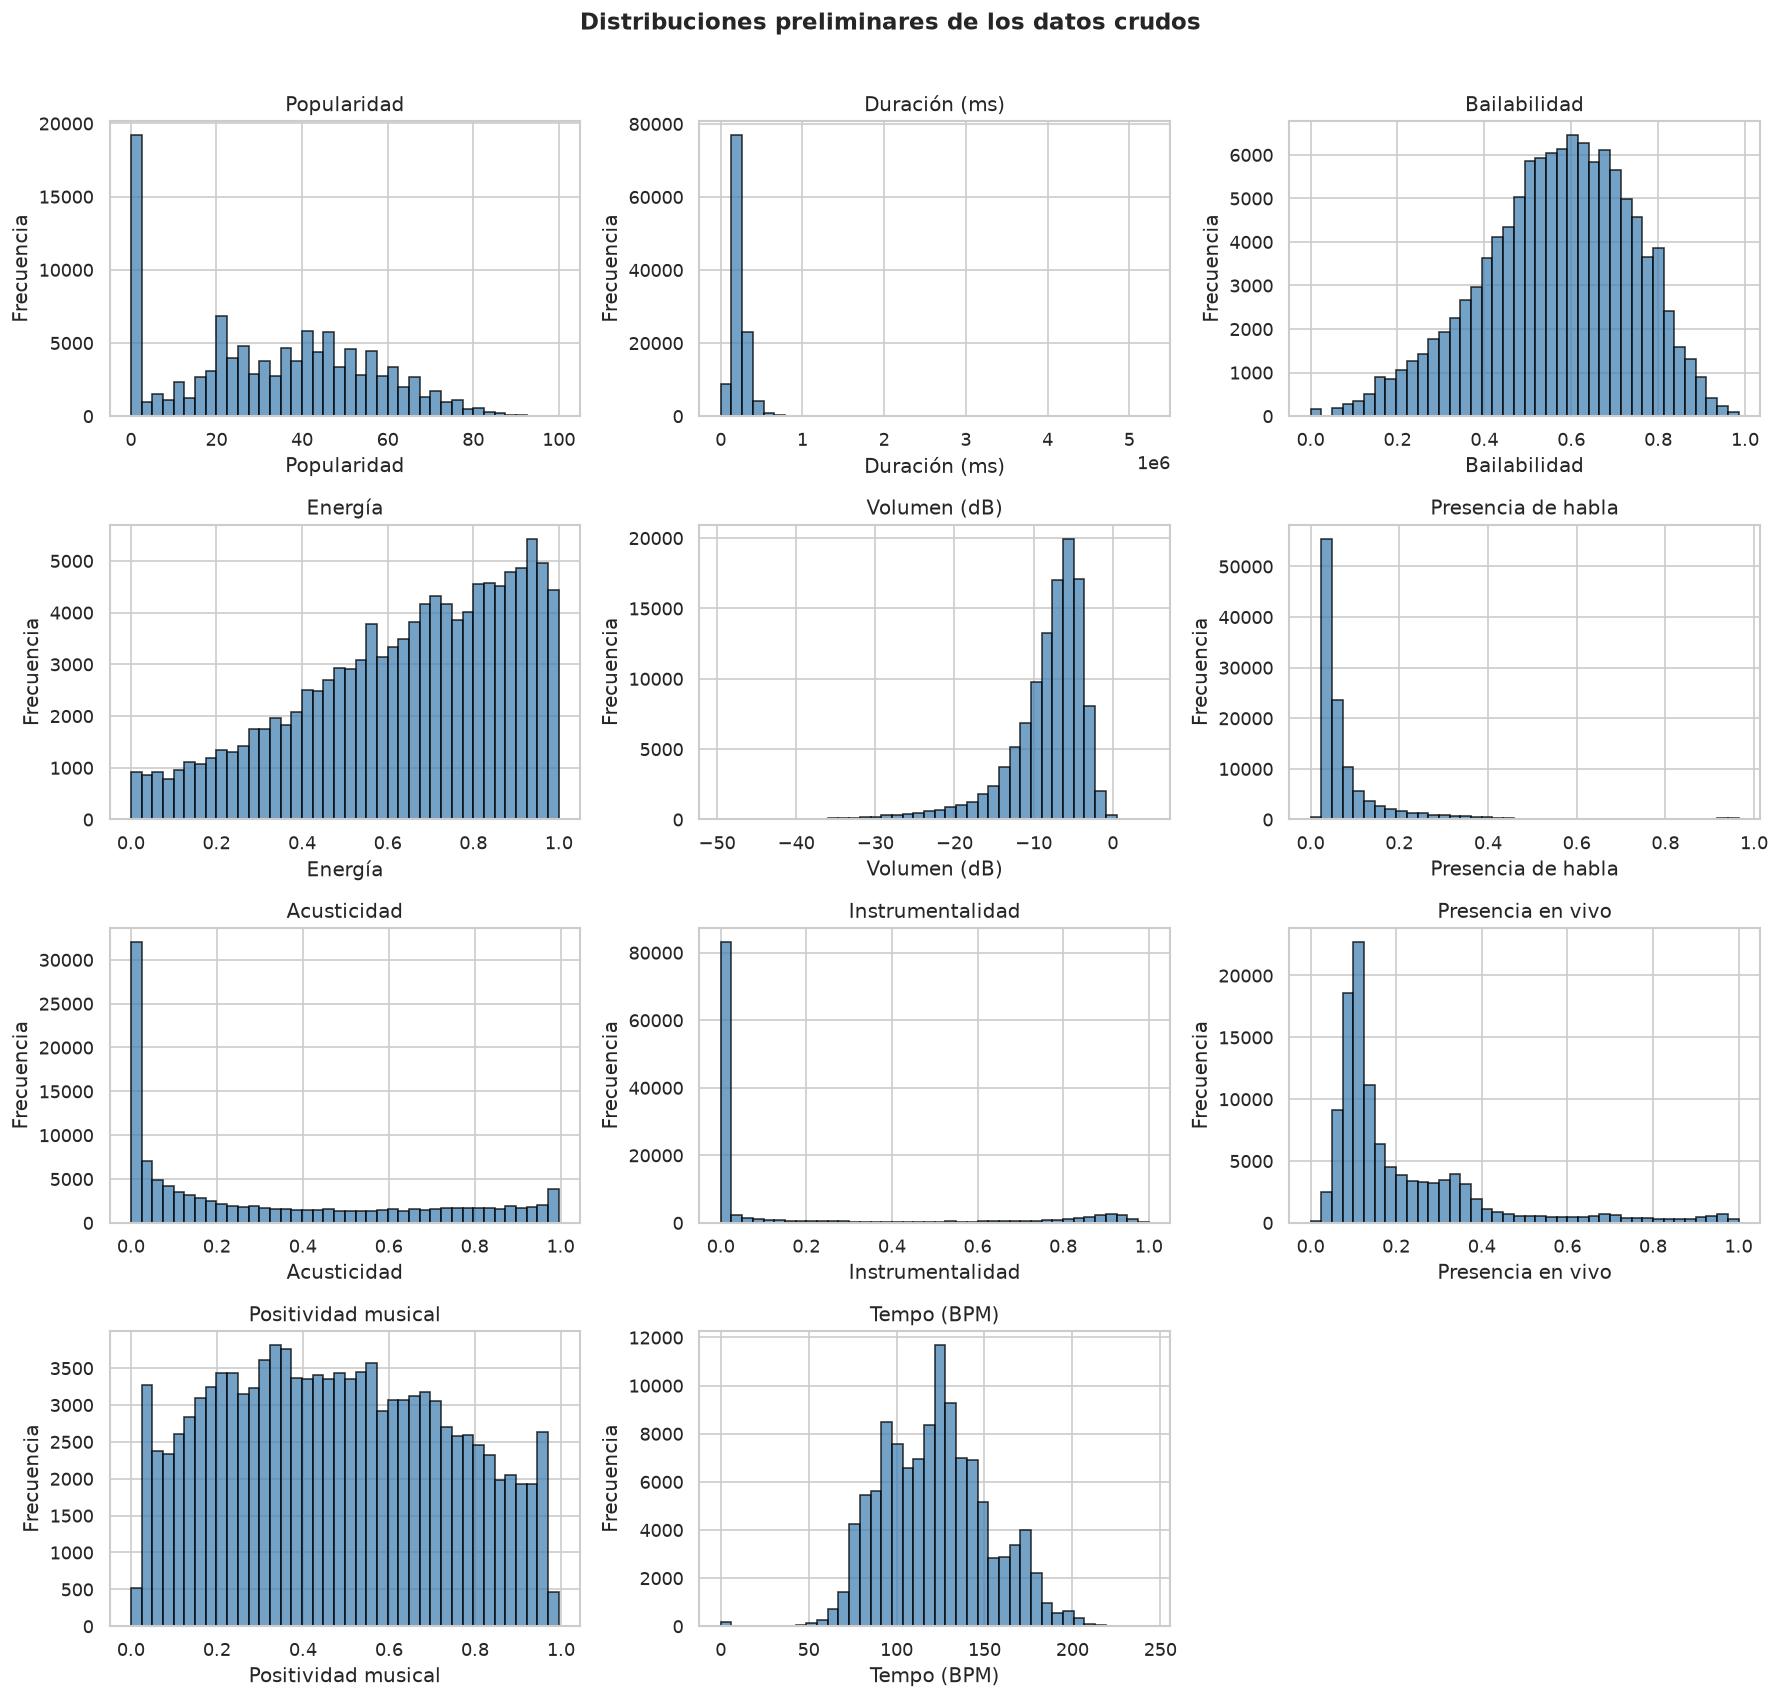

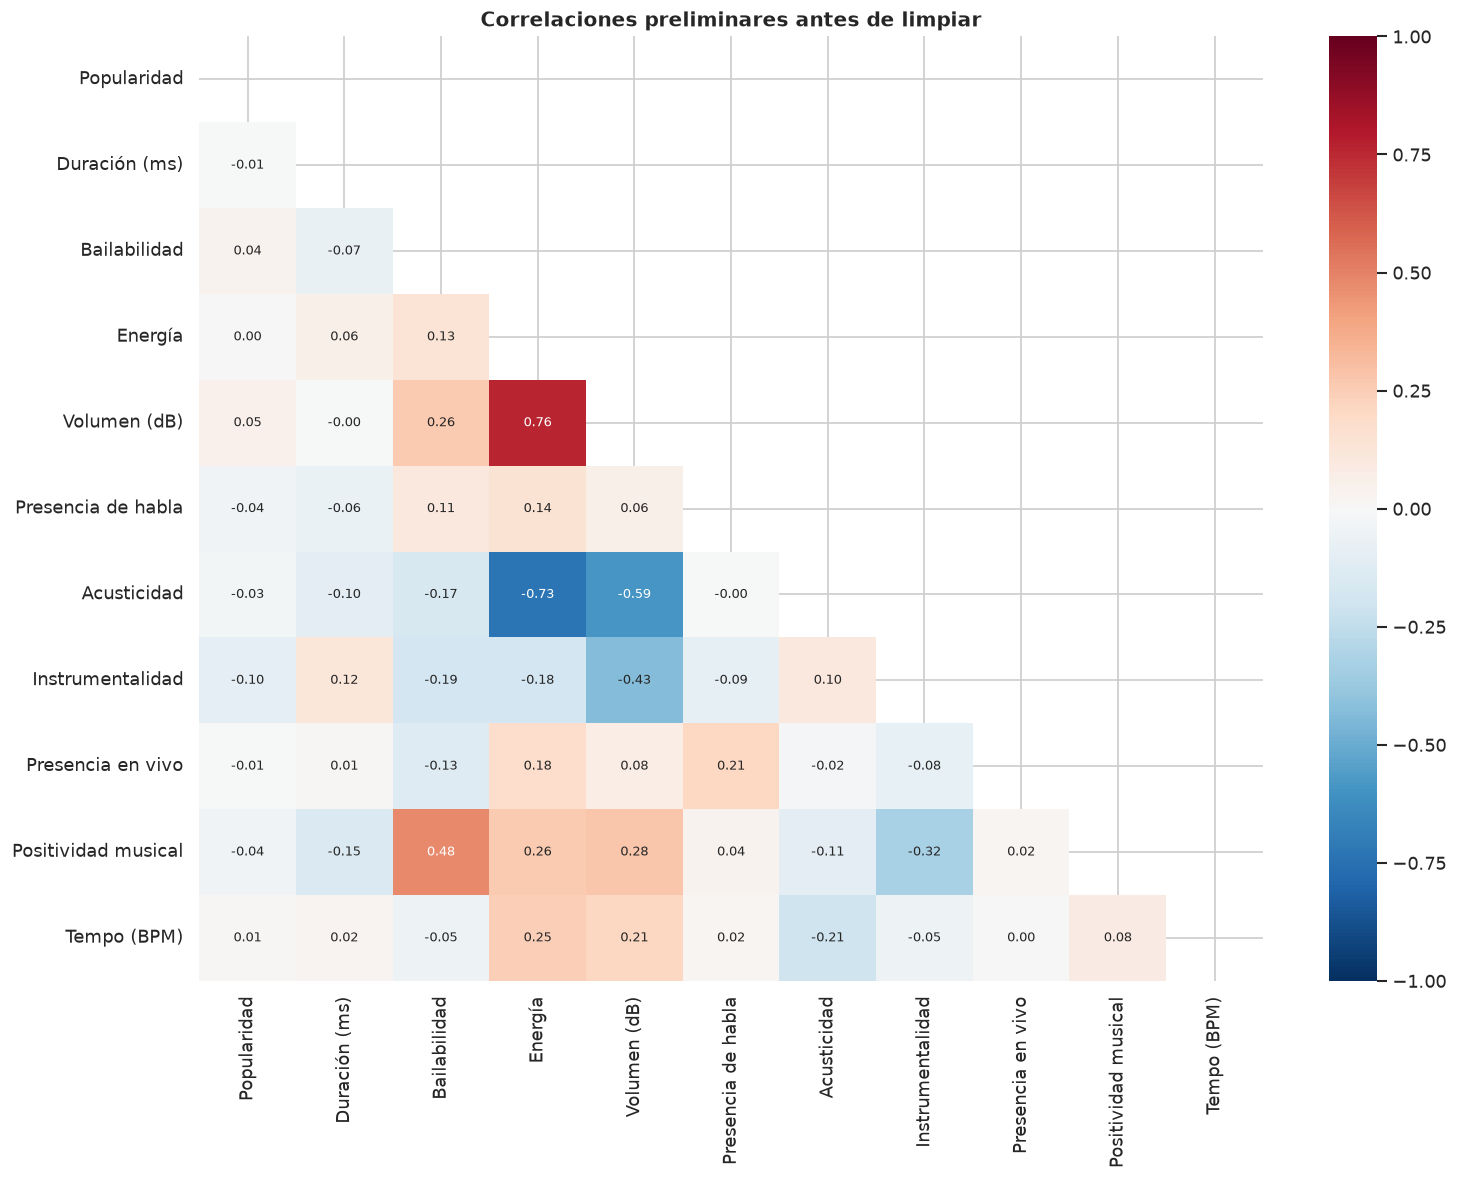

Filas originales: 114,000
Columnas útiles: 20
Duplicados exactos: 450
Canciones únicas por ID: 89,741


In [5]:
numericas_crudas = [
    'popularidad', 'duracion_ms', 'bailabilidad', 'energia', 'volumen_db',
    'presencia_habla', 'acusticidad', 'instrumentalidad',
    'presencia_en_vivo', 'positividad', 'tempo_bpm'
]

display(df_crudo[numericas_crudas].describe().T.round(4))

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, columna in enumerate(numericas_crudas):
    valores = pd.to_numeric(df_crudo[columna], errors='coerce').dropna()
    axes[i].hist(valores, bins=40, color='steelblue', edgecolor='black', alpha=0.75)
    axes[i].set_title(ETIQUETAS[columna])
    axes[i].set_xlabel(ETIQUETAS[columna])
    axes[i].set_ylabel('Frecuencia')
for j in range(len(numericas_crudas), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuciones preliminares de los datos crudos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '00_distribuciones_crudas.png', dpi=150, bbox_inches='tight')
plt.show()

correlacion_cruda = df_crudo[numericas_crudas].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mascara = np.triu(np.ones_like(correlacion_cruda, dtype=bool))
sns.heatmap(
    correlacion_cruda.rename(index=ETIQUETAS, columns=ETIQUETAS),
    mask=mascara, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlaciones preliminares antes de limpiar', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Filas originales: {len(df_crudo):,}')
print(f'Columnas útiles: {df_crudo.shape[1]:,}')
print(f'Duplicados exactos: {df_crudo.duplicated().sum():,}')
print(f'Canciones únicas por ID: {df_crudo["id_cancion"].nunique(dropna=True):,}')


## Conclusiones Fase 2

- El dataset combina metadatos, variables numéricas de audio, categorías musicales
  y la variable objetivo popularidad.
- La auditoría separa los distintos tipos de incidencia para evitar confundir un
  cero con un nulo explícito.
- Los gráficos y tablas anteriores permiten observar forma, dispersión, valores
  extremos y asociaciones iniciales.
- Los valores calculados en esta fase no se utilizan todavía como entrada de un
  modelo. Primero se aplican las reglas documentadas de la Fase 3.
- La correlación describe asociación lineal; no demuestra causalidad ni garantiza
  desempeño predictivo.


## Fase 3: Data Preparation


### 3.1 Limpieza y transformaciones justificadas

| Variables en español | Condición | Tratamiento |
|---|---|---|
| artistas, nombre_cancion | Nulo, vacío o «?» | Eliminar la fila |
| nombre_album | Nulo, vacío o «?» | Imputar DESCONOCIDO en las filas conservadas |
| tempo_bpm, bailabilidad, energia | Al menos una igual a cero | Eliminar la fila una sola vez |
| Las tres métricas anteriores | Nulo explícito | Eliminar, sin KNN en esta versión |
| compas | Cero o nulo | Moda de los valores observados **solo en entrenamiento** |
| duracion_ms | Cero, negativo o nulo | Eliminar la fila |

- "?" y espacios vacíos se normalizan solo en los tres metadatos de texto.
- No se asigna SINGLE: la falta de nombre no demuestra que un lanzamiento sea un single.
- Los conteos informados (1 nulo de texto, 20 "?", 157 ceros de audio, 163 compases
  cero y 1 duración cero) son referencias a comprobar. Las filas pueden coincidir;
  **no se suman los conteos para calcular las eliminaciones**.
- Eliminar ceros de bailabilidad y energía es una **decisión de este proyecto**:
  cero pertenece a sus escalas y no demuestra un dato faltante. Puede sesgar la
  muestra hacia canciones más bailables y enérgicas.
- Se mantienen los ceros válidos de otras variables, como popularidad, modo,
  tonalidad e instrumentalidad.
- No se usa KNNImputer para compás: su promedio podría crear categorías
  fraccionarias. La moda conserva un valor observado; en empate se elige el menor.
- Los compases observados positivos se conservan si son enteros. Las categorías
  inusuales se reportan para revisión, sin inventar valores ni truncar decimales.
- Los valores extremos detectados por IQR se reportan; no se eliminan por IQR.

La partición por canción se reserva aquí para aprender la moda sin consultar el
conjunto de prueba. df_base conserva el compás sin imputar para el pipeline;
df_limpio incorpora esa moda para EDA y exportación. En EP2 se debe volver a
ajustar el pipeline dentro de cada pliegue de validación usando df_base.

> **Nota EP2:** esta partición por `id_cancion` solo se usa para aprender la moda del
> compás de `df_limpio` (EDA y exportación). La partición definitiva para modelar se
> redefine en la sección 3.12, agrupando por artista + título.

Referencias: [escalas de audio de Spotify](https://developer.spotify.com/documentation/web-api/reference/get-audio-features),
[moda con SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html).


In [6]:
def limpiar_spotify(datos, semilla=42):
    """Limpieza auditable, sin modificar la entrada ni aprender del test."""
    df = datos.copy()
    textos = ['artistas', 'nombre_album', 'nombre_cancion']
    audio_cero = ['tempo_bpm', 'bailabilidad', 'energia']

    # Diagnóstico ANTES de eliminar filas: separa nulos, ? y ceros.
    auditoria = pd.DataFrame(index=textos + audio_cero + ['compas', 'duracion_ms'])
    auditoria.index.name = 'variable'
    auditoria['nulos_explicitos'] = df[auditoria.index].isna().sum()
    auditoria['interrogaciones'] = 0
    auditoria['vacios'] = 0
    auditoria['ceros'] = 0
    for col in textos:
        texto = df[col].astype('string').str.strip()
        auditoria.loc[col, 'interrogaciones'] = int(texto.eq('?').sum())
        auditoria.loc[col, 'vacios'] = int(texto.eq('').sum())
        df[col] = texto.mask(texto.isin(['', '?']), pd.NA)
    for col in audio_cero + ['compas', 'duracion_ms']:
        df[col] = pd.to_numeric(df[col], errors='raise').astype(float)
        auditoria.loc[col, 'ceros'] = int(df[col].eq(0).sum())

    motivos = pd.DataFrame({
        'artista_o_cancion_faltante': df[['artistas', 'nombre_cancion']].isna().any(axis=1),
        'cero_en_audio': df[audio_cero].eq(0).any(axis=1),
        'nulo_en_audio': df[audio_cero].isna().any(axis=1),
        'duracion_invalida': df['duracion_ms'].isna() | df['duracion_ms'].le(0),
    }, index=df.index)
    eliminar = motivos.any(axis=1)
    resumen = pd.DataFrame({
        'criterio': motivos.columns,
        'filas_afectadas_pueden_coincidir': motivos.sum().values,
    })
    # Una fila con varias incidencias se elimina solo una vez.
    base = df.loc[~eliminar].copy()
    if base.empty:
        raise ValueError('No quedan filas después de la limpieza; revisa las incidencias.')
    albumes_imputados = int(base['nombre_album'].isna().sum())
    base['nombre_album'] = base['nombre_album'].fillna('DESCONOCIDO')
    base['compas'] = base['compas'].mask(base['compas'].eq(0), np.nan)
    observados = base['compas'].dropna()
    if ((observados <= 0) | ~np.isfinite(observados) | (observados % 1 != 0)).any():
        raise ValueError('Hay compases negativos, no finitos o decimales. Revisarlos sin truncar.')
    base['duracion_min'] = base['duracion_ms'] / 60000

    ids = base['id_cancion'].astype('string').str.strip()
    if ids.isna().any() or ids.isin(['', '?']).any():
        raise ValueError('Hay identificadores de canción faltantes; no se puede agrupar con seguridad.')
    base['id_cancion'] = ids
    if ids.nunique() < 2:
        raise ValueError('Se necesitan al menos dos canciones distintas para separar entrenamiento y prueba.')
    divisor = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=semilla)
    idx_entrenamiento, idx_prueba = next(divisor.split(base, groups=ids))
    compas_entrenamiento = base.iloc[idx_entrenamiento][['compas']]
    if compas_entrenamiento['compas'].notna().sum() == 0:
        raise ValueError('No hay compases observados en entrenamiento para calcular la moda.')
    imputador = SimpleImputer(strategy='most_frequent')
    imputador.fit(compas_entrenamiento)
    moda = int(imputador.statistics_[0])
    limpio = base.copy()
    limpio['compas'] = imputador.transform(base[['compas']]).ravel().astype('int64')

    particion = pd.Series('prueba', index=base.index, name='particion')
    particion.iloc[idx_entrenamiento] = 'entrenamiento'
    imputaciones = pd.DataFrame({
        'particion': particion,
        'compas_imputado': base['compas'].isna(),
    }).groupby('particion')['compas_imputado'].sum().astype(int)
    balance = pd.DataFrame({
        'indicador': ['filas_originales', 'filas_eliminadas_sin_duplicar', 'filas_conservadas',
                      'albumes_imputados_en_filas_conservadas', 'compases_imputados',
                      'moda_compas_entrenamiento'],
        'cantidad': [len(df), int(eliminar.sum()), len(limpio), albumes_imputados,
                     int(base['compas'].isna().sum()), moda],
    })
    descartadas = datos.loc[eliminar].join(motivos.loc[eliminar].add_prefix('motivo_'))
    return base, limpio, idx_entrenamiento, idx_prueba, auditoria, resumen, balance, imputaciones, descartadas

(df_base, df_limpio, train_idx, test_idx, auditoria_faltantes, resumen_eliminacion,
 balance_limpieza, imputaciones_compas, filas_descartadas) = limpiar_spotify(df_crudo)

display(auditoria_faltantes)
display(resumen_eliminacion)
display(balance_limpieza)
display(imputaciones_compas.to_frame('cantidad_imputada'))
perdida_pct = 100 * (len(df_crudo) - len(df_limpio)) / len(df_crudo)
print(f'Pérdida real de filas: {perdida_pct:.4f}% (sin duplicar coincidencias)')

# Guardar datos limpios, base sin imputación aprendida y trazabilidad.
df_limpio.to_csv(PROCESSED_DIR / 'spotify_clean.csv', index=False)
df_base.to_csv(PROCESSED_DIR / 'spotify_base_modelo.csv', index=False)
auditoria_faltantes.to_csv(PROCESSED_DIR / 'auditoria_faltantes.csv')
resumen_eliminacion.to_csv(PROCESSED_DIR / 'resumen_eliminacion.csv', index=False)
balance_limpieza.to_csv(PROCESSED_DIR / 'balance_limpieza.csv', index=False)
filas_descartadas.to_csv(PROCESSED_DIR / 'filas_descartadas.csv', index_label='indice_origen')
particion = pd.DataFrame({'id_cancion': df_base['id_cancion'], 'particion': 'prueba'})
particion.iloc[train_idx, particion.columns.get_loc('particion')] = 'entrenamiento'
particion.to_csv(PROCESSED_DIR / 'particion_modelo.csv', index_label='indice_origen')
print('Datos y auditoría guardados; todos los nombres de columna están en español.')


,nulos_explicitos,interrogaciones,vacios,ceros
variable,,,,
artistas,1,0,0,0
nombre_album,1,20,0,0
nombre_cancion,1,0,0,0
tempo_bpm,0,0,0,157
bailabilidad,0,0,0,157
energia,0,0,0,1
compas,0,0,0,163
duracion_ms,0,0,0,1


,criterio,filas_afectadas_pueden_coincidir
0,artista_o_cancion_faltante,1
1,cero_en_audio,157
2,nulo_en_audio,0
3,duracion_invalida,1


,indicador,cantidad
0,filas_originales,114000
1,filas_eliminadas_sin_duplicar,158
2,filas_conservadas,113842
3,albumes_imputados_en_filas_conservadas,20
4,compases_imputados,6
5,moda_compas_entrenamiento,4


,cantidad_imputada
particion,
entrenamiento,4
prueba,2


Pérdida real de filas: 0.1386% (sin duplicar coincidencias)


Datos y auditoría guardados; todos los nombres de columna están en español.


In [7]:
# Clasificación de variables para el análisis
audio_numericas = [
    'duracion_ms', 'bailabilidad', 'energia', 'volumen_db', 'presencia_habla',
    'acusticidad', 'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm'
]
variables_categoricas = ['contenido_explicito', 'tonalidad', 'modo', 'compas', 'genero_musical']
metadatos_texto        = ['id_cancion', 'artistas', 'nombre_album', 'nombre_cancion']
numericas_descriptivas = ['popularidad', 'duracion_ms', 'duracion_min'] + audio_numericas[1:]

print('Numéricas predictoras:', audio_numericas)
print('Categóricas predictoras:', variables_categoricas)
print('Metadatos (excluir del modelo):', metadatos_texto)

Numéricas predictoras: ['duracion_ms', 'bailabilidad', 'energia', 'volumen_db', 'presencia_habla', 'acusticidad', 'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm']
Categóricas predictoras: ['contenido_explicito', 'tonalidad', 'modo', 'compas', 'genero_musical']
Metadatos (excluir del modelo): ['id_cancion', 'artistas', 'nombre_album', 'nombre_cancion']


### 3.2 Estadística descriptiva posterior a la limpieza

Se calculan media, mediana, desviación estándar, percentiles 25/50/75/90/95/99, rango, skewness y curtosis para cada variable numérica.


In [8]:
# Estadística descriptiva extendida con skewness y curtosis
rows = []
for col in numericas_descriptivas:
    s = df_limpio[col].dropna()
    q25, q50, q75, q90, q95, q99 = s.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    rows.append({
        'variable':   col,
        'cantidad':      int(len(s)),
        'media':       s.mean(),
        'mediana':     s.median(),
        'desviacion_estandar':        s.std(),
        'minimo':        s.min(),
        'P25':        q25,
        'P75':        q75,
        'P90':        q90,
        'P95':        q95,
        'P99':        q99,
        'maximo':        s.max(),
        'rango':      s.max() - s.min(),
        'asimetria':   s.skew(),
        'curtosis':   s.kurtosis()
    })

stats_df = pd.DataFrame(rows).set_index('variable')
display(stats_df.round(4))
stats_df.to_csv(PROCESSED_DIR / 'descriptive_statistics.csv')
print('Estadísticas guardadas.')

,cantidad,media,mediana,desviacion_estandar,minimo,P25,P75,P90,P95,P99,maximo,rango,asimetria,curtosis
variable,,,,,,,,,,,,,,
popularidad,113842,33.2334,34.0000,22.3161,0.0000,17.0000,50.0000,63.0000,69.0000,80.0000,100.0000,100.0000,0.0469,-0.9297
duracion_ms,113842,"228,108.6597","213,000.0000","106,306.2429","15,800.0000","174,198.5000","261,583.0000","327,835.0000","387,168.9000","530,665.8100","5,237,295.0000","5,221,495.0000",10.9655,351.1657
duracion_min,113842,3.8018,3.5500,1.7718,0.2633,2.9033,4.3597,5.4639,6.4528,8.8444,87.2882,87.0249,10.9655,351.1657
bailabilidad,113842,0.5676,0.5800,0.1724,0.0513,0.4560,0.6950,0.7840,0.8240,0.9010,0.9850,0.9337,-0.3728,-0.2584
energia,113842,0.6421,0.6850,0.2508,0.0000,0.4730,0.8540,0.9410,0.9690,0.9930,1.0000,1.0000,-0.5941,-0.5309
volumen_db,113842,-8.2399,-6.9980,4.9937,-46.5910,-10.0020,-5.0000,-3.6770,-2.9731,-1.6340,4.5320,51.1230,-1.9861,5.7514
presencia_habla,113842,0.0848,0.0490,0.1058,0.0221,0.0359,0.0846,0.1760,0.2680,0.5070,0.9650,0.9429,4.6479,28.8154
acusticidad,113842,0.3147,0.1680,0.3323,0.0000,0.0169,0.5970,0.8660,0.9480,0.9920,0.9960,0.9960,0.7280,-0.9481
instrumentalidad,113842,0.1554,0.0000,0.3089,0.0000,0.0000,0.0477,0.8310,0.9040,0.9540,1.0000,1.0000,1.7403,1.2918


Estadísticas guardadas.


#### Interpretación de la tabla actualizada

Las cifras deben salir de la ejecución actual, porque la eliminación de ceros
cambia medias, percentiles y correlaciones. Comparar media y mediana permite
describir la distribución; asimetría y curtosis ayudan a revisar valores extremos.

No confundir una correlación débil con la imposibilidad de predecir: pueden existir
relaciones no lineales o interacciones. El rendimiento se comprobará en EP2.


### 3.3 Histogramas y distribuciones

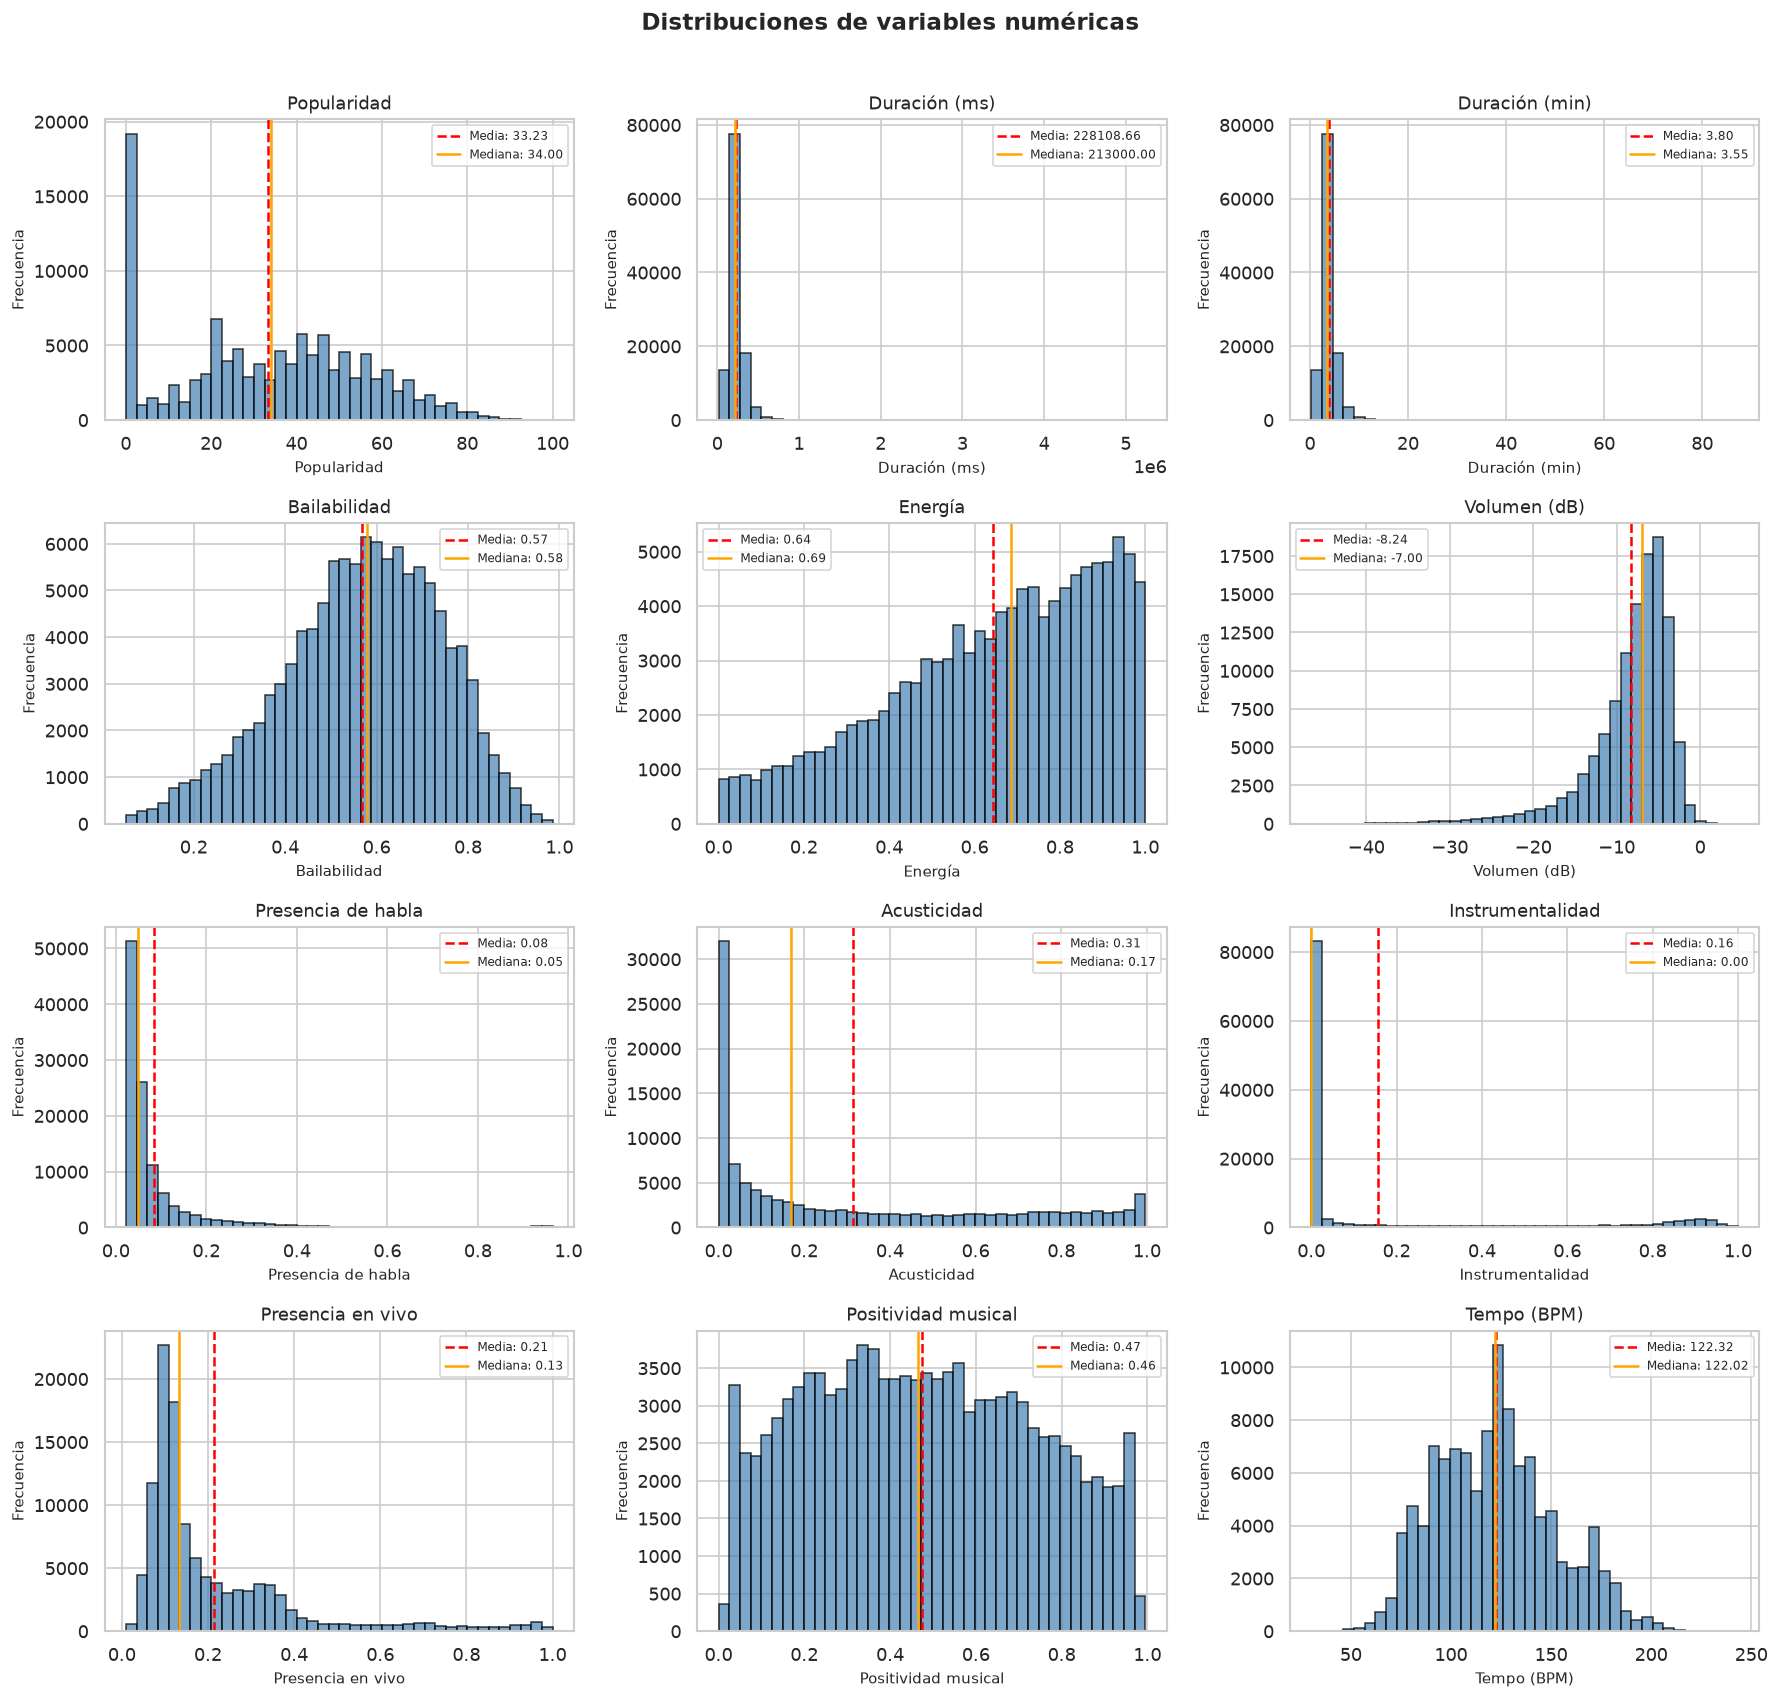

Gráfico guardado: 01_histogramas_numericas.png


In [9]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(numericas_descriptivas):
    ax = axes[i]
    data = df_limpio[col].dropna()
    ax.hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(ETIQUETAS[col], fontsize=11)
    ax.set_xlabel(ETIQUETAS[col], fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    # Añadir líneas de media y mediana
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.5, label=f'Mediana: {data.median():.2f}')
    ax.legend(fontsize=7)

# Ocultar subplots vacíos
for j in range(len(numericas_descriptivas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '01_histogramas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: 01_histogramas_numericas.png')


### 3.4 Variables categóricas: frecuencias y proporciones

Se analiza la distribución de contenido_explicito, tonalidad, modo, compas y genero_musical.


In [10]:
def tabla_frecuencias(data, variable):
    counts = data[variable].value_counts(dropna=False)
    pct    = data[variable].value_counts(dropna=False, normalize=True) * 100
    return pd.DataFrame({'frecuencia': counts, 'proporcion_pct': pct.round(2)})

for variable in ['contenido_explicito', 'tonalidad', 'modo', 'compas']:
    print(f'\n── {variable} ──')
    display(tabla_frecuencias(df_limpio, variable))

print(f'\n── genero_musical: {df_limpio["genero_musical"].nunique()} géneros únicos (mostrando top 20) ──')
display(tabla_frecuencias(df_limpio, 'genero_musical').head(20))



── contenido_explicito ──


,frecuencia,proporcion_pct
contenido_explicito,,
False,104095,91.4400
True,9747,8.5600



── tonalidad ──


,frecuencia,proporcion_pct
tonalidad,,
7,13236,11.6300
0,13045,11.4600
2,11625,10.2100
9,11303,9.9300
1,10743,9.4400
5,9362,8.2200
11,9273,8.1500
4,9004,7.9100
6,7914,6.9500



── modo ──


,frecuencia,proporcion_pct
modo,,
1,72573,63.7500
0,41269,36.2500



── compas ──


,frecuencia,proporcion_pct
compas,,
4,101848,89.4600
3,9195,8.0800
5,1826,1.6000
1,973,0.8500



── genero_musical: 114 géneros únicos (mostrando top 20) ──


,frecuencia,proporcion_pct
genero_musical,,
acoustic,1000,0.8800
afrobeat,1000,0.8800
alt-rock,1000,0.8800
alternative,1000,0.8800
anime,1000,0.8800
black-metal,1000,0.8800
bluegrass,1000,0.8800
blues,1000,0.8800
brazil,1000,0.8800


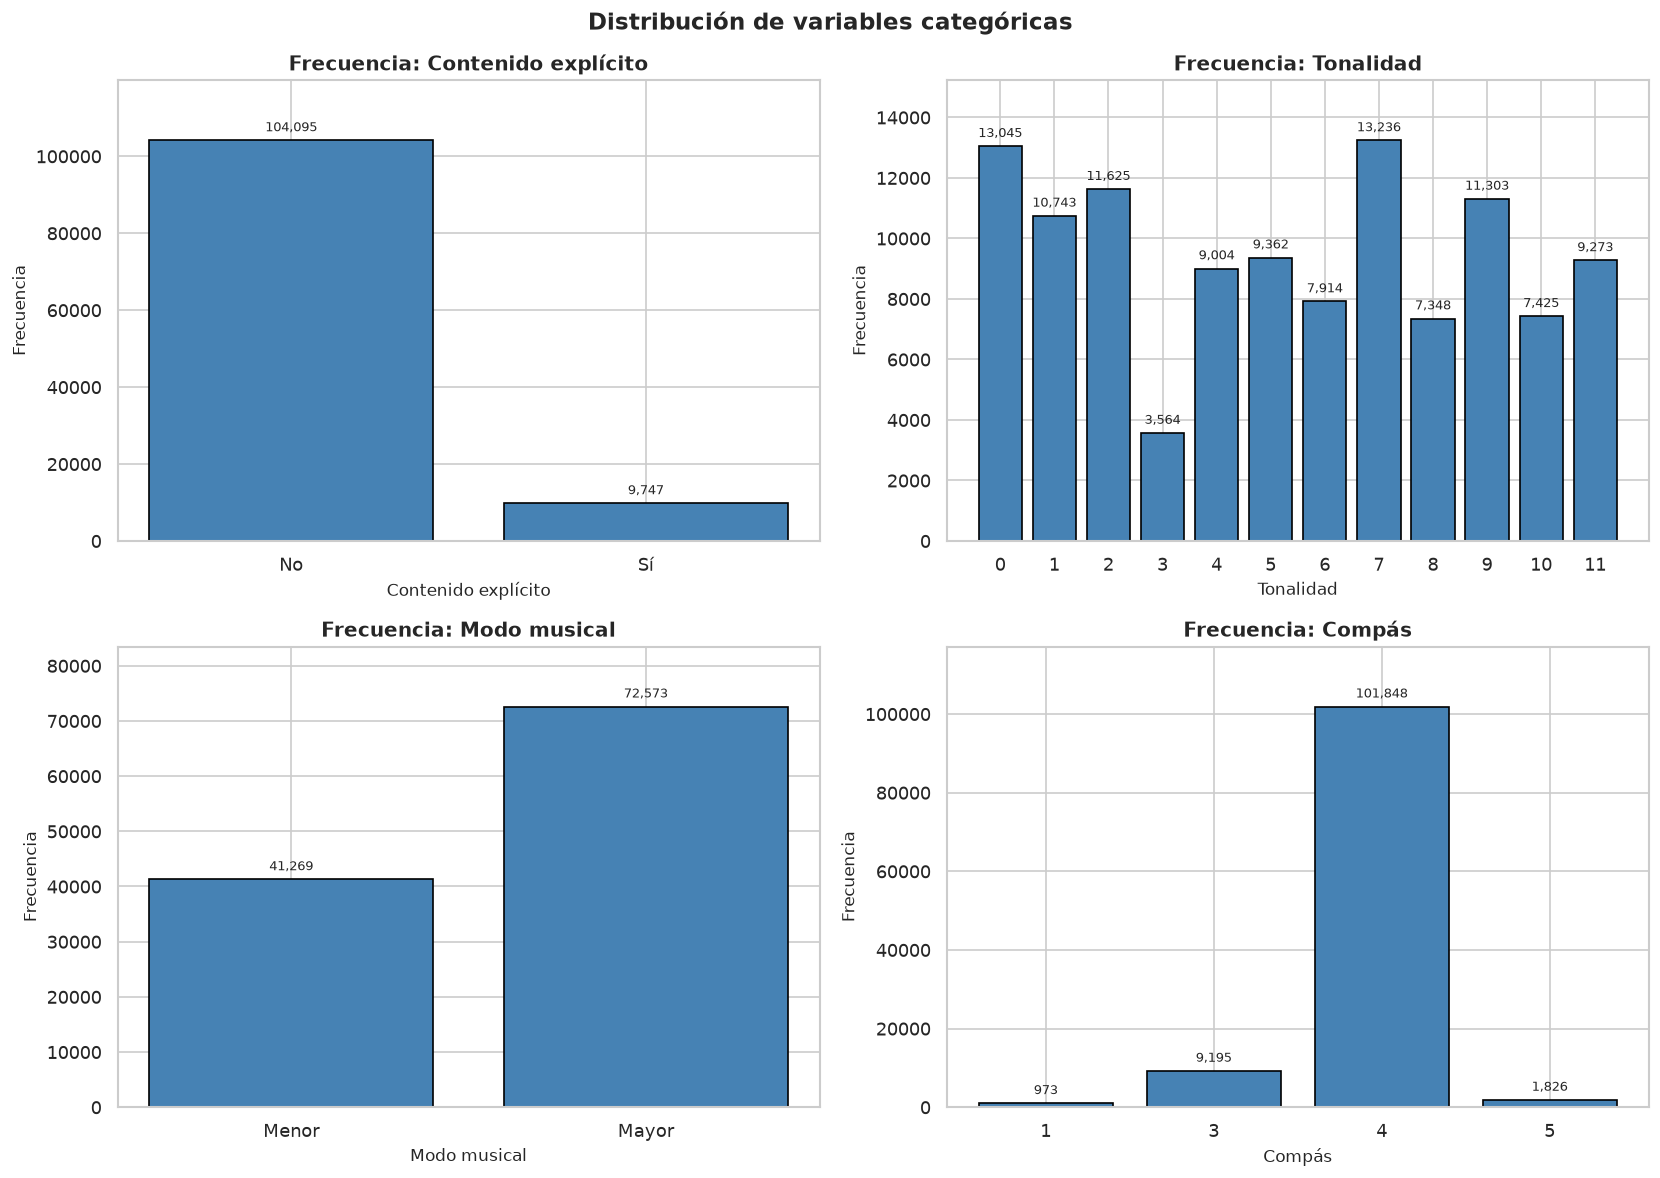

In [11]:
# Gráficos de variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, variable in zip(axes.flatten(), ['contenido_explicito', 'tonalidad', 'modo', 'compas']):
    counts = df_limpio[variable].value_counts().sort_index()
    ax.bar([({False: 'No', True: 'Sí'}.get(v, str(v)) if variable == 'contenido_explicito'
            else {0: 'Menor', 1: 'Mayor'}.get(v, str(v)) if variable == 'modo'
            else str(v)) for v in counts.index], counts.values, color='steelblue', edgecolor='black')
    ax.set_title(f'Frecuencia: {ETIQUETAS[variable]}', fontsize=12, fontweight='bold')
    ax.set_xlabel(ETIQUETAS[variable], fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.set_ylim(0, max(1, counts.max()) * 1.15)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max() * 0.015,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de variables categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '02_variables_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Validación de calidad, dominios y duplicados

Se comprueba el resultado de la limpieza y se reportan valores inusuales. Las
reglas específicas del proyecto se distinguen de los dominios de las variables.
Los compases 1 y 2, si aparecen en el CSV histórico, se conservan como categorías
observadas pero se señalan: la documentación actual de Spotify describe 3–7.


In [12]:
checks = {
    'Nulos después de limpiar (todas las columnas)': int(df_limpio.isna().sum().sum()),
    'Artista o canción vacíos / interrogación': int(df_limpio[['artistas', 'nombre_cancion']].isin(['', '?']).sum().sum()),
    'Álbum vacío / interrogación': int(df_limpio['nombre_album'].isin(['', '?']).sum()),
    'Popularidad fuera de 0–100': int((~df_limpio['popularidad'].between(0, 100)).sum()),
    'Tonalidad fuera de códigos -1 a 11': int((~df_limpio['tonalidad'].isin(range(-1, 12))).sum()),
    'Modo fuera de {0, 1}': int((~df_limpio['modo'].isin([0, 1])).sum()),
    'Duración no positiva': int(df_limpio['duracion_ms'].le(0).sum()),
    'Tempo no positivo': int(df_limpio['tempo_bpm'].le(0).sum()),
    'Bailabilidad o energía cero (regla del proyecto)': int(df_limpio[['bailabilidad', 'energia']].eq(0).any(axis=1).sum()),
    'Compás nulo, no positivo o no entero': int((df_limpio['compas'].isna() | df_limpio['compas'].le(0) | df_limpio['compas'].mod(1).ne(0)).sum()),
    'Valores numéricos no finitos': int((~np.isfinite(df_limpio[audio_numericas + ['popularidad']])).sum().sum()),
}
for col in ['bailabilidad', 'energia', 'presencia_habla', 'acusticidad',
            'instrumentalidad', 'presencia_en_vivo', 'positividad']:
    checks[f'{ETIQUETAS[col]} fuera de 0–1'] = int((~df_limpio[col].between(0, 1)).sum())
checks_df = pd.DataFrame(list(checks.items()), columns=['Regla', 'Cantidad'])
checks_df['Estado'] = np.where(checks_df['Cantidad'].eq(0), 'OK', 'Revisar')
display(checks_df)
if checks_df['Cantidad'].gt(0).any():
    raise ValueError('Persisten incidencias de calidad; revisarlas antes del modelamiento.')

advertencias = pd.DataFrame({
    'Observación': ['Volumen positivo en dB: revisar fuente', 'Compás fuera del rango 3–7 documentado actualmente'],
    'Cantidad': [int(df_limpio['volumen_db'].gt(0).sum()), int((~df_limpio['compas'].between(3, 7)).sum())],
})
display(advertencias)
print(f'Duplicados exactos: {df_limpio.duplicated().sum():,}')
conteos_id = df_limpio['id_cancion'].value_counts()
print(f'Canciones únicas: {len(conteos_id):,}')
print(f'IDs con más de una fila: {conteos_id.gt(1).sum():,}')
print(f'Filas adicionales respecto de IDs únicos: {len(df_limpio) - len(conteos_id):,}')
print('La separación por ID evita compartir canciones entre entrenamiento y prueba; no elimina duplicados.')


,Regla,Cantidad,Estado
0,Nulos después de limpiar (todas las columnas),0,OK
1,Artista o canción vacíos / interrogación,0,OK
2,Álbum vacío / interrogación,0,OK
3,Popularidad fuera de 0–100,0,OK
4,Tonalidad fuera de códigos -1 a 11,0,OK
5,"Modo fuera de {0, 1}",0,OK
6,Duración no positiva,0,OK
7,Tempo no positivo,0,OK
8,Bailabilidad o energía cero (regla del proyecto),0,OK
9,"Compás nulo, no positivo o no entero",0,OK


,Observación,Cantidad
0,Volumen positivo en dB: revisar fuente,90
1,Compás fuera del rango 3–7 documentado actualm...,973


Duplicados exactos: 450
Canciones únicas: 89,583
IDs con más de una fila: 16,641
Filas adicionales respecto de IDs únicos: 24,259
La separación por ID evita compartir canciones entre entrenamiento y prueba; no elimina duplicados.


### 3.6 Valores extremos mediante IQR

El criterio IQR se usa para **detectar**, no para eliminar automáticamente.
Cada caso se evalúa individualmente antes de tomar una decisión.


In [13]:
outlier_rows = []
for col in audio_numericas + ['popularidad']:
    s = df_limpio[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low  = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_rows.append({
        'variable':      col,
        'Q1':            q1,
        'Q3':            q3,
        'limite_inf':    low,
        'limite_sup':    high,
        'n_outliers':    int(mask.sum()),
        'pct_outliers':  round(mask.mean() * 100, 2),
        'decision':      'Conservar'
    })

outliers_df = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
display(outliers_df.round(3))
outliers_df.to_csv(PROCESSED_DIR / 'outliers_iqr_summary.csv', index=False)
print('\nResumen de outliers guardado.')


,variable,Q1,Q3,limite_inf,limite_sup,n_outliers,pct_outliers,decision
6,instrumentalidad,0.0000,0.0480,-0.0720,0.1190,25186,22.1200,Conservar
4,presencia_habla,0.0360,0.0850,-0.0370,0.1580,13211,11.6000,Conservar
7,presencia_en_vivo,0.0980,0.2730,-0.1640,0.5360,8579,7.5400,Conservar
3,volumen_db,-10.0020,-5.0000,-17.5050,2.5030,6099,5.3600,Conservar
0,duracion_ms,"174,198.5000","261,583.0000","43,121.7500","392,659.7500",5607,4.9300,Conservar
9,tempo_bpm,99.4300,140.0780,38.4570,201.0500,470,0.4100,Conservar
1,bailabilidad,0.4560,0.6950,0.0980,1.0530,463,0.4100,Conservar
2,energia,0.4730,0.8540,-0.0990,1.4260,0,0.0000,Conservar
5,acusticidad,0.0170,0.5970,-0.8530,1.4670,0,0.0000,Conservar
8,positividad,0.2610,0.6830,-0.3720,1.3160,0,0.0000,Conservar



Resumen de outliers guardado.


#### Justificación de las decisiones

El IQR identifica valores alejados del centro de la distribución, pero no demuestra
que sean errores. Se conservan los valores extremos para revisar su contexto
musical. Duraciones largas, grabaciones instrumentales o con habla pueden ser
reales; no se afirma que todos los extremos hayan sido verificados individualmente.

Las eliminaciones de ceros de audio y duración corresponden a las reglas de la
subsección 3.1, aplicadas **antes** del IQR. Sus cantidades no se mezclan con outliers.


### 3.7 Correlaciones y relaciones entre variables

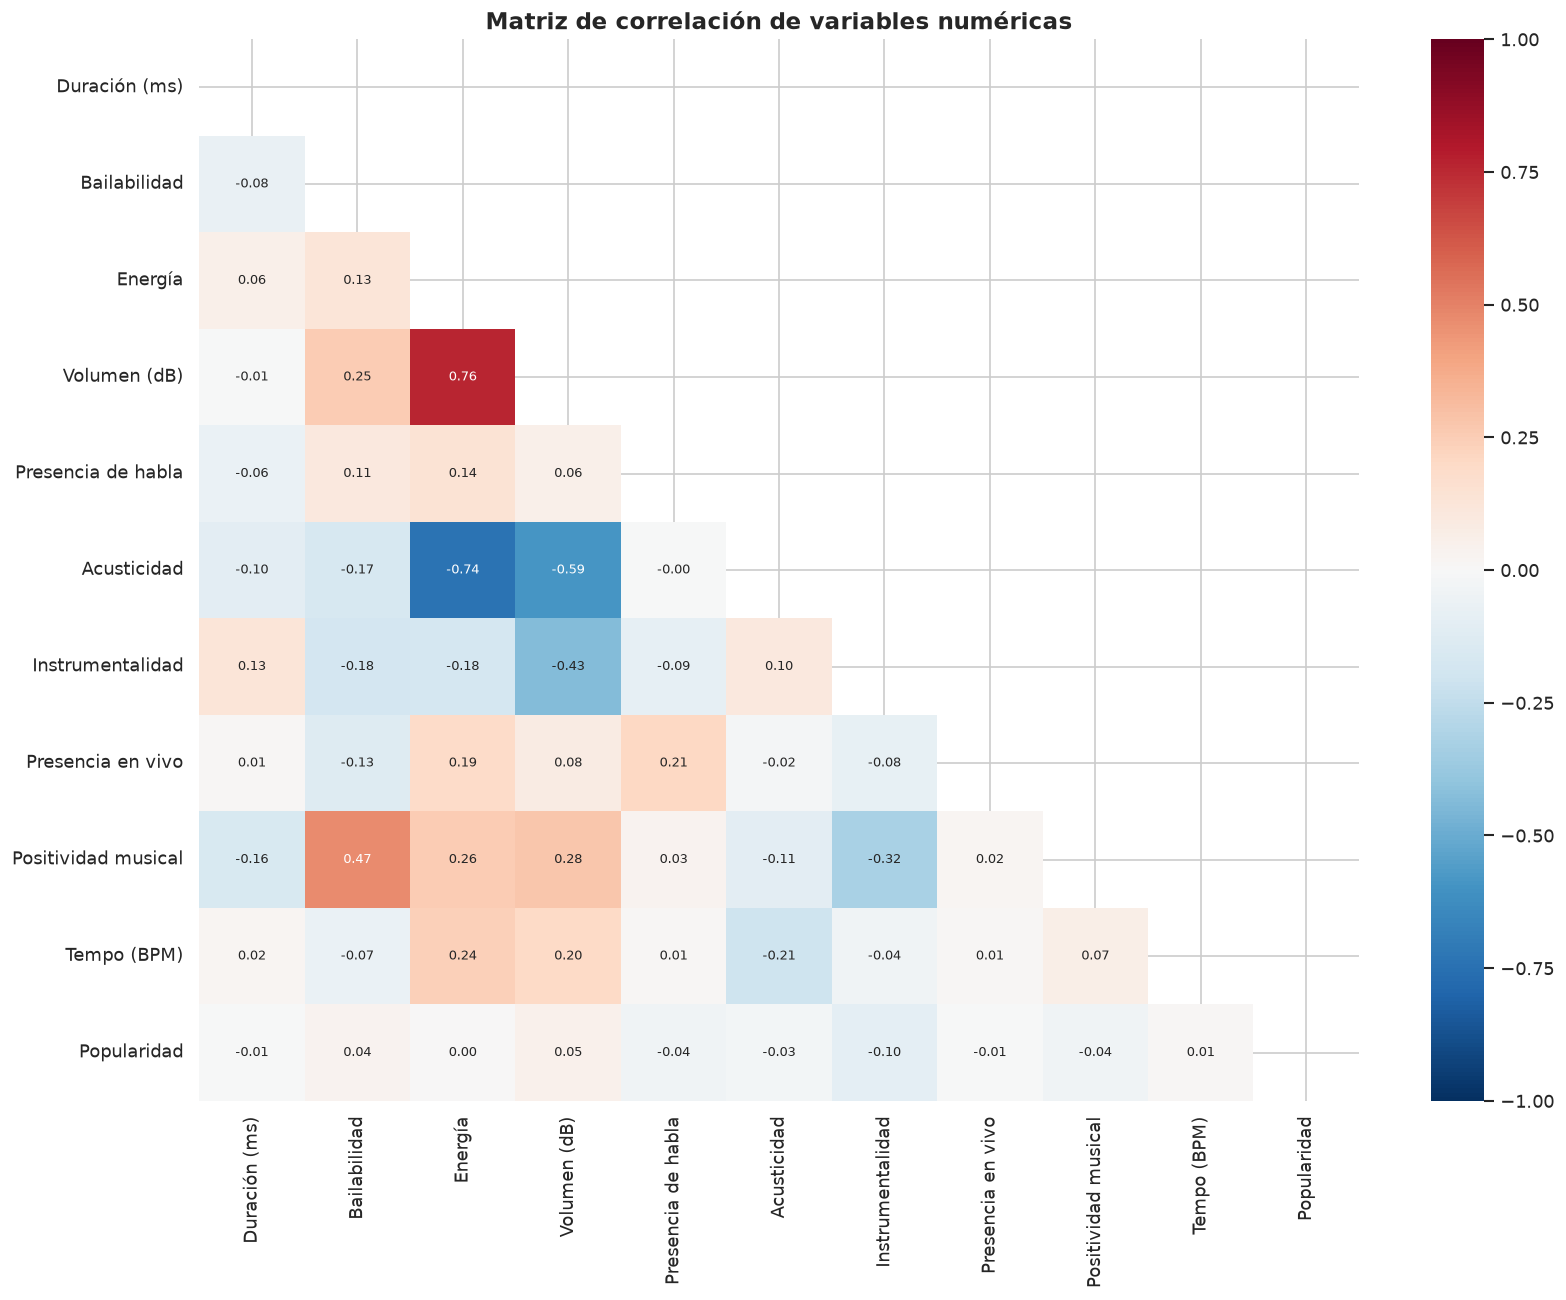

=== Correlaciones con popularidad (ordenadas por valor absoluto) ===


,correlacion_con_popularidad
instrumentalidad,-0.0959
volumen_db,0.0515
presencia_habla,-0.0448
positividad,-0.0402
bailabilidad,0.0365
acusticidad,-0.0256
tempo_bpm,0.0144
duracion_ms,-0.0070
presencia_en_vivo,-0.0057
energia,0.0015


Correlaciones con |r| >= 0.10: 0 de 10 calculables.
La correlación describe asociación lineal, no causalidad ni desempeño del modelo.


In [14]:
corr_cols = audio_numericas + ['popularidad']
corr = df_limpio[corr_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr.rename(index=ETIQUETAS, columns=ETIQUETAS), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlación de variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '03_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones con popularidad
corr_pop = corr['popularidad'].drop('popularidad').sort_values(key=lambda s: s.abs(), ascending=False)
print('=== Correlaciones con popularidad (ordenadas por valor absoluto) ===')
display(corr_pop.to_frame('correlacion_con_popularidad').round(4))
print(f'Correlaciones con |r| >= 0.10: {corr_pop.abs().ge(0.10).sum()} de {corr_pop.notna().sum()} calculables.')
print('La correlación describe asociación lineal, no causalidad ni desempeño del modelo.')


### 3.8 Popularidad por grupos

In [15]:
# Por género
estadisticas_genero = (
    df_limpio.groupby('genero_musical')
    .agg(
        n               = ('id_cancion', 'size'),
        popularidad_media = ('popularidad', 'mean'),
        popularidad_mediana  = ('popularidad', 'median'),
        popularidad_desviacion  = ('popularidad', 'std'),
        bailabilidad_media      = ('bailabilidad', 'mean'),
        energia_media     = ('energia', 'mean')
    )
    .sort_values('popularidad_media', ascending=False)
    .round(2)
)

print('=== 10 primeros géneros por popularidad media ===')
display(estadisticas_genero.head(10))
print('\n=== 10 últimos géneros por popularidad media ===')
display(estadisticas_genero.tail(10))

estadisticas_genero.to_csv(PROCESSED_DIR / 'genre_popularity_stats.csv')


=== 10 primeros géneros por popularidad media ===


,n,popularidad_media,popularidad_mediana,popularidad_desviacion,bailabilidad_media,energia_media
genero_musical,,,,,,
pop-film,1000,59.2800,60.0000,10.2500,0.6000,0.6000
k-pop,999,56.9500,60.0000,16.8600,0.6500,0.6800
chill,1000,53.6500,57.0000,14.9500,0.6600,0.4300
sad,1000,52.3800,54.0000,11.4900,0.6900,0.4600
grunge,1000,49.5900,55.0000,18.4900,0.4600,0.8000
indian,1000,49.5400,49.0000,11.3500,0.5900,0.5700
anime,1000,48.7700,50.0000,11.8100,0.5400,0.6700
emo,1000,48.1300,51.0000,17.5900,0.6000,0.6700
sertanejo,1000,47.8700,47.0000,3.9400,0.5900,0.7100



=== 10 últimos géneros por popularidad media ===


,n,popularidad_media,popularidad_mediana,popularidad_desviacion,bailabilidad_media,energia_media
genero_musical,,,,,,
idm,1000,15.7700,12.0000,10.2700,0.5300,0.5600
kids,1000,14.8900,12.0000,9.2400,0.7800,0.6100
grindcore,1000,14.6200,14.0000,4.5000,0.2700,0.9200
jazz,999,13.5800,0.0000,23.1400,0.5100,0.3500
classical,1000,13.0600,3.0000,18.0900,0.3800,0.1900
chicago-house,1000,12.3400,10.0000,9.5800,0.7700,0.7300
detroit-techno,1000,11.1700,8.0000,8.9500,0.7200,0.7100
latin,1000,8.3000,0.0000,21.9600,0.7200,0.7300
romance,999,3.2200,0.0000,6.2600,0.4300,0.2900


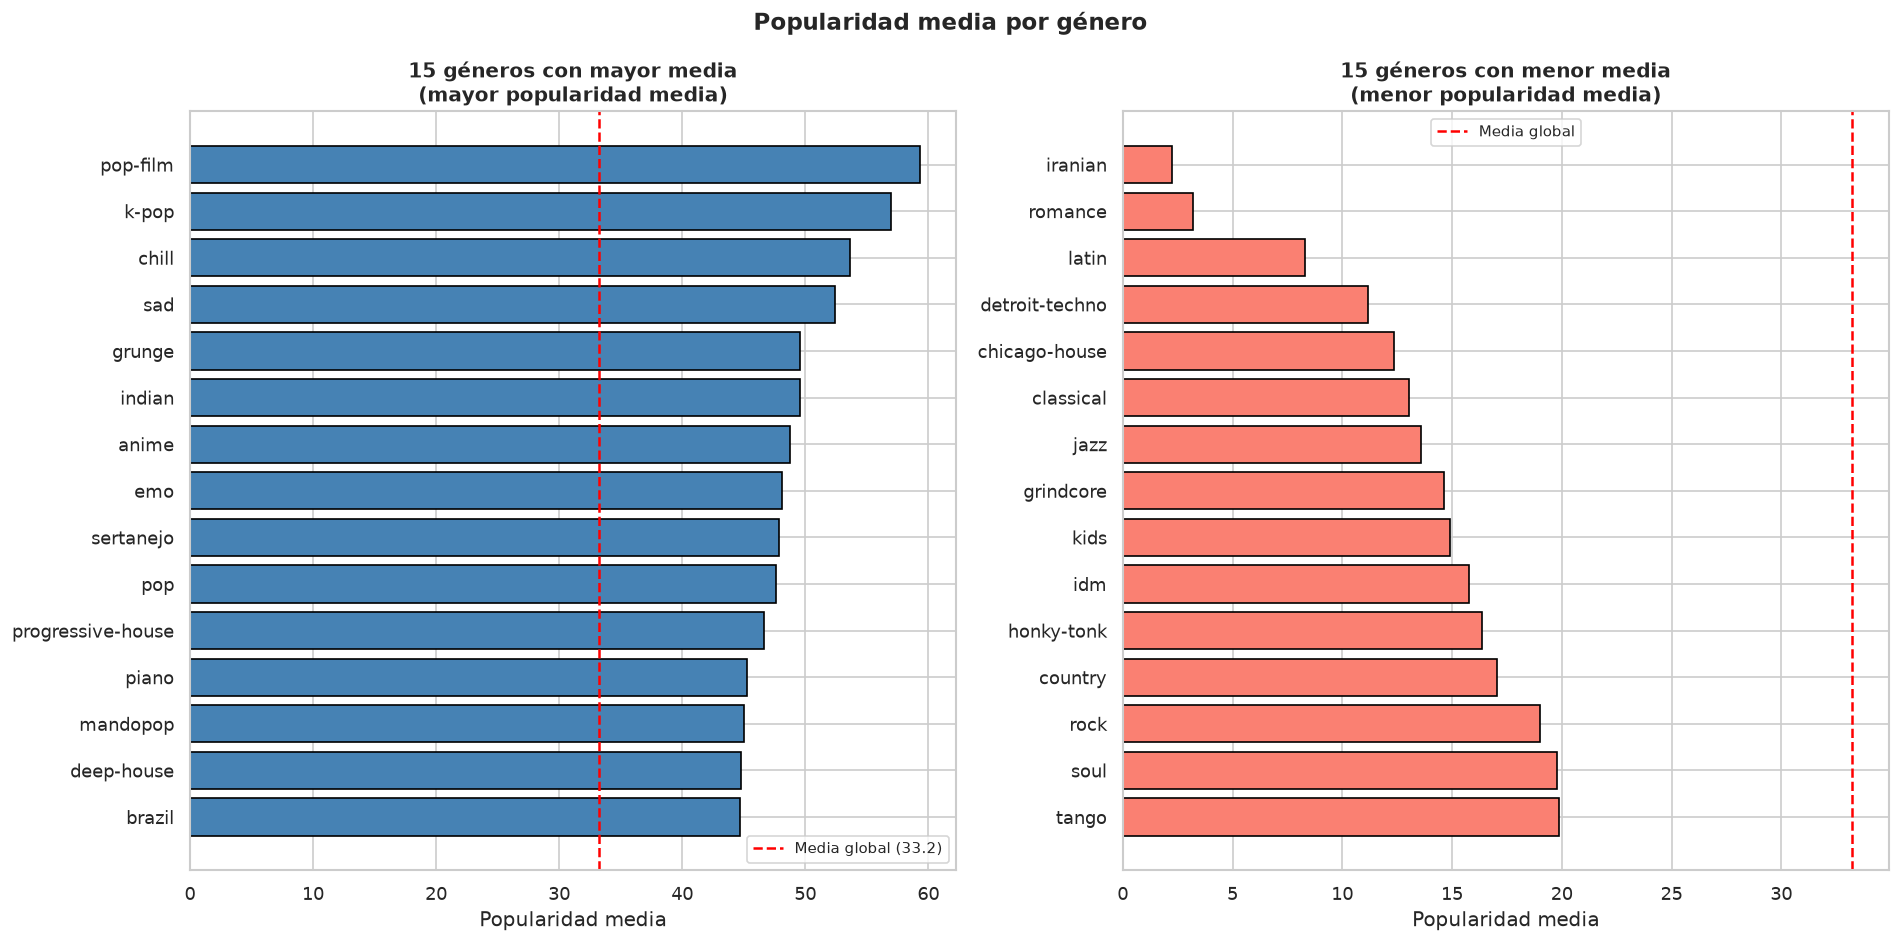

In [16]:
# Gráfico Top 15 y Bottom 15
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top15  = estadisticas_genero.head(15).sort_values('popularidad_media')
bot15  = estadisticas_genero.tail(15).sort_values('popularidad_media', ascending=False)

ax1.barh(top15.index, top15['popularidad_media'], color='steelblue', edgecolor='black')
ax1.set_title('15 géneros con mayor media\n(mayor popularidad media)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Popularidad media')
ax1.axvline(df_limpio['popularidad'].mean(), color='red', linestyle='--', label=f'Media global ({df_limpio["popularidad"].mean():.1f})')
ax1.legend(fontsize=9)

ax2.barh(bot15.index, bot15['popularidad_media'], color='salmon', edgecolor='black')
ax2.set_title('15 géneros con menor media\n(menor popularidad media)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Popularidad media')
ax2.axvline(df_limpio['popularidad'].mean(), color='red', linestyle='--', label=f'Media global')
ax2.legend(fontsize=9)

plt.suptitle('Popularidad media por género', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_popularidad_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()


=== Popularidad según contenido explícito ===


,cantidad,media,mediana,desviacion_estandar
contenido_explicito,,,,
False,104095,32.9300,34.0000,22.1000
True,9747,36.4500,37.0000,24.3200


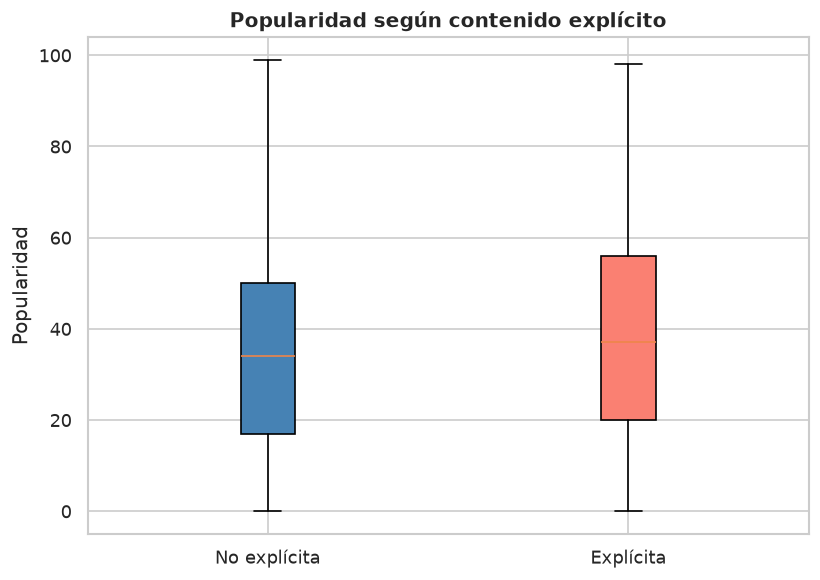

Diferencia de medias: 3.52 puntos (no implica causalidad)


In [17]:
# Por contenido_explicito
estadisticas_explicito = df_limpio.groupby('contenido_explicito')['popularidad'].agg(['count','mean','median','std']).round(2)
print('=== Popularidad según contenido explícito ===')
display(estadisticas_explicito.rename(columns={'count': 'cantidad', 'mean': 'media', 'median': 'mediana', 'std': 'desviacion_estandar'}))

fig, ax = plt.subplots(figsize=(7, 5))
groups_data = [df_limpio.loc[df_limpio['contenido_explicito'] == False, 'popularidad'].values,
               df_limpio.loc[df_limpio['contenido_explicito'] == True,  'popularidad'].values]
bp = ax.boxplot(groups_data, positions=[1, 2], patch_artist=True,
                showfliers=False)
ax.set_xticks([1, 2], ['No explícita', 'Explícita'])
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
ax.set_title('Popularidad según contenido explícito', fontsize=12, fontweight='bold')
ax.set_ylabel('Popularidad')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_popularidad_explicit.png', dpi=150, bbox_inches='tight')
plt.show()
if {False, True}.issubset(estadisticas_explicito.index):
    print('Diferencia de medias: {:.2f} puntos (no implica causalidad)'.format(
        estadisticas_explicito.loc[True, 'mean'] - estadisticas_explicito.loc[False, 'mean']))


### 3.9 Perfil de canciones populares

Se comparan los features de audio entre canciones con popularidad ≥ 70 y el resto.


In [18]:
pop_alta  = df_limpio[df_limpio['popularidad'] >= 70]
pop_baja  = df_limpio[df_limpio['popularidad'] < 70]

print(f'Canciones con popularidad >= 70: {len(pop_alta):,} ({len(pop_alta)/len(df_limpio)*100:.1f}%)')
print(f'Resto: {len(pop_baja):,}')

comparacion = pd.DataFrame({
    'Popular (≥70)':   pop_alta[audio_numericas].mean(),
    'Resto (<70)':     pop_baja[audio_numericas].mean(),
}).round(4)
comparacion['Diferencia'] = (comparacion['Popular (≥70)'] - comparacion['Resto (<70)']).round(4)
display(comparacion)
print('Comparar las diferencias calculadas arriba; no implican causalidad.')


Canciones con popularidad >= 70: 5,470 (4.8%)
Resto: 108,372


,Popular (≥70),Resto (<70),Diferencia
duracion_ms,"218,501.2808","228,593.5853","-10,092.3045"
bailabilidad,0.6163,0.5651,0.0512
energia,0.6713,0.6406,0.0307
volumen_db,-6.6550,-8.3199,1.6649
presencia_habla,0.0753,0.0852,-0.0099
acusticidad,0.2210,0.3194,-0.0984
instrumentalidad,0.0363,0.1614,-0.1251
presencia_en_vivo,0.1720,0.2153,-0.0433
positividad,0.5047,0.4732,0.0315
tempo_bpm,120.1775,122.4241,-2.2466


Comparar las diferencias calculadas arriba; no implican causalidad.


### 3.10 Sesgos, ética y privacidad

Primero se cuantifica el sesgo introducido por la regla de limpieza "cero en audio".

In [19]:
# 3.10.a Cuantificación del sesgo por género en la regla "cero en audio"
eliminadas_por_cero_audio = filas_descartadas[filas_descartadas['motivo_cero_en_audio']]
impacto_genero = (
    eliminadas_por_cero_audio['genero_musical']
    .value_counts()
    .rename('filas_eliminadas')
    .to_frame()
)
impacto_genero['pct_del_total_eliminado'] = (
    100 * impacto_genero['filas_eliminadas'] / eliminadas_por_cero_audio.shape[0]
).round(2)
display(impacto_genero.head(10))
print(f'Total de filas eliminadas por la regla de audio en cero: {len(eliminadas_por_cero_audio)}')
print(f"Género con mayor impacto: {impacto_genero.index[0]} "
      f"({impacto_genero.iloc[0]['pct_del_total_eliminado']}% del total eliminado)")

,filas_eliminadas,pct_del_total_eliminado
genero_musical,,
sleep,138,87.9000
guitar,4,2.5500
iranian,4,2.5500
ambient,3,1.9100
world-music,3,1.9100
opera,2,1.2700
jazz,1,0.6400
romance,1,0.6400
show-tunes,1,0.6400


Total de filas eliminadas por la regla de audio en cero: 157
Género con mayor impacto: sleep (87.9% del total eliminado)


#### 3.10.b Matriz de riesgos

| Riesgo o sesgo | Tipo | Medida de control |
|---|---|---|
| Eliminación de ceros de audio afecta desproporcionadamente al género `sleep` | **Observado** (ver celda anterior) | El 87.9% de las filas eliminadas por la regla de audio en cero pertenece a un solo género. Se documenta en vez de tratarse como neutral; en EP2 se debe evaluar si esta pérdida diferencial afecta el desempeño del modelo específicamente en ese género. |
| Exposición desigual por género en el modelo | Potencial | Se evalúa el MAE por género en la Fase 5 (sección 5.3), no solo de forma global. |
| **Representación multi-género:** una canción asociada a varios géneros queda sobrerrepresentada al mantener una fila por género | **Observado** (16.641 canciones, ver celda siguiente) | Partición por `id_cancion` (no por fila) ya evita la fuga de información entre train y test. En EP2 se adopta la representación **1 canción = 1 observación**, con géneros multi-hot (sección 3.11). |
| Popularidad cambiante en el tiempo | Metodológico | Documentar la fecha de extracción cuando esté disponible; el CSV no la declara. |
| Ciclo de retroalimentación algorítmica | Potencial | Mantener supervisión humana y no tratar la predicción como sinónimo de calidad artística. |

**Propiedad intelectual y licenciamiento de los datos**

- El dataset proviene de Kaggle bajo licencia de uso académico/no comercial; **no se distribuyen archivos de audio**, solo metadatos y atributos numéricos derivados. Cualquier uso más allá del ámbito académico de esta evaluación requeriría revisar la licencia original y los Términos de Servicio de la API de Spotify.
- Los metadatos de artistas, álbumes y canciones son información pública, pero **no constituyen cesión de derechos de autor** sobre las obras musicales. El proyecto no reproduce, distribuye ni comercializa contenido protegido: solo analiza atributos numéricos derivados (tempo, energía, etc.), no las obras en sí.
- Un eventual modelo entrenado con estos datos, si se llevara a producción, debería documentar la fuente y licencia de los datos de entrenamiento como parte de su trazabilidad (data lineage), especialmente si se usa para decisiones comerciales de promoción o contratos.

**Privacidad:** el dataset no contiene historiales ni perfiles de usuarios individuales, solo metadatos públicos de canciones. El riesgo de privacidad individual es bajo. Si se incorporaran datos de usuarios (historial de reproducción, ubicación), aplicarían principios de minimización de datos y la normativa de protección de datos personales correspondiente.

### 3.11 Representación de modelamiento: 1 canción = 1 observación (multi-hot)

**Riesgo:** `df_base` mantiene una fila por combinación canción-género. Una canción con
varios géneros pesaría más en el entrenamiento y en las métricas solo por estar repetida.

**Decisión (EP2):** se modela con **1 canción = 1 fila**, y sus géneros se codifican con
*multi-hot encoding* (una columna binaria `genero_*` por género; una canción puede tener
varias en 1). Corrección respecto de EP1: la tabla se construye desde `df_base`
(compás **sin imputar**), para que la moda del compás se aprenda dentro del pipeline en
cada pliegue de validación y no antes.

- Atributos de audio: constantes por grabación → se toma el primer valor.
- Popularidad: puede variar levemente entre filas de un mismo ID → se usa la **mediana**.

In [20]:
# 3.11.a Construcción de la representación multi-género desde df_base (compás sin imputar)
variables_categoricas_modelo = ['contenido_explicito', 'tonalidad', 'modo', 'compas']
cols_atributos_cancion = (['artistas', 'nombre_album', 'nombre_cancion']
                          + audio_numericas + variables_categoricas_modelo)

# ¿Varían los atributos entre las filas de un mismo ID (una por género)?
duplicadas = df_base[df_base.duplicated('id_cancion', keep=False)]
variacion = duplicadas.groupby('id_cancion')[audio_numericas + ['popularidad']].nunique()
print(f'IDs repetidos con algún atributo de AUDIO distinto: '
      f'{(variacion[audio_numericas] > 1).any(axis=1).sum()} de {len(variacion)}')
print(f'IDs repetidos con POPULARIDAD distinta: {(variacion["popularidad"] > 1).sum()} de {len(variacion)}')

atributos_por_cancion = df_base.groupby('id_cancion').agg(
    {**{c: 'first' for c in cols_atributos_cancion}, 'popularidad': 'median'}
)
generos_por_cancion = df_base.groupby('id_cancion')['genero_musical'].apply(lambda s: sorted(set(s)))
mlb = MultiLabelBinarizer()
columnas_genero = [f'genero_{g}' for g in mlb.fit(generos_por_cancion).classes_]
generos_multihot = pd.DataFrame(mlb.transform(generos_por_cancion), columns=columnas_genero,
                                index=generos_por_cancion.index)

df_modelo = atributos_por_cancion.join(generos_multihot).reset_index()
df_modelo['contenido_explicito'] = df_modelo['contenido_explicito'].astype(int)
df_modelo['n_generos'] = generos_multihot.sum(axis=1).to_numpy()
df_modelo['genero_principal'] = generos_por_cancion.str[0].to_numpy()
df_modelo = df_modelo.copy()

print(f'\nFilas antes (canción-género): {len(df_base):,}')
print(f'Filas después (1 por canción): {len(df_modelo):,}')
print(f'Columnas multi-hot de género: {len(columnas_genero)}')
print(f'Canciones con más de un género: {(df_modelo["n_generos"] > 1).sum():,}')
print(f'Compases sin imputar (se imputan en el pipeline): {df_modelo["compas"].isna().sum()}')
display(df_modelo[['id_cancion', 'nombre_cancion', 'popularidad', 'n_generos', 'genero_principal']].head())

IDs repetidos con algún atributo de AUDIO distinto: 0 de 16641
IDs repetidos con POPULARIDAD distinta: 720 de 16641



Filas antes (canción-género): 113,842
Filas después (1 por canción): 89,583
Columnas multi-hot de género: 114
Canciones con más de un género: 16,299
Compases sin imputar (se imputan en el pipeline): 5


,id_cancion,nombre_cancion,popularidad,n_generos,genero_principal
0,0000vdREvCVMxbQTkS888c,Lolly,44.0000,1,german
1,000CC8EParg64OmTxVnZ0p,It's All Coming Back To Me Now (Glee Cast Vers...,47.0000,1,club
2,000Iz0K615UepwSJ5z2RE5,Böxig Leise - Pig & Dan Remix,22.0000,1,minimal-techno
3,000RDCYioLteXcutOjeweY,Teeje Week,62.0000,1,hip-hop
4,000qpdoc97IMTBvF8gwcpy,Tief,19.0000,1,minimal-techno


### 3.12 Partición entrenamiento/prueba sin fuga: grupos por artista + título

En la revisión se detectó que el mismo par **artista + título** aparece con distintos
`id_cancion` (la misma canción publicada en un álbum, un single y un recopilatorio).
Si la partición agrupa solo por ID, una versión puede quedar en entrenamiento y otra
—muchas veces con audio idéntico— en prueba: el modelo "reconoce" la canción en vez de
generalizar. Se define `clave_cancion` = artistas + título normalizados (minúsculas, sin
espacios repetidos) y se agrupa por ella con `GroupShuffleSplit` (80/20). La misma
clave se usa como grupo en la validación cruzada (`GroupKFold`) de la Fase 4.

> Nota: un artista sí puede aparecer en ambos conjuntos con canciones distintas. Esto es
> coherente con el uso de negocio (estimar la popularidad de un **nuevo lanzamiento**,
> incluso de artistas ya presentes en el catálogo).

In [21]:
def normalizar_texto(serie):
    return serie.astype('string').str.lower().str.strip().str.replace(r'\s+', ' ', regex=True)

df_modelo['clave_cancion'] = normalizar_texto(df_modelo['artistas']) + ' || ' + normalizar_texto(df_modelo['nombre_cancion'])
repetidas = df_modelo[df_modelo['clave_cancion'].duplicated(keep=False)]
audio_identico = repetidas.groupby('clave_cancion')[audio_numericas].nunique().le(1).all(axis=1)
rango_pop = repetidas.groupby('clave_cancion')['popularidad'].agg(lambda s: s.max() - s.min())
print(f'Claves artista+título con más de un ID: {repetidas["clave_cancion"].nunique():,} '
      f'({len(repetidas):,} canciones)')
print(f'  - con audio idéntico entre versiones: {audio_identico.mean():.1%}')
print(f'  - diferencia mediana de popularidad entre versiones: {rango_pop.median():.0f} puntos')

# Comparación: ¿cuántas claves quedarían en ambos conjuntos si se agrupara solo por ID?
split_id = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMILLA)
tr_id, te_id = next(split_id.split(df_modelo, groups=df_modelo['id_cancion']))
fuga_por_id = set(df_modelo['clave_cancion'].iloc[tr_id]) & set(df_modelo['clave_cancion'].iloc[te_id])
print(f'\nSi se agrupara solo por ID: {len(fuga_por_id):,} claves artista+título en train y test a la vez.')

divisor = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMILLA)
idx_train, idx_test = next(divisor.split(df_modelo, groups=df_modelo['clave_cancion']))
compartidas = set(df_modelo['clave_cancion'].iloc[idx_train]) & set(df_modelo['clave_cancion'].iloc[idx_test])
ids_compartidos = set(df_modelo['id_cancion'].iloc[idx_train]) & set(df_modelo['id_cancion'].iloc[idx_test])
assert not compartidas and not ids_compartidos, 'Existe fuga de información entre train y test.'
print(f'Partición por artista+título -> entrenamiento: {len(idx_train):,} | prueba: {len(idx_test):,} | '
      f'claves compartidas: {len(compartidas)} | IDs compartidos: {len(ids_compartidos)}')

particion = pd.DataFrame({'id_cancion': df_modelo['id_cancion'],
                          'clave_cancion': df_modelo['clave_cancion'], 'particion': 'prueba'})
particion.iloc[idx_train, particion.columns.get_loc('particion')] = 'entrenamiento'
particion.to_csv(PROCESSED_DIR / 'particion_modelo.csv', index=False)
df_modelo.drop(columns=['clave_cancion']).assign(particion=particion['particion']).to_csv(
    PROCESSED_DIR / 'spotify_multigenero.csv', index=False)
print('Guardados: particion_modelo.csv y spotify_multigenero.csv (base de modelamiento EP2).')

Claves artista+título con más de un ID: 4,737 (13,259 canciones)
  - con audio idéntico entre versiones: 49.1%
  - diferencia mediana de popularidad entre versiones: 6 puntos

Si se agrupara solo por ID: 1,894 claves artista+título en train y test a la vez.
Partición por artista+título -> entrenamiento: 71,740 | prueba: 17,843 | claves compartidas: 0 | IDs compartidos: 0


Guardados: particion_modelo.csv y spotify_multigenero.csv (base de modelamiento EP2).


### 3.13 Pipeline de preprocesamiento

| Grupo | Variables | Transformación | Justificación |
|---|---|---|---|
| Numéricas de audio | 10 variables (duración, bailabilidad, energía, volumen, habla, acusticidad, instrumentalidad, vivo, positividad, tempo) | `StandardScaler` | La regresión logística y KNN son sensibles a la escala (penalización y distancias). Los árboles no lo necesitan, pero no les perjudica. |
| Categóricas | contenido explícito, tonalidad, modo, compás | `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')` | Son códigos, no magnitudes. La moda solo es necesaria para compás, pero se aplica igual a todas por robustez. |
| Género | 114 columnas `genero_*` (multi-hot) | `passthrough` | Ya están en 0/1. |
| **Artista** | `artistas` (y `nombre_cancion`, solo para agrupar) | `CodificadorArtista` (*target encoding*) + `StandardScaler` | Ver detalle abajo. |
| Excluidas | `id_cancion`, álbum, título como predictor, `duracion_min`, `n_generos`, `genero_principal` | — | Identificadores y textos de alta cardinalidad (riesgo de memorizar), duplicados o auxiliares. |

#### Codificación del artista (decisión del equipo)

El artista tiene **31.388 valores distintos** y el 64% aparece con una sola canción, por lo
que un one-hot (31.000 columnas) sobreajustaría y no serviría para artistas nuevos. Se
evaluaron cuatro opciones (target encoding, frecuencia, one-hot de los artistas frecuentes y
la combinación) y el equipo eligió **target encoding**:

- **Qué hace:** reemplaza al artista por la **popularidad media de sus canciones de
  entrenamiento**, suavizada hacia la media global: `(suma + m·media) / (n + m)` con
  `m = 10`. Un artista con una sola canción recibe solo 1/11 de peso propio; uno con 50
  canciones, 50/60.
- **Colaboraciones (25% de las canciones):** se codifica cada artista y se toma el
  **máximo**, porque una colaboración con un artista popular arrastra la popularidad.
- **Artistas nuevos** (no vistos en entrenamiento): reciben la media global.
- **Sin fuga de información:** al ajustar, cada canción se codifica con **otros pliegues**
  (*cross-fitting*, 5 pliegues agrupados por artista + título), nunca con su propia
  popularidad ni la de sus reediciones. Como el codificador está **dentro del pipeline**,
  en la validación cruzada se reajusta en cada pliegue, y el conjunto de prueba se
  codifica solo con información de entrenamiento.
- **Clasificación:** la clase se convierte a nivel ordinal (bajo = 0, medio = 1, alto = 2)
  y se codifica el nivel medio del artista.
- Se implementa como transformador propio (`src/transformadores.py`) porque
  `TargetEncoder` de scikit-learn no admite varios artistas por canción.

**Nota metodológica — codificación vs. fuga de información:** el one-hot/multi-hot convierte
categorías en columnas numéricas; la fuga de información se controla con la partición por
grupos de la sección 3.12. Son problemas distintos.

El preprocesador se crea con una función para obtener una copia nueva en cada pipeline:
así, en la validación cruzada se **ajusta solo con los pliegues de entrenamiento**.

In [22]:
variables_numericas = audio_numericas.copy()
variables_artista = ['artistas', 'nombre_cancion']  # nombre_cancion solo agrupa reediciones
variables_modelo = variables_numericas + variables_categoricas_modelo + columnas_genero + variables_artista
MAPA_CLASES = {'bajo': 0, 'medio': 1, 'alto': 2}

def crear_preprocesador(con_artista=True):
    """ColumnTransformer nuevo (sin ajustar) para usar dentro de cada pipeline."""
    categoricas = Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('codificador', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformadores = [
        ('numericas', StandardScaler(), variables_numericas),
        ('categoricas', categoricas, variables_categoricas_modelo),
        ('generos', 'passthrough', columnas_genero),
    ]
    if con_artista:
        transformadores.append(('artista', Pipeline([
            ('target_encoding', CodificadorArtista(suavizado=10, n_pliegues=5, mapa_clases=MAPA_CLASES)),
            ('escalador', StandardScaler()),
        ]), variables_artista))
    return ColumnTransformer(transformadores)

X = df_modelo[variables_modelo]
y_reg = df_modelo['popularidad']
grupos = df_modelo['clave_cancion']
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train_reg, y_test_reg = y_reg.iloc[idx_train], y_reg.iloc[idx_test]
grupos_train = grupos.iloc[idx_train]

preprocesador = crear_preprocesador()
X_train_prep = preprocesador.fit_transform(X_train, y_train_reg)
X_test_prep = preprocesador.transform(X_test)
assert np.isfinite(X_train_prep).all() and np.isfinite(X_test_prep).all()
assert X_train_prep.shape[1] == X_test_prep.shape[1]
pd.DataFrame({'variable_transformada': preprocesador.get_feature_names_out()}).to_csv(
    PROCESSED_DIR / 'variables_modelo.csv', index=False)
print(f'Matriz de entrenamiento: {X_train_prep.shape} | prueba: {X_test_prep.shape}')
print('Verificado: sin nulos ni infinitos; el preprocesador se ajustó solo con entrenamiento.')

artistas_train = set(X_train['artistas'])
artista_conocido_test = X_test['artistas'].isin(artistas_train)
print(f'Artistas distintos: {df_modelo["artistas"].nunique():,} | con una sola canción: '
      f'{(df_modelo["artistas"].value_counts() == 1).mean():.0%} | canciones con varios artistas: '
      f'{df_modelo["artistas"].str.contains(";").mean():.0%}')
print(f'Canciones de prueba cuyo artista aparece en entrenamiento: {artista_conocido_test.mean():.1%}')
codif = preprocesador.named_transformers_['artista'].named_steps['target_encoding']
print(f'Popularidad codificada del artista: media global {codif.media_:.1f}; '
      f'artistas en la tabla aprendida: {len(codif.tabla_):,}')

Matriz de entrenamiento: (71740, 145) | prueba: (17843, 145)
Verificado: sin nulos ni infinitos; el preprocesador se ajustó solo con entrenamiento.
Artistas distintos: 31,388 | con una sola canción: 64% | canciones con varios artistas: 25%
Canciones de prueba cuyo artista aparece en entrenamiento: 72.2%
Popularidad codificada del artista: media global 33.2; artistas en la tabla aprendida: 26,453


### 3.14 Variables objetivo

**Regresión:** `popularidad` (0–100), sin transformar.

**Clasificación — corrección respecto de EP1:** en EP1 las clases se definían por terciles
de entrenamiento. Eso produce clases balanceadas "por construcción", pero el corte superior
(~45) hace que una canción con popularidad 45 sea "alta", lo que no tiene sentido para el
negocio (bajo la media de las canciones que entran a playlists editoriales). Se definen
umbrales **de negocio, fijos y conocidos de antemano**:

| Clase | Popularidad | Lectura de negocio |
|---|---|---|
| `bajo` | 0–29 | Baja tracción; no priorizar |
| `medio` | 30–59 | Tracción moderada; catálogo de fondo |
| `alto` | ≥ 60 | Candidata a playlists de alta rotación / promoción |

Como los cortes no se aprenden de los datos, no hay fuga. A cambio, la clase `alto` queda
**minoritaria** (~11%): por eso en la Fase 4 se comparan métodos de balanceo.

,entrenamiento_n,entrenamiento_%,prueba_n,prueba_%
popularidad,,,,
bajo,32460,45.2000,8003,44.9000
medio,31461,43.9000,7868,44.1000
alto,7819,10.9000,1972,11.1000


Cortes por terciles que usaba EP1 (entrenamiento): [23.0, 43.0] -> reemplazados por 30 y 60.


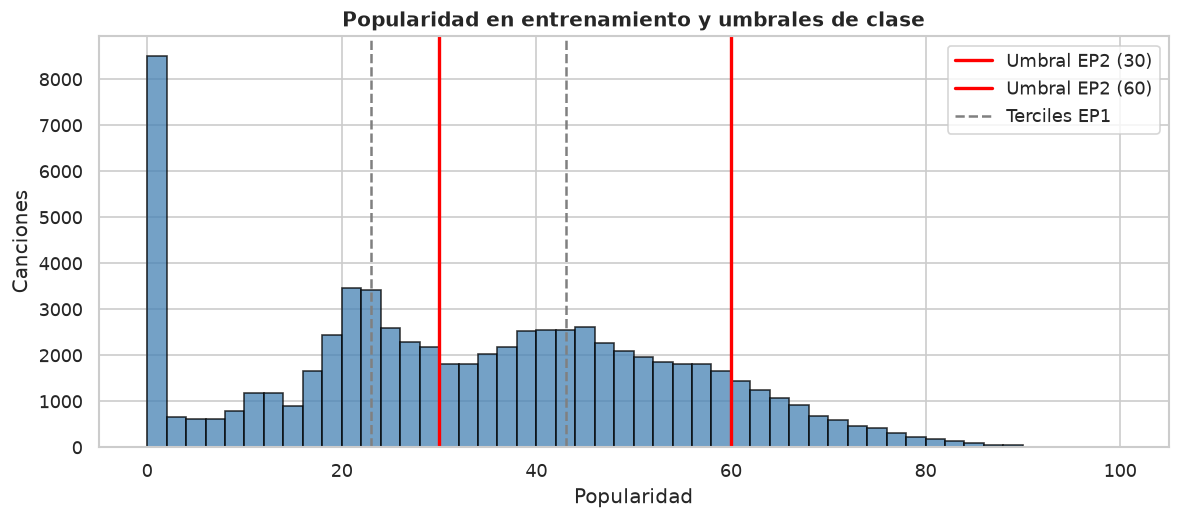

Canciones con popularidad 0 en entrenamiento: 10.6%


In [23]:
ETIQUETAS_CLASE = ['bajo', 'medio', 'alto']
CORTES_POPULARIDAD = [-np.inf, 30, 60, np.inf]
y_clase = pd.cut(y_reg, bins=CORTES_POPULARIDAD, right=False, labels=ETIQUETAS_CLASE).astype(str)
y_train_clf, y_test_clf = y_clase.iloc[idx_train], y_clase.iloc[idx_test]

distribucion = pd.DataFrame({
    'entrenamiento_n': y_train_clf.value_counts(),
    'entrenamiento_%': y_train_clf.value_counts(normalize=True).mul(100).round(1),
    'prueba_n': y_test_clf.value_counts(),
    'prueba_%': y_test_clf.value_counts(normalize=True).mul(100).round(1),
}).loc[ETIQUETAS_CLASE]
display(distribucion)
terciles_ep1 = y_train_reg.quantile([1/3, 2/3]).round(1).tolist()
print(f'Cortes por terciles que usaba EP1 (entrenamiento): {terciles_ep1} -> reemplazados por 30 y 60.')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(y_train_reg, bins=50, color='steelblue', edgecolor='black', alpha=0.75)
for corte, estilo, nombre in [(30, '-', 'Umbral EP2 (30)'), (60, '-', 'Umbral EP2 (60)')]:
    ax.axvline(corte, color='red', linestyle=estilo, linewidth=2, label=nombre)
for corte in terciles_ep1:
    ax.axvline(corte, color='gray', linestyle='--', linewidth=1.5)
ax.plot([], [], color='gray', linestyle='--', label='Terciles EP1')
ax.set_title('Popularidad en entrenamiento y umbrales de clase', fontweight='bold')
ax.set_xlabel('Popularidad'); ax.set_ylabel('Canciones'); ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '06_target_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Canciones con popularidad 0 en entrenamiento: {(y_train_reg == 0).mean():.1%}')

## Conclusiones Fase 3

- La limpieza de EP1 conserva el 99,86% de las filas; sus reglas se mantienen.
- El EDA muestra correlaciones lineales individuales débiles con la popularidad
  (|r| < 0,10) y diferencias marcadas por género: se esperan modelos no lineales y un peso
  importante del género.
- La base de modelamiento queda en **1 canción = 1 fila** (89.583 canciones, 114 columnas de
  género multi-hot) y la partición se agrupa por **artista + título**, eliminando la fuga
  por reediciones que tenía la partición por ID.
- El artista se incorpora con *target encoding* suavizado y *cross-fitting* dentro del
  pipeline; el 72% de las canciones de prueba son de artistas ya vistos en entrenamiento.
- Existen dos objetivos: popularidad continua (regresión) y nivel bajo/medio/alto con
  umbrales de negocio (clasificación, con la clase "alto" minoritaria).
- Cerca del 10% de las canciones tiene popularidad 0, muchas de ellas versiones
  duplicadas de una canción que sí es popular con otro ID: es ruido propio de la fuente
  que limitará el desempeño alcanzable.

## Fase 4: Modeling

### 4.1 Estrategia de validación

- **Selección de modelos e hiperparámetros solo con entrenamiento**, mediante validación
  cruzada `GroupKFold` de 3 pliegues agrupada por `clave_cancion` (una canción y sus
  reediciones nunca quedan en pliegues distintos).
- Todo el preprocesamiento y el balanceo van **dentro del pipeline**, por lo que se
  ajustan solo con los pliegues de entrenamiento de cada iteración.
- Búsqueda de hiperparámetros con `RandomizedSearchCV` (o búsqueda completa cuando la
  grilla es pequeña): más eficiente que una grilla exhaustiva con este volumen de datos.
- El **conjunto de prueba se usa una sola vez**, en la Fase 5, para los modelos finales.
- Se usan 3 pliegues (y no 5) para mantener el tiempo de ejecución razonable con ~72.000
  canciones; con este tamaño, la desviación entre pliegues es baja (se reporta).

In [24]:
cv_grupos = GroupKFold(n_splits=3)

def buscar_hiperparametros(nombre, pipeline, espacio, scoring, refit, n_iter, X_, y_):
    """Búsqueda aleatoria (o completa si la grilla es pequeña) con CV agrupada."""
    total = int(np.prod([len(v) for v in espacio.values()])) if espacio else 1
    inicio = time.time()
    busqueda = RandomizedSearchCV(
        pipeline, espacio, n_iter=min(n_iter, total), scoring=scoring, refit=refit,
        cv=cv_grupos, random_state=SEMILLA, n_jobs=1, error_score='raise',
    )
    busqueda.fit(X_, y_, groups=grupos_train)
    res = pd.DataFrame(busqueda.cv_results_).iloc[busqueda.best_index_]
    fila = {'modelo': nombre}
    for metrica in scoring:
        criterio = scoring[metrica]
        signo = -1 if isinstance(criterio, str) and criterio.startswith('neg_') else 1
        fila[f'{metrica}_cv'] = signo * res[f'mean_test_{metrica}']
        fila[f'{metrica}_std'] = res[f'std_test_{metrica}']
    fila['mejores_parametros'] = {k.replace('modelo__', ''): v for k, v in busqueda.best_params_.items()}
    fila['configuraciones_probadas'] = min(n_iter, total)
    fila['segundos'] = round(time.time() - inicio, 1)
    print(f"{nombre}: {fila['mejores_parametros']} ({fila['segundos']} s)")
    return busqueda.best_estimator_, fila

### 4.2 Aprendizaje supervisado — Regresión (target: `popularidad` 0–100)

**Baseline:** `DummyRegressor(strategy='mean')` predice siempre la popularidad media de
entrenamiento. Cualquier modelo útil debe superarlo.

**Selección de los 4 algoritmos.** Todos son **no lineales** (las correlaciones lineales de la
EP1 son débiles, |r| < 0,10) y representan enfoques distintos: un árbol individual, un método
basado en instancias y dos ensambles de árboles (*bagging* y *boosting*). Incluir el árbol
individual permite mostrar cuánto ganan los ensambles al combinar muchos árboles.

| # | Modelo | Familia | Por qué se incluye | Hiperparámetros explorados |
|---|---|---|---|---|
| R1 | `DecisionTreeRegressor` | Árbol de decisión individual | Divide las canciones con preguntas sucesivas del tipo "¿popularidad del artista > x?", "¿género = pop?", y predice la popularidad media de cada hoja. Capta no linealidades e interacciones, no necesita escalado y es **el más interpretable** (se puede dibujar). Su debilidad es la alta varianza (sobreajusta), que es justamente lo que corrigen RF y HGB. | `max_depth`, `min_samples_leaf` (controlan el sobreajuste) |
| R2 | `KNeighborsRegressor` | Basado en instancias | Traduce la hipótesis de negocio "canciones que suenan parecido y son del mismo género tienen popularidad parecida". No asume forma funcional. | `n_neighbors`, `weights` |
| R3 | `RandomForestRegressor` | Ensamble *bagging* de árboles | Captura no linealidades e interacciones (p. ej., género × energía) que la correlación lineal no detecta; robusto a los outliers que la EP1 decidió conservar. | `max_features`, `min_samples_leaf`, `max_depth` |
| R4 | `HistGradientBoostingRegressor` | Ensamble *boosting* | Estado del arte en datos tabulares; corrige errores de forma secuencial y es muy eficiente con ~72.000 filas. | `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization` |

**Métrica de selección:** MAE (error medio en puntos de popularidad, directamente
interpretable por el negocio). Se reportan también RMSE (penaliza errores grandes) y R²
(proporción de varianza explicada). Para Random Forest se usan 150 árboles y
`max_samples=0.6` para acotar tiempo y tamaño del modelo.

In [25]:
scoring_reg = {'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}

# Baseline
cv_dummy = cross_validate(Pipeline([('prep', crear_preprocesador()), ('modelo', DummyRegressor())]),
                          X_train, y_train_reg, groups=grupos_train, cv=cv_grupos, scoring=scoring_reg)
fila_dummy_reg = {'modelo': 'Baseline (media)',
                  'MAE_cv': -cv_dummy['test_MAE'].mean(), 'MAE_std': cv_dummy['test_MAE'].std(),
                  'RMSE_cv': -cv_dummy['test_RMSE'].mean(), 'RMSE_std': cv_dummy['test_RMSE'].std(),
                  'R2_cv': cv_dummy['test_R2'].mean(), 'R2_std': cv_dummy['test_R2'].std()}

modelos_regresion = {
    'Árbol de decisión': (DecisionTreeRegressor(random_state=SEMILLA),
                          {'modelo__max_depth': [6, 8, 10, 14, 20, None],
                           'modelo__min_samples_leaf': [10, 30, 50, 100, 200]}, 12),
    'KNN': (KNeighborsRegressor(n_jobs=-1),
            {'modelo__n_neighbors': [10, 20, 30, 50], 'modelo__weights': ['uniform', 'distance']}, 8),
    'Random Forest': (RandomForestRegressor(n_estimators=150, max_samples=0.6, n_jobs=-1, random_state=SEMILLA),
                      {'modelo__max_features': [0.2, 0.33, 0.5], 'modelo__min_samples_leaf': [5, 10, 20],
                       'modelo__max_depth': [None, 25]}, 5),
    'HistGradientBoosting': (HistGradientBoostingRegressor(random_state=SEMILLA),
                             {'modelo__learning_rate': [0.03, 0.05, 0.1], 'modelo__max_iter': [300, 600],
                              'modelo__max_leaf_nodes': [31, 63], 'modelo__min_samples_leaf': [20, 50, 100],
                              'modelo__l2_regularization': [0.0, 0.5, 1.0]}, 8),
}

regresores = {}
filas_reg = [fila_dummy_reg]
for nombre, (modelo, espacio, n_iter) in modelos_regresion.items():
    pipe = Pipeline([('prep', crear_preprocesador()), ('modelo', modelo)])
    regresores[nombre], fila = buscar_hiperparametros(nombre, pipe, espacio, scoring_reg, 'MAE',
                                                      n_iter, X_train, y_train_reg)
    filas_reg.append(fila)

resultados_cv_reg = pd.DataFrame(filas_reg).set_index('modelo')
resultados_cv_reg.to_csv(PROCESSED_DIR / 'resultados_cv_regresion.csv')
display(resultados_cv_reg.round(3))

Árbol de decisión: {'min_samples_leaf': 10, 'max_depth': 14} (77.6 s)


KNN: {'weights': 'distance', 'n_neighbors': 10} (84.8 s)


Random Forest: {'min_samples_leaf': 5, 'max_features': 0.33, 'max_depth': None} (199.3 s)


HistGradientBoosting: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 600, 'learning_rate': 0.03, 'l2_regularization': 0.5} (207.7 s)


,MAE_cv,MAE_std,RMSE_cv,RMSE_std,R2_cv,R2_std,mejores_parametros,configuraciones_probadas,segundos
modelo,,,,,,,,,
Baseline (media),17.2680,0.0290,20.6060,0.0140,-0.0000,0.0000,NaN,NaN,NaN
Árbol de decisión,10.4200,0.1050,15.7130,0.1750,0.4180,0.0130,"{'min_samples_leaf': 10, 'max_depth': 14}",12.0000,77.6000
KNN,11.0800,0.0450,16.0000,0.1260,0.3970,0.0100,"{'weights': 'distance', 'n_neighbors': 10}",8.0000,84.8000
Random Forest,9.6820,0.1190,14.6190,0.1970,0.4970,0.0140,"{'min_samples_leaf': 5, 'max_features': 0.33, ...",5.0000,199.3000
HistGradientBoosting,9.4220,0.0840,14.5440,0.1960,0.5020,0.0140,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,...",8.0000,207.7000


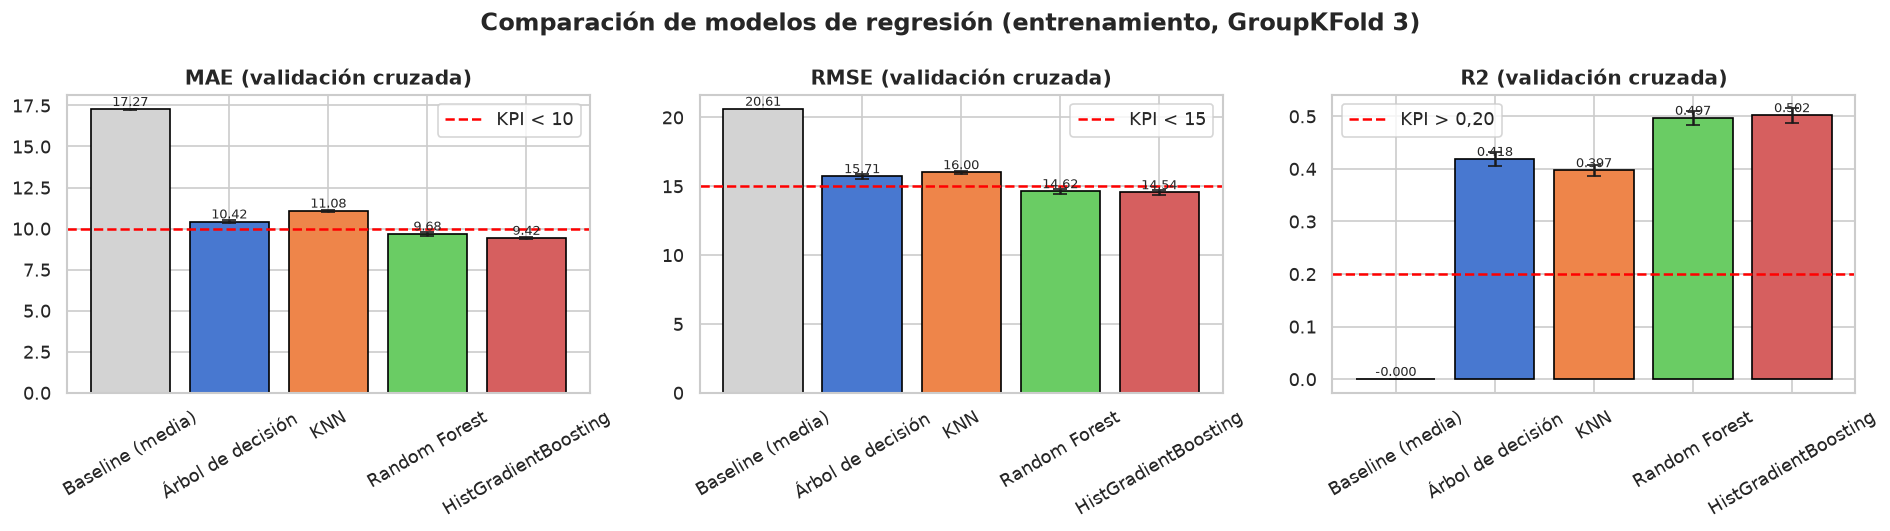

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
orden = resultados_cv_reg.index.tolist()
colores = ['lightgray'] + sns.color_palette('muted', len(orden) - 1)
for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(orden, resultados_cv_reg[f'{metrica}_cv'], yerr=resultados_cv_reg[f'{metrica}_std'],
           color=colores, edgecolor='black', capsize=4)
    ax.set_title(f'{metrica} (validación cruzada)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    for x, v in enumerate(resultados_cv_reg[f'{metrica}_cv']):
        ax.text(x, v, f'{v:.2f}' if metrica != 'R2' else f'{v:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].axhline(10, color='red', linestyle='--', label='KPI < 10'); axes[0].legend()
axes[1].axhline(15, color='red', linestyle='--', label='KPI < 15'); axes[1].legend()
axes[2].axhline(0.20, color='red', linestyle='--', label='KPI > 0,20'); axes[2].legend()
plt.suptitle('Comparación de modelos de regresión (entrenamiento, GroupKFold 3)', fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '07_comparacion_regresion_cv.png', dpi=150, bbox_inches='tight')
plt.show()

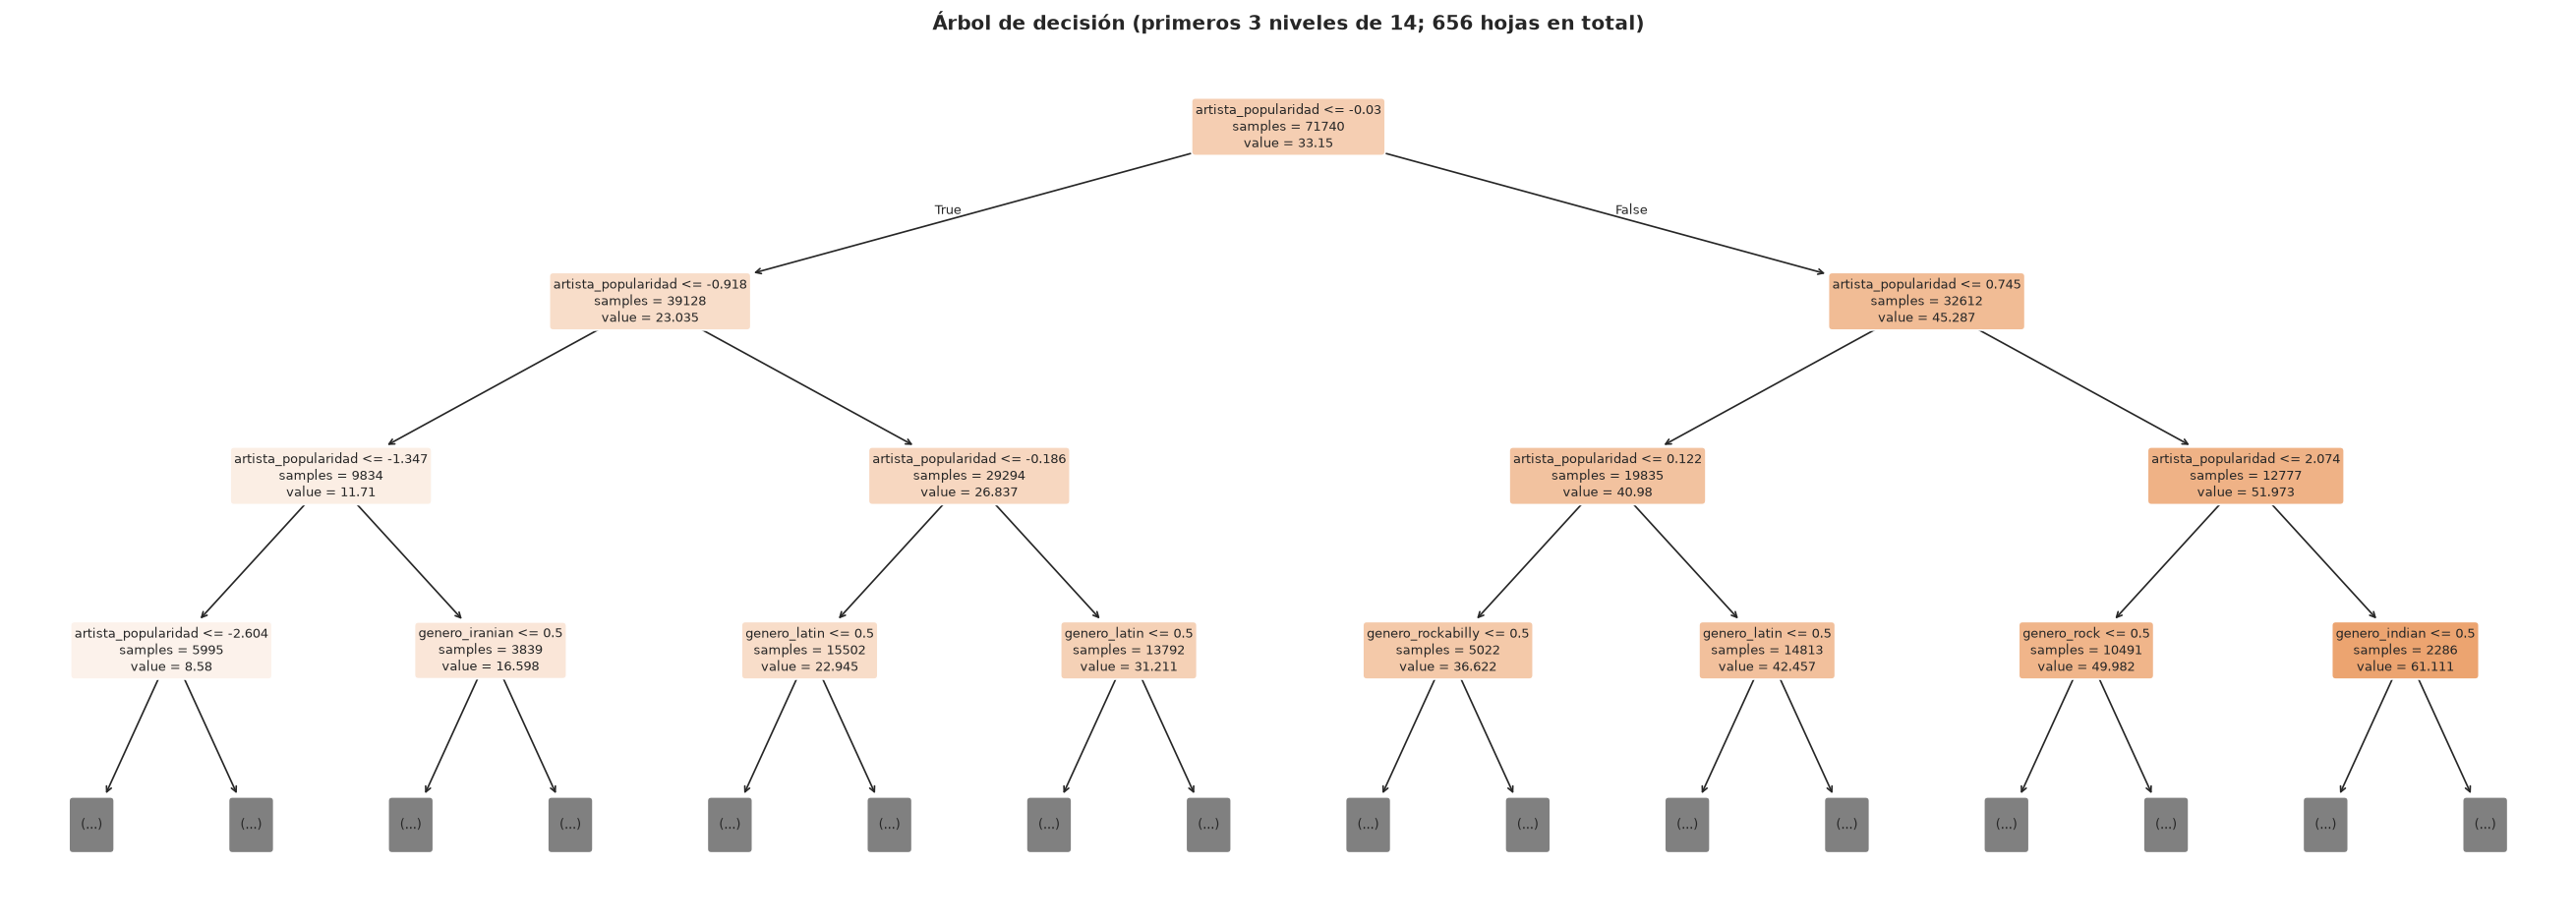

In [27]:
# Visualización de los primeros niveles del árbol de decisión ajustado (interpretabilidad)
arbol = regresores['Árbol de decisión']
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(arbol.named_steps['modelo'], max_depth=3, filled=True, rounded=True, fontsize=8, impurity=False,
          feature_names=[n.split('__')[-1] for n in arbol.named_steps['prep'].get_feature_names_out()], ax=ax)
ax.set_title(f"Árbol de decisión (primeros 3 niveles de {arbol.named_steps['modelo'].get_depth()}; "
             f"{arbol.named_steps['modelo'].get_n_leaves():,} hojas en total)", fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '07b_arbol_decision.png', dpi=130, bbox_inches='tight')
plt.show()

#### Interpretación — regresión (validación cruzada)

- Los cuatro modelos son **no lineales** y superan claramente al baseline (MAE 17,3). La
  desviación entre pliegues es baja (≤ 0,12 en MAE), así que las diferencias son estables.
- **Árbol de decisión** (MAE 10,42; R² 0,418), con `max_depth` = 14 y `min_samples_leaf` = 10:
  - Su raíz y sus primeros cortes usan la **popularidad codificada del artista** y luego el
    género, lo que anticipa el resultado de la importancia de variables.
  - Es muy interpretable, pero un solo árbol tiene alta varianza.
- **Random Forest** (MAE 9,68; R² 0,497) combina 150 árboles y reduce el error del árbol
  individual en un 7%: es la **ventaja del *bagging***.
- **HistGradientBoosting** (MAE 9,42; R² 0,502) es el mejor: el ***boosting***, que corrige
  errores en secuencia, supera también al promedio de árboles. Se elige por su menor MAE.
- **KNN** (R² 0,40) es el más débil, por la alta dimensionalidad (145 columnas, casi todas
  binarias).

#### 4.2.1 ¿Cuánto aporta el artista?

Se compara, con la misma validación cruzada y el mismo `HistGradientBoostingRegressor`
(hiperparámetros por defecto), el desempeño con y sin el artista, además de una versión
solo con audio y categóricas. Así se cuantifica cuánto de la señal viene de la canción y
cuánto del historial del artista.

In [28]:
def cv_hgb(con_artista, con_genero=True):
    prep = crear_preprocesador(con_artista)
    if not con_genero:
        prep.transformers = [t for t in prep.transformers if t[0] != 'generos']
    pipe = Pipeline([('prep', prep), ('modelo', HistGradientBoostingRegressor(random_state=SEMILLA))])
    r = cross_validate(pipe, X_train, y_train_reg, groups=grupos_train, cv=cv_grupos, scoring=scoring_reg)
    return {'MAE_cv': -r['test_MAE'].mean(), 'RMSE_cv': -r['test_RMSE'].mean(), 'R2_cv': r['test_R2'].mean()}

ablacion_artista = pd.DataFrame({
    'Solo audio + categóricas': cv_hgb(False, con_genero=False),
    'Audio + categóricas + género (versión sin artista)': cv_hgb(False),
    'Audio + categóricas + artista': cv_hgb(True, con_genero=False),
    'Audio + categóricas + género + artista (modelo final)': cv_hgb(True),
}).T
ablacion_artista.to_csv(PROCESSED_DIR / 'ablacion_artista.csv')
display(ablacion_artista.round(3))

,MAE_cv,RMSE_cv,R2_cv
Solo audio + categóricas,15.6270,19.4980,0.1050
Audio + categóricas + género (versión sin artista),11.5900,16.1870,0.3830
Audio + categóricas + artista,10.8050,15.6760,0.4210
Audio + categóricas + género + artista (modelo final),9.6850,14.6180,0.4970


#### Interpretación — aporte del artista

| Variables | MAE CV | R² CV |
|---|---:|---:|
| Solo audio + categóricas | 15,63 | 0,105 |
| + género (versión anterior) | 11,59 | 0,383 |
| + artista (sin género) | 10,81 | 0,421 |
| **+ género + artista (modelo final)** | **9,69** | **0,497** |

- **El artista es la variable más informativa por sí sola** (R² 0,42), por encima del
  género (0,38). Esto confirma la hipótesis del equipo.
- Género y artista son **complementarios**: juntos llegan a R² 0,50. El género aporta
  contexto incluso cuando el artista es poco conocido.
- La mejora se obtiene **sin fuga de información**: el codificador usa *cross-fitting*, y las
  métricas de CV y de prueba coinciden (sección 5.1).

### 4.3 Aprendizaje supervisado — Clasificación (target: bajo / medio / alto)

**Baseline:** `DummyClassifier(strategy='most_frequent')` (predice siempre "medio").

**Selección de los 4 algoritmos** (KNN, Random Forest y HistGradientBoosting coinciden con regresión,
para que la comparación entre ambos enfoques sea coherente; en clasificación se incluye además un
modelo lineal probabilístico como referencia):

| # | Modelo | Familia | Por qué se incluye |
|---|---|---|---|
| C1 | `LogisticRegression` (multinomial) | Lineal probabilístico | Referencia interpretable; entrega probabilidades calibradas por clase, útiles para priorizar canciones. Regularización L2 (`C`). |
| C2 | `KNeighborsClassifier` | Basado en instancias | "Vecinos sonoros": clasifica según canciones similares. Sin supuestos de forma funcional. |
| C3 | `RandomForestClassifier` | *Bagging* de árboles | El modelo propuesto en EP1: no lineal, captura interacciones, robusto a outliers y admite `class_weight`. |
| C4 | `HistGradientBoostingClassifier` | *Boosting* | Suele ser el más preciso en datos tabulares; rápido y con `class_weight`. |

**Métrica principal: ROC-AUC macro (one-vs-rest)**, por recomendación docente.

- La **curva ROC** muestra, para cada umbral de decisión posible, la tasa de verdaderos
  positivos (recall) frente a la tasa de falsos positivos.
- El **AUC** (área bajo esa curva) es la probabilidad de que el modelo asigne una probabilidad
  mayor a una canción de la clase que a una que no lo es: 0,5 = azar, 1 = perfecto.
- En 3 clases se calcula una curva por clase (esa clase vs. el resto) y se promedian sus AUC
  (*macro*).
- **Ventajas aquí:** no depende de un umbral fijo y no se ve afectada por el desbalance de
  clases. Mide la capacidad de **ordenar** las canciones, que es justamente el uso de negocio
  (priorizar una lista corta).

**Desempate y métricas complementarias:** F1 macro (equilibrio entre clases con el umbral por
defecto), accuracy, *balanced accuracy* y **recall de "alto"** (proporción de éxitos reales
detectados).

#### 4.3.1 Comparación de métodos de balanceo

La clase "alto" representa ~11% de las canciones. Se comparan, para **cada** algoritmo y
dentro de la validación cruzada (el remuestreo se aplica solo a los pliegues de
entrenamiento, nunca a los de validación):

| Método | Tipo | Idea | Riesgo |
|---|---|---|---|
| Sin balanceo | — | Referencia | El modelo puede ignorar la clase minoritaria |
| `class_weight='balanced'` | Sensible al costo | Penaliza más los errores en clases minoritarias, sin cambiar los datos | No disponible en KNN |
| `RandomUnderSampler` (RUS) | Submuestreo | Elimina filas de las clases mayoritarias | Pierde información (~70% de las filas) |
| `RandomOverSampler` (ROS) | Sobremuestreo | Duplica filas de las clases minoritarias | Sobreajuste a duplicados |
| `SMOTE` | Sobremuestreo sintético | Interpola nuevas canciones "alto" entre vecinos | Sobre columnas 0/1 (one-hot/multi-hot) genera valores fraccionarios |

> **SMOTENC** (SMOTE para variables mixtas) se evaluó en la versión anterior, sin artista:
> no superó a SMOTE en HistGradientBoosting (F1 macro 0,660 vs 0,666) y tardó ~16 veces más
> (`data/processed/resultados_balanceo_sin_artista.csv`). Con el artista como variable
> categórica de 31.000 valores sería inviable, por lo que se descarta.
> El remuestreo se aplica **después** del preprocesamiento, así que el artista ya está
> codificado (con *cross-fitting*) cuando se generan las filas sintéticas.

Para esta comparación se usan hiperparámetros razonables por defecto; luego se ajustan
los hiperparámetros de cada modelo con su mejor método de balanceo (4.3.2).

In [29]:
recall_alto = make_scorer(recall_score, labels=['alto'], average='macro', zero_division=0)
scoring_clf = {'AUC': 'roc_auc_ovr', 'F1_macro': 'f1_macro', 'Accuracy': 'accuracy',
               'Balanced_acc': 'balanced_accuracy', 'Recall_alto': recall_alto}

clasificadores_base = {
    'Regresión logística': LogisticRegression(max_iter=2000),
    'KNN': KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=150, min_samples_leaf=3, n_jobs=-1, random_state=SEMILLA),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=SEMILLA),
}
metodos_balanceo = {
    'Sin balanceo': None,
    'class_weight': 'class_weight',
    'RUS': RandomUnderSampler(random_state=SEMILLA),
    'ROS': RandomOverSampler(random_state=SEMILLA),
    'SMOTE': SMOTE(random_state=SEMILLA),
}

def crear_pipeline_clf(modelo, metodo):
    """Pipeline de imblearn: el remuestreo ocurre solo al ajustar (pliegues de entrenamiento)."""
    modelo = clone(modelo)
    if metodo == 'class_weight':
        if 'class_weight' not in modelo.get_params():
            return None
        modelo.set_params(class_weight='balanced')
        return PipelineImb([('prep', crear_preprocesador()), ('modelo', modelo)])
    pasos = [('prep', crear_preprocesador())]
    if metodo is not None:
        pasos.append(('balanceo', clone(metodo)))
    return PipelineImb(pasos + [('modelo', modelo)])

filas_balanceo = []
combinaciones = [(m, b) for m in clasificadores_base for b in metodos_balanceo]
for nombre_modelo, nombre_metodo in combinaciones:
    metodo = metodos_balanceo[nombre_metodo]
    pipe = crear_pipeline_clf(clasificadores_base[nombre_modelo], metodo)
    if pipe is None:
        continue
    inicio = time.time()
    r = cross_validate(pipe, X_train, y_train_clf, groups=grupos_train, cv=cv_grupos,
                       scoring=scoring_clf, error_score='raise')
    fila = {'modelo': nombre_modelo, 'balanceo': nombre_metodo}
    for metrica in scoring_clf:
        fila[metrica] = r[f'test_{metrica}'].mean()
    fila['F1_macro_std'] = r['test_F1_macro'].std()
    fila['segundos'] = round(time.time() - inicio, 1)
    filas_balanceo.append(fila)
    print(f"{nombre_modelo:22s} | {nombre_metodo:12s} | AUC {fila['AUC']:.4f} | F1 macro {fila['F1_macro']:.3f} | "
          f"recall alto {fila['Recall_alto']:.3f} | {fila['segundos']} s")

resultados_balanceo = pd.DataFrame(filas_balanceo)
resultados_balanceo.to_csv(PROCESSED_DIR / 'resultados_balanceo.csv', index=False)

Regresión logística    | Sin balanceo | AUC 0.8912 | F1 macro 0.672 | recall alto 0.319 | 40.0 s


Regresión logística    | class_weight | AUC 0.8842 | F1 macro 0.662 | recall alto 0.757 | 36.9 s


Regresión logística    | RUS          | AUC 0.8824 | F1 macro 0.663 | recall alto 0.757 | 20.4 s


Regresión logística    | ROS          | AUC 0.8842 | F1 macro 0.661 | recall alto 0.758 | 48.0 s


Regresión logística    | SMOTE        | AUC 0.8839 | F1 macro 0.664 | recall alto 0.744 | 50.7 s


...

HistGradientBoosting   | Sin balanceo | AUC 0.9085 | F1 macro 0.710 | recall alto 0.419 | 19.1 s


HistGradientBoosting   | class_weight | AUC 0.9045 | F1 macro 0.704 | recall alto 0.735 | 28.0 s


HistGradientBoosting   | RUS          | AUC 0.8960 | F1 macro 0.690 | recall alto 0.758 | 12.7 s


HistGradientBoosting   | ROS          | AUC 0.9047 | F1 macro 0.704 | recall alto 0.722 | 22.2 s


HistGradientBoosting   | SMOTE        | AUC 0.9071 | F1 macro 0.715 | recall alto 0.563 | 26.1 s


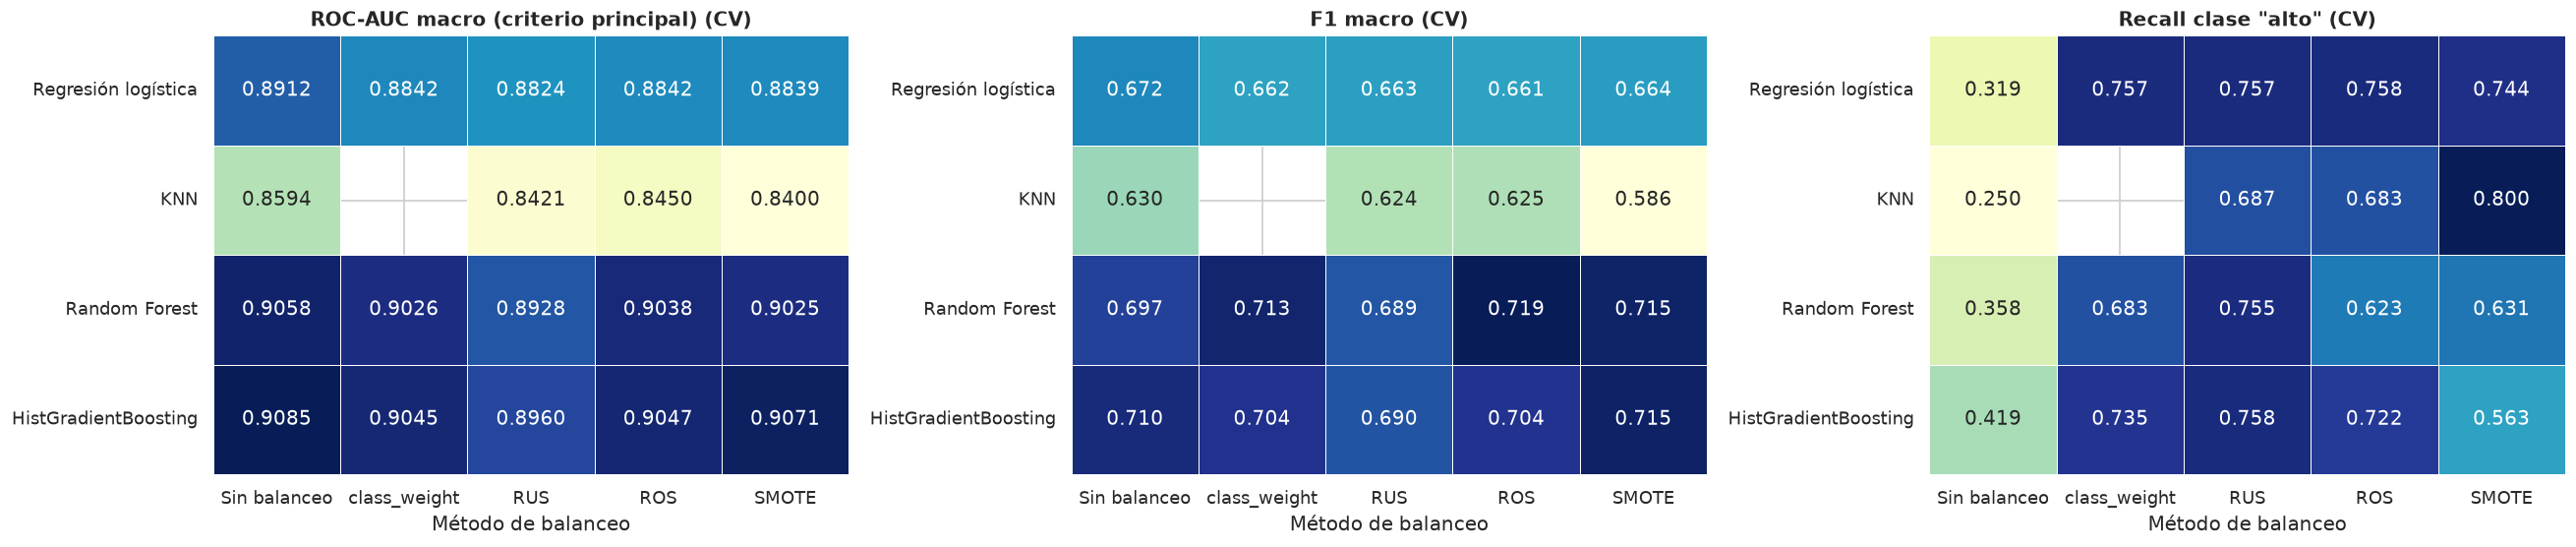

Todas las pruebas de balanceo (criterio: AUC redondeado a 3 decimales; desempate F1 macro):


,modelo,balanceo,AUC,F1_macro,Recall_alto,Balanced_acc,Accuracy,ranking_en_modelo,elegido
0,Regresión logística,Sin balanceo,0.8912,0.6722,0.3186,0.6545,0.7677,1,✅ mejor para este modelo
1,Regresión logística,class_weight,0.8842,0.6617,0.7568,0.7196,0.7082,3,
2,Regresión logística,RUS,0.8824,0.6629,0.7568,0.7204,0.7093,5,
3,Regresión logística,ROS,0.8842,0.6614,0.7577,0.7195,0.7079,4,
4,Regresión logística,SMOTE,0.8839,0.6637,0.7442,0.7188,0.7114,2,
5,KNN,Sin balanceo,0.8594,0.6299,0.2499,0.6125,0.7344,1,✅ mejor para este modelo
6,KNN,RUS,0.8421,0.6240,0.6869,0.6726,0.6685,3,
7,KNN,ROS,0.8450,0.6254,0.6832,0.6750,0.6730,2,
8,KNN,SMOTE,0.8400,0.5859,0.7999,0.6654,0.6214,4,
9,Random Forest,Sin balanceo,0.9058,0.6971,0.3577,0.6773,0.7851,1,✅ mejor para este modelo


Mejor técnica de balanceo por modelo:


,balanceo,AUC,F1_macro,Recall_alto,Accuracy
modelo,,,,,
Regresión logística,Sin balanceo,0.8912,0.6722,0.3186,0.7677
KNN,Sin balanceo,0.8594,0.6299,0.2499,0.7344
Random Forest,Sin balanceo,0.9058,0.6971,0.3577,0.7851
HistGradientBoosting,Sin balanceo,0.9085,0.7098,0.4185,0.7862


Promedio de cada técnica sobre los modelos en que se aplicó:


,AUC,F1_macro,Recall_alto,Accuracy
balanceo,,,,
Sin balanceo,0.8912,0.6773,0.3362,0.7683
class_weight,0.8971,0.6932,0.7250,0.7408
RUS,0.8783,0.6663,0.7390,0.7119
ROS,0.8844,0.6775,0.6965,0.7263
SMOTE,0.8834,0.6700,0.6844,0.7191


In [30]:
orden_metodos = list(metodos_balanceo)
fig, axes = plt.subplots(1, 3, figsize=(22, 4.8))
for ax, metrica, titulo, fmt in [(axes[0], 'AUC', 'ROC-AUC macro (criterio principal)', '.4f'),
                                 (axes[1], 'F1_macro', 'F1 macro', '.3f'),
                                 (axes[2], 'Recall_alto', 'Recall clase "alto"', '.3f')]:
    tabla = resultados_balanceo.pivot(index='modelo', columns='balanceo', values=metrica)
    tabla = tabla.reindex(index=list(clasificadores_base), columns=orden_metodos)
    sns.heatmap(tabla, annot=True, fmt=fmt, cmap='YlGnBu', ax=ax, cbar=False, linewidths=0.5, mask=tabla.isna())
    ax.set_title(f'{titulo} (CV)', fontweight='bold')
    ax.set_xlabel('Método de balanceo'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '08_comparacion_balanceo.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla explícita: cada modelo con cada técnica de balanceo
tabla_explicita = (resultados_balanceo
                   .assign(AUC_r=lambda t: t['AUC'].round(3))
                   .sort_values(['modelo', 'AUC_r', 'F1_macro'], ascending=[True, False, False]))
tabla_explicita['ranking_en_modelo'] = tabla_explicita.groupby('modelo').cumcount() + 1
tabla_explicita['elegido'] = np.where(tabla_explicita['ranking_en_modelo'] == 1, '✅ mejor para este modelo', '')
columnas_tabla = ['modelo', 'balanceo', 'AUC', 'F1_macro', 'Recall_alto', 'Balanced_acc', 'Accuracy',
                  'ranking_en_modelo', 'elegido']
tabla_explicita = tabla_explicita.set_index(['modelo', 'balanceo']).reindex(
    [(m, b) for m in clasificadores_base for b in orden_metodos if (m, b) in
     set(zip(resultados_balanceo['modelo'], resultados_balanceo['balanceo']))]).reset_index()[columnas_tabla]
tabla_explicita.to_csv(PROCESSED_DIR / 'balanceo_por_modelo_explicito.csv', index=False)
print('Todas las pruebas de balanceo (criterio: AUC redondeado a 3 decimales; desempate F1 macro):')
display(tabla_explicita.round(4))

mejor_balanceo = tabla_explicita[tabla_explicita['ranking_en_modelo'] == 1].set_index('modelo')
print('Mejor técnica de balanceo por modelo:')
display(mejor_balanceo[['balanceo', 'AUC', 'F1_macro', 'Recall_alto', 'Accuracy']].round(4))
resumen_metodo = resultados_balanceo.groupby('balanceo')[['AUC', 'F1_macro', 'Recall_alto', 'Accuracy']].mean()
print('Promedio de cada técnica sobre los modelos en que se aplicó:')
display(resumen_metodo.reindex(orden_metodos).round(4))

#### Interpretación — técnicas de balanceo (todas las pruebas)

La tabla anterior deja **explícitas las 19 combinaciones** probadas: 4 modelos × 5 técnicas,
menos `class_weight` en KNN, que no lo admite.

**Resultado clave: con ROC-AUC como criterio, "sin balanceo" es la mejor técnica en los 4
modelos.**

| Modelo | Mejor técnica (AUC) | AUC | Recall "alto" | Técnica con más recall "alto" |
|---|---|---:|---:|---|
| Regresión logística | Sin balanceo | 0,891 | 0,32 | ROS (0,76; AUC 0,884) |
| KNN | Sin balanceo | 0,859 | 0,25 | SMOTE (0,80; AUC 0,840) |
| Random Forest | Sin balanceo | 0,906 | 0,36 | RUS (0,75; AUC 0,893) |
| HistGradientBoosting | Sin balanceo | 0,909 | 0,42 | RUS (0,76; AUC 0,896) |

**¿Por qué?**
- El **AUC mide qué tan bien el modelo ordena** las canciones por probabilidad, para todos los
  umbrales posibles a la vez.
- Balancear (duplicar, sintetizar o descartar filas, o reponderar errores) cambia sobre todo
  **dónde cae el umbral** que separa las clases. No cambia cuánta información tiene el
  modelo para ordenarlas.
- Por eso el balanceo dispara el recall de "alto" (de ~0,3–0,4 a ~0,7–0,8), pero el AUC queda
  igual o baja un poco:
  - **RUS** descarta datos;
  - **ROS** y **SMOTE** introducen filas repetidas o sintéticas que distorsionan las
    probabilidades.
- `class_weight` es la técnica que menos daña el AUC en promedio (0,897) y la que más mejora
  el F1 macro (0,693).

**Conclusión:** si el objetivo es ordenar canciones (lista corta para curadores), no conviene
balancear. Si el objetivo es clasificar con el umbral por defecto y detectar la mayoría de los
éxitos, conviene `class_weight` o RUS, o bien **ajustar el umbral de decisión** del modelo sin
balancear.

#### 4.3.2 Ajuste de hiperparámetros con el mejor balanceo de cada modelo

Cada algoritmo se ajusta con la técnica de balanceo que obtuvo el mejor ROC-AUC en 4.3.1
(desempate F1 macro). La búsqueda de hiperparámetros también maximiza el ROC-AUC.

In [31]:
espacios_clf = {
    'Regresión logística': ({'modelo__C': [0.01, 0.1, 1.0, 10.0]}, 4),
    'KNN': ({'modelo__n_neighbors': [15, 25, 40, 60], 'modelo__weights': ['uniform', 'distance']}, 8),
    'Random Forest': ({'modelo__max_features': ['sqrt', 0.2, 0.33], 'modelo__min_samples_leaf': [3, 5, 10],
                       'modelo__max_depth': [None, 25]}, 5),
    'HistGradientBoosting': ({'modelo__learning_rate': [0.03, 0.05, 0.1], 'modelo__max_iter': [300, 600],
                              'modelo__max_leaf_nodes': [31, 63], 'modelo__min_samples_leaf': [20, 50, 100],
                              'modelo__l2_regularization': [0.0, 0.5, 1.0]}, 6),
}
clasificadores = {}
filas_clf = []

cv_dummy_clf = cross_validate(PipelineImb([('prep', crear_preprocesador()),
                                           ('modelo', DummyClassifier(strategy='most_frequent'))]),
                              X_train, y_train_clf, groups=grupos_train, cv=cv_grupos, scoring=scoring_clf)
filas_clf.append({'modelo': 'Baseline (clase mayoritaria)', 'balanceo': '—',
                  **{f'{m}_cv': cv_dummy_clf[f'test_{m}'].mean() for m in scoring_clf}})

for nombre, (espacio, n_iter) in espacios_clf.items():
    nombre_metodo = mejor_balanceo.loc[nombre, 'balanceo']
    metodo = metodos_balanceo[nombre_metodo]
    pipe = crear_pipeline_clf(clasificadores_base[nombre], metodo)
    clasificadores[nombre], fila = buscar_hiperparametros(
        f'{nombre} + {nombre_metodo}', pipe, espacio, scoring_clf, 'AUC', n_iter, X_train, y_train_clf)
    fila['modelo'] = nombre
    fila['balanceo'] = nombre_metodo
    filas_clf.append(fila)

resultados_cv_clf = pd.DataFrame(filas_clf).set_index('modelo')
resultados_cv_clf.to_csv(PROCESSED_DIR / 'resultados_cv_clasificacion.csv')
display(resultados_cv_clf[['balanceo', 'AUC_cv', 'AUC_std', 'F1_macro_cv', 'Accuracy_cv', 'Balanced_acc_cv',
                           'Recall_alto_cv', 'mejores_parametros', 'segundos']].round(4))

candidatos = resultados_cv_clf.drop('Baseline (clase mayoritaria)').copy()
candidatos['AUC_r'] = candidatos['AUC_cv'].astype(float).round(3)
MEJOR_CLASIFICADOR = candidatos.sort_values(['AUC_r', 'F1_macro_cv'], ascending=False).index[0]
print('=' * 80)
print(f"MODELO GANADOR: {MEJOR_CLASIFICADOR} + balanceo {candidatos.loc[MEJOR_CLASIFICADOR, 'balanceo']}")
print(f"  ROC-AUC CV = {candidatos.loc[MEJOR_CLASIFICADOR, 'AUC_cv']:.4f} | "
      f"F1 macro CV = {candidatos.loc[MEJOR_CLASIFICADOR, 'F1_macro_cv']:.4f} | "
      f"recall 'alto' CV = {candidatos.loc[MEJOR_CLASIFICADOR, 'Recall_alto_cv']:.4f}")
print('=' * 80)

Regresión logística + Sin balanceo: {'C': 10.0} (149.9 s)


KNN + Sin balanceo: {'weights': 'distance', 'n_neighbors': 60} (171.2 s)


Random Forest + Sin balanceo: {'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': None} (214.1 s)


HistGradientBoosting + Sin balanceo: {'min_samples_leaf': 50, 'max_leaf_nodes': 63, 'max_iter': 300, 'learning_rate': 0.03, 'l2_regularization': 0.0} (326.3 s)


,balanceo,AUC_cv,AUC_std,F1_macro_cv,Accuracy_cv,Balanced_acc_cv,Recall_alto_cv,mejores_parametros,segundos
modelo,,,,,,,,,
Baseline (clase mayoritaria),—,0.5000,NaN,0.2077,0.4525,0.3333,0.0000,NaN,NaN
Regresión logística,Sin balanceo,0.8912,0.0018,0.6725,0.7678,0.6548,0.3192,{'C': 10.0},149.9000
KNN,Sin balanceo,0.8654,0.0012,0.6177,0.7341,0.6023,0.2095,"{'weights': 'distance', 'n_neighbors': 60}",171.2000
Random Forest,Sin balanceo,0.9058,0.0019,0.6971,0.7851,0.6773,0.3577,"{'min_samples_leaf': 3, 'max_features': 'sqrt'...",214.1000
HistGradientBoosting,Sin balanceo,0.9089,0.0014,0.7101,0.7860,0.6944,0.4227,"{'min_samples_leaf': 50, 'max_leaf_nodes': 63,...",326.3000


MODELO GANADOR: HistGradientBoosting + balanceo Sin balanceo
  ROC-AUC CV = 0.9089 | F1 macro CV = 0.7101 | recall 'alto' CV = 0.4227


#### Interpretación — modelo ganador de clasificación

> **Ganador: HistGradientBoosting sin balanceo** — ROC-AUC CV 0,909 (± 0,001), F1 macro
> 0,710, accuracy 0,786.

- Le sigue Random Forest sin balanceo (AUC 0,906). La regresión logística llega a 0,891 y KNN
  a 0,865.
- La diferencia entre los dos ensambles es pequeña pero consistente entre pliegues (la
  desviación es ~0,002).
- **Costo de la decisión:** con el umbral por defecto (clase más probable), el recall de
  "alto" en CV es solo 0,42. El modelo ordena muy bien las canciones, pero es conservador al
  etiquetar "alto". Esto se ve en las curvas ROC y en la lista corta de la Fase 5.

### 4.4 Aprendizaje no supervisado — objetivo común de K-Means y DBSCAN

Para comparar ambos algoritmos con la **misma vara**, los dos reciben exactamente la misma tarea:

> **Agrupar las canciones usando solo cómo suenan (9 atributos de audio) y comprobar si esos grupos
> recuperan las familias musicales del catálogo (macro-géneros).**

- **Mismas entradas:** bailabilidad, energía, volumen, presencia de habla, acusticidad,
  instrumentalidad, presencia en vivo, positividad y tempo, estandarizadas con `StandardScaler`
  (K-Means y DBSCAN usan distancias euclidianas; sin escalar, el volumen en dB y el tempo en BPM
  dominarían). No se usan la popularidad ni el género: el género se reserva como **referencia
  externa** para evaluar.
- **Misma muestra de evaluación:** 20.000 canciones de entrenamiento elegidas al azar (DBSCAN no
  escala a las ~72.000), más 5.000 canciones de prueba para comprobar que los grupos generalizan.
- **Mismas métricas:**
  - *Intrínsecas* (sin usar el género): silueta (−1 a 1; mayor es mejor) y Davies-Bouldin (mayor que 0;
    menor es mejor).
  - *Extrínsecas* (contra el macro-género): **NMI** (información mutua normalizada, 0–1),
    **ARI** (índice de Rand ajustado, 0 = azar, 1 = acuerdo perfecto), homogeneidad (¿cada
    cluster contiene un solo macro-género?), completitud (¿cada macro-género cae en un solo
    cluster?) y **pureza** (% de canciones que pertenecen al macro-género mayoritario de su cluster).
- **Criterio para declarar ganador:** mayor **NMI frente al macro-género** (es el objetivo
  común); desempate por ARI.

#### Variable de referencia: macro-género

Los 114 géneros son demasiados para compararlos con 7–10 grupos (el acuerdo sería bajo por
construcción). Se agrupan manualmente en **10 macro-géneros** según la clasificación habitual
de la industria musical. A cada canción se le asigna el macro-género más frecuente entre sus
géneros (en empate, el primero en orden alfabético).

In [32]:
MACROGENEROS = {
    'Rock / Alternativo': ['alt-rock', 'alternative', 'british', 'emo', 'garage', 'goth', 'grunge', 'hard-rock',
                           'indie', 'j-rock', 'power-pop', 'psych-rock', 'punk', 'punk-rock', 'rock',
                           'rock-n-roll', 'rockabilly'],
    'Metal / Extremo': ['black-metal', 'death-metal', 'grindcore', 'hardcore', 'heavy-metal', 'industrial',
                        'metal', 'metalcore'],
    'Electrónica / Dance': ['breakbeat', 'chicago-house', 'club', 'dance', 'deep-house', 'detroit-techno',
                            'disco', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic',
                            'hardstyle', 'house', 'idm', 'j-dance', 'minimal-techno', 'party',
                            'progressive-house', 'techno', 'trance', 'trip-hop'],
    'Pop': ['anime', 'cantopop', 'chill', 'happy', 'indie-pop', 'j-idol', 'j-pop', 'k-pop', 'mandopop', 'pop',
            'pop-film', 'sad', 'synth-pop'],
    'Hip-hop / R&B / Soul': ['funk', 'gospel', 'groove', 'hip-hop', 'r-n-b', 'soul'],
    'Latino / Caribe': ['afrobeat', 'dancehall', 'latin', 'latino', 'reggae', 'reggaeton', 'salsa', 'ska',
                        'spanish', 'tango'],
    'Brasileña': ['brazil', 'forro', 'mpb', 'pagode', 'samba', 'sertanejo'],
    'Folk / Country / Acústico': ['acoustic', 'bluegrass', 'blues', 'country', 'folk', 'guitar', 'honky-tonk',
                                  'singer-songwriter', 'songwriter'],
    'Clásica / Ambiental / Jazz': ['ambient', 'classical', 'jazz', 'new-age', 'opera', 'piano', 'sleep', 'study'],
    'Infantil / Mundo / Otros': ['children', 'comedy', 'disney', 'french', 'german', 'indian', 'iranian', 'kids',
                                 'malay', 'romance', 'show-tunes', 'swedish', 'turkish', 'world-music'],
}
macro_de_genero = {g: macro for macro, generos in MACROGENEROS.items() for g in generos}
todos_generos = {c.replace('genero_', '') for c in columnas_genero}
assert set(macro_de_genero) == todos_generos and len(macro_de_genero) == 114, 'Mapeo incompleto'

def macro_de_cancion(generos):
    conteo = pd.Series([macro_de_genero[g] for g in generos]).value_counts()
    return sorted(conteo[conteo == conteo.max()].index)[0]

df_modelo['macrogenero'] = generos_por_cancion.loc[df_modelo['id_cancion']].apply(macro_de_cancion).to_numpy()
macro_train = df_modelo['macrogenero'].iloc[idx_train].to_numpy()
macro_test = df_modelo['macrogenero'].iloc[idx_test].to_numpy()
pd.DataFrame([(m, len(g), ', '.join(g)) for m, g in MACROGENEROS.items()],
             columns=['macrogenero', 'n_generos', 'generos']).to_csv(PROCESSED_DIR / 'macrogeneros.csv', index=False)
resumen_macro = (pd.Series(macro_train).value_counts().rename('canciones_train').to_frame()
                 .assign(pct=lambda t: (100 * t['canciones_train'] / t['canciones_train'].sum()).round(1)))
resumen_macro['n_generos'] = [len(MACROGENEROS[m]) for m in resumen_macro.index]
display(resumen_macro)

# Datos comunes para ambos algoritmos
variables_cluster = ['bailabilidad', 'energia', 'volumen_db', 'presencia_habla', 'acusticidad',
                     'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm']
escalador_cluster = StandardScaler().fit(X_train[variables_cluster])
Z_train = escalador_cluster.transform(X_train[variables_cluster])
Z_test = escalador_cluster.transform(X_test[variables_cluster])
rng = np.random.default_rng(SEMILLA)
idx_muestra = rng.choice(len(Z_train), size=20_000, replace=False)       # muestra común de evaluación
idx_muestra_test = rng.choice(len(Z_test), size=5_000, replace=False)
Z_muestra, macro_muestra = Z_train[idx_muestra], macro_train[idx_muestra]
K_MACRO = len(MACROGENEROS)

def pureza(referencia, grupos):
    tabla = pd.crosstab(grupos, referencia)
    return tabla.max(axis=1).sum() / tabla.to_numpy().sum()

def metricas_externas(referencia, grupos):
    return {'NMI_macro': normalized_mutual_info_score(referencia, grupos),
            'ARI_macro': adjusted_rand_score(referencia, grupos),
            'homogeneidad': homogeneity_score(referencia, grupos),
            'completitud': completeness_score(referencia, grupos),
            'pureza': pureza(referencia, grupos)}

,canciones_train,pct,n_generos
Electrónica / Dance,15220,21.2000,23
Infantil / Mundo / Otros,10093,14.1000,14
Rock / Alternativo,8355,11.6000,17
Pop,8215,11.5000,13
Clásica / Ambiental / Jazz,5933,8.3000,8
Latino / Caribe,5698,7.9000,10
Folk / Country / Acústico,5591,7.8000,9
Metal / Extremo,5337,7.4000,8
Brasileña,4136,5.8000,6
Hip-hop / R&B / Soul,3162,4.4000,6


#### 4.4.1 K-Means: cómo agrupa

K-Means divide las canciones en **k grupos esféricos** alrededor de un "centro de gravedad"
(centroide), minimizando la **inercia**: la suma de las distancias al cuadrado de cada canción
a su centroide.

1. **Inicialización (`k-means++`):** elige k canciones como centroides iniciales, separadas entre sí.
2. **Asignación:** cada canción se asigna al centroide **más cercano** (distancia euclidiana en
   el espacio estandarizado de 9 variables).
3. **Actualización:** cada centroide se recalcula como el **promedio** de las canciones de su grupo.
4. **Repetición:** los pasos 2 y 3 se repiten hasta que las asignaciones no cambian.
5. Como el resultado depende del punto de partida, se ejecuta **10 veces (`n_init=10`)** y se
   conserva la solución de menor inercia.

**Consecuencias:** toda canción queda en algún grupo (no hay "ruido"), los grupos tienden a ser
de tamaño y forma similares, y **hay que fijar k**.

**Elección de k:** como el objetivo es recuperar los macro-géneros, se usa **k = 10** (uno por
macro-género). El método del codo y la silueta se calculan para k = 2…14 solo como referencia,
para verificar que k = 10 no sea una mala elección desde el punto de vista intrínseco.

,inercia,silueta,NMI_macro
k,,,
2,"506,203.0730",0.2570,0.0860
3,"449,268.0600",0.1650,0.1130
4,"403,930.6990",0.1720,0.1170
5,"364,749.3070",0.1790,0.1360
6,"331,299.5410",0.1910,0.1400
7,"301,216.1690",0.1980,0.1460
8,"284,243.5360",0.1790,0.1340
9,"269,518.2710",0.1840,0.1350
10,"258,432.9140",0.1700,0.1320


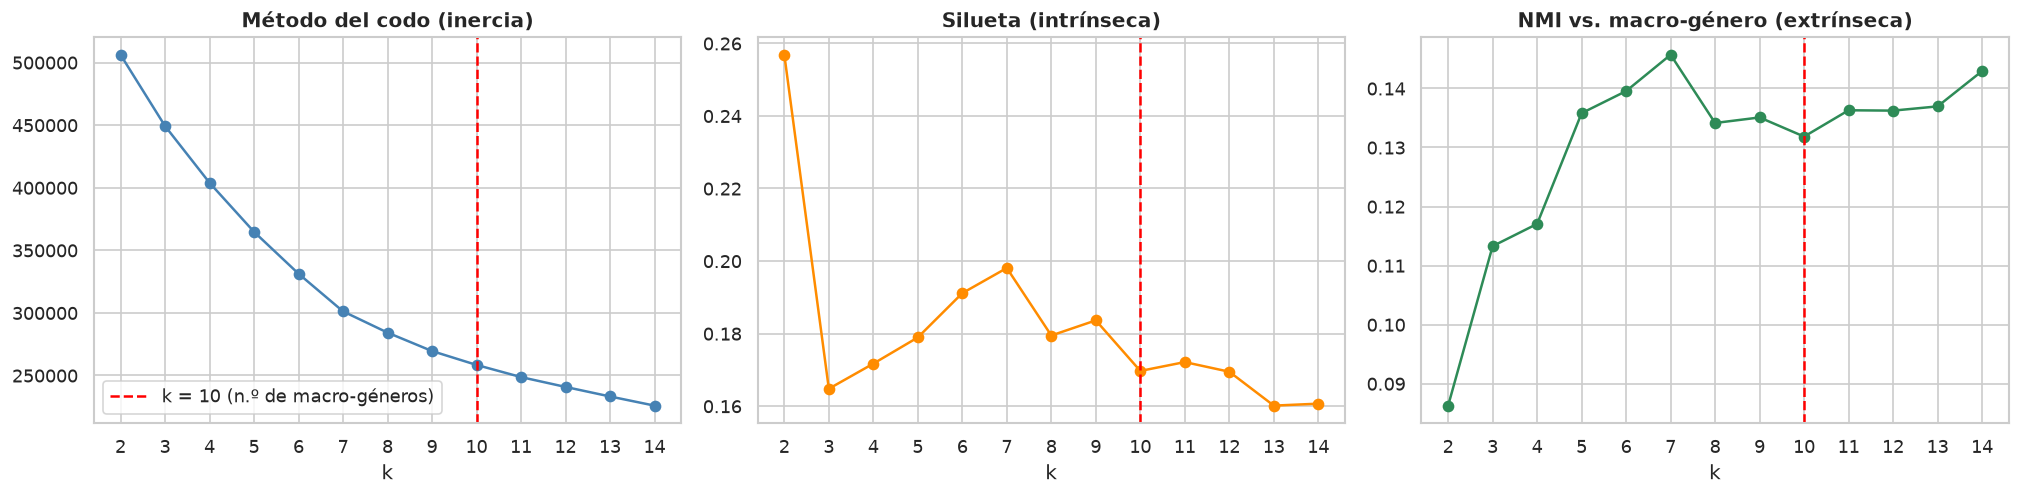

In [33]:
filas_k = []
for k in range(2, 15):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(Z_train)
    etiquetas_k = km.predict(Z_muestra)
    filas_k.append({'k': k, 'inercia': km.inertia_, 'silueta': silhouette_score(Z_muestra, etiquetas_k),
                    'NMI_macro': normalized_mutual_info_score(macro_muestra, etiquetas_k)})
seleccion_k = pd.DataFrame(filas_k).set_index('k')
display(seleccion_k.round(3))

K_PERFILES = K_MACRO
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, columna, titulo, color in [(axes[0], 'inercia', 'Método del codo (inercia)', 'steelblue'),
                                   (axes[1], 'silueta', 'Silueta (intrínseca)', 'darkorange'),
                                   (axes[2], 'NMI_macro', 'NMI vs. macro-género (extrínseca)', 'seagreen')]:
    ax.plot(seleccion_k.index, seleccion_k[columna], marker='o', color=color)
    ax.axvline(K_PERFILES, color='red', linestyle='--', label=f'k = {K_PERFILES} (n.º de macro-géneros)')
    ax.set_title(titulo, fontweight='bold'); ax.set_xlabel('k'); ax.set_xticks(seleccion_k.index)
axes[0].legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '09_kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

,valor
k,10.0000
silueta_train,0.1700
silueta_test,0.1640
davies_bouldin,1.4350
ARI_estabilidad_semillas,0.9920
NMI_macro,0.1320
ARI_macro,0.0640
homogeneidad,0.1310
completitud,0.1330
pureza,0.3030


,bailabilidad,energia,volumen_db,presencia_habla,acusticidad,instrumentalidad,presencia_en_vivo,positividad,tempo_bpm,canciones,popularidad_media,pct_alto,pct_catalogo,macro_dominante,pct_macro_dominante,top_generos
0,0.4600,0.3100,-11.7900,0.0400,0.7500,0.0300,0.1600,0.2800,112.7700,8408,31.8000,10.2000,11.7000,Infantil / Mundo / Otros,24.3000,"romance, opera, show-tunes, cantopop"
1,0.5300,0.7400,-6.1600,0.0600,0.1000,0.0300,0.1800,0.3100,109.1100,10788,37.6000,15.7000,15.0000,Electrónica / Dance,23.3000,"heavy-metal, death-metal, metalcore, grunge"
2,0.3500,0.1700,-21.3900,0.0500,0.8700,0.8300,0.1500,0.1900,105.2200,4798,29.0000,6.8000,6.7000,Clásica / Ambiental / Jazz,57.9000,"new-age, classical, ambient, sleep"
3,0.4500,0.8200,-5.2400,0.0900,0.1100,0.0400,0.2000,0.4500,163.6500,9095,34.4000,11.9000,12.7000,Rock / Alternativo,21.5000,"hardstyle, happy, drum-and-bass, j-idol"
4,0.7200,0.6600,-7.3100,0.3200,0.2600,0.0200,0.1800,0.5600,119.4700,3880,34.3000,12.1000,5.4000,Electrónica / Dance,26.9000,"dancehall, j-dance, kids, funk"
5,0.5200,0.7600,-7.0900,0.0800,0.2900,0.0800,0.7600,0.5000,123.3500,4560,35.4000,6.2000,6.4000,Brasileña,28.2000,"pagode, sertanejo, samba, mpb"
6,0.7100,0.7700,-5.9100,0.0600,0.1400,0.0300,0.1700,0.7500,120.1200,13337,33.4000,14.8000,18.6000,Electrónica / Dance,26.6000,"disco, dance, forro, party"
7,0.5800,0.7400,-8.4500,0.0700,0.1000,0.8000,0.1700,0.3300,126.6400,7628,27.3000,3.4000,10.6000,Electrónica / Dance,57.8000,"minimal-techno, detroit-techno, study, grindcore"
8,0.6600,0.4900,-9.3400,0.0600,0.6200,0.0500,0.1700,0.6600,115.9600,8508,33.7000,10.1000,11.9000,Folk / Country / Acústico,17.4000,"tango, honky-tonk, children, rock-n-roll"
9,0.5600,0.7000,-11.3200,0.8800,0.7800,0.0000,0.7300,0.4300,100.2200,738,23.4000,0.5000,1.0000,Infantil / Mundo / Otros,94.2000,"comedy, show-tunes, kids, children"


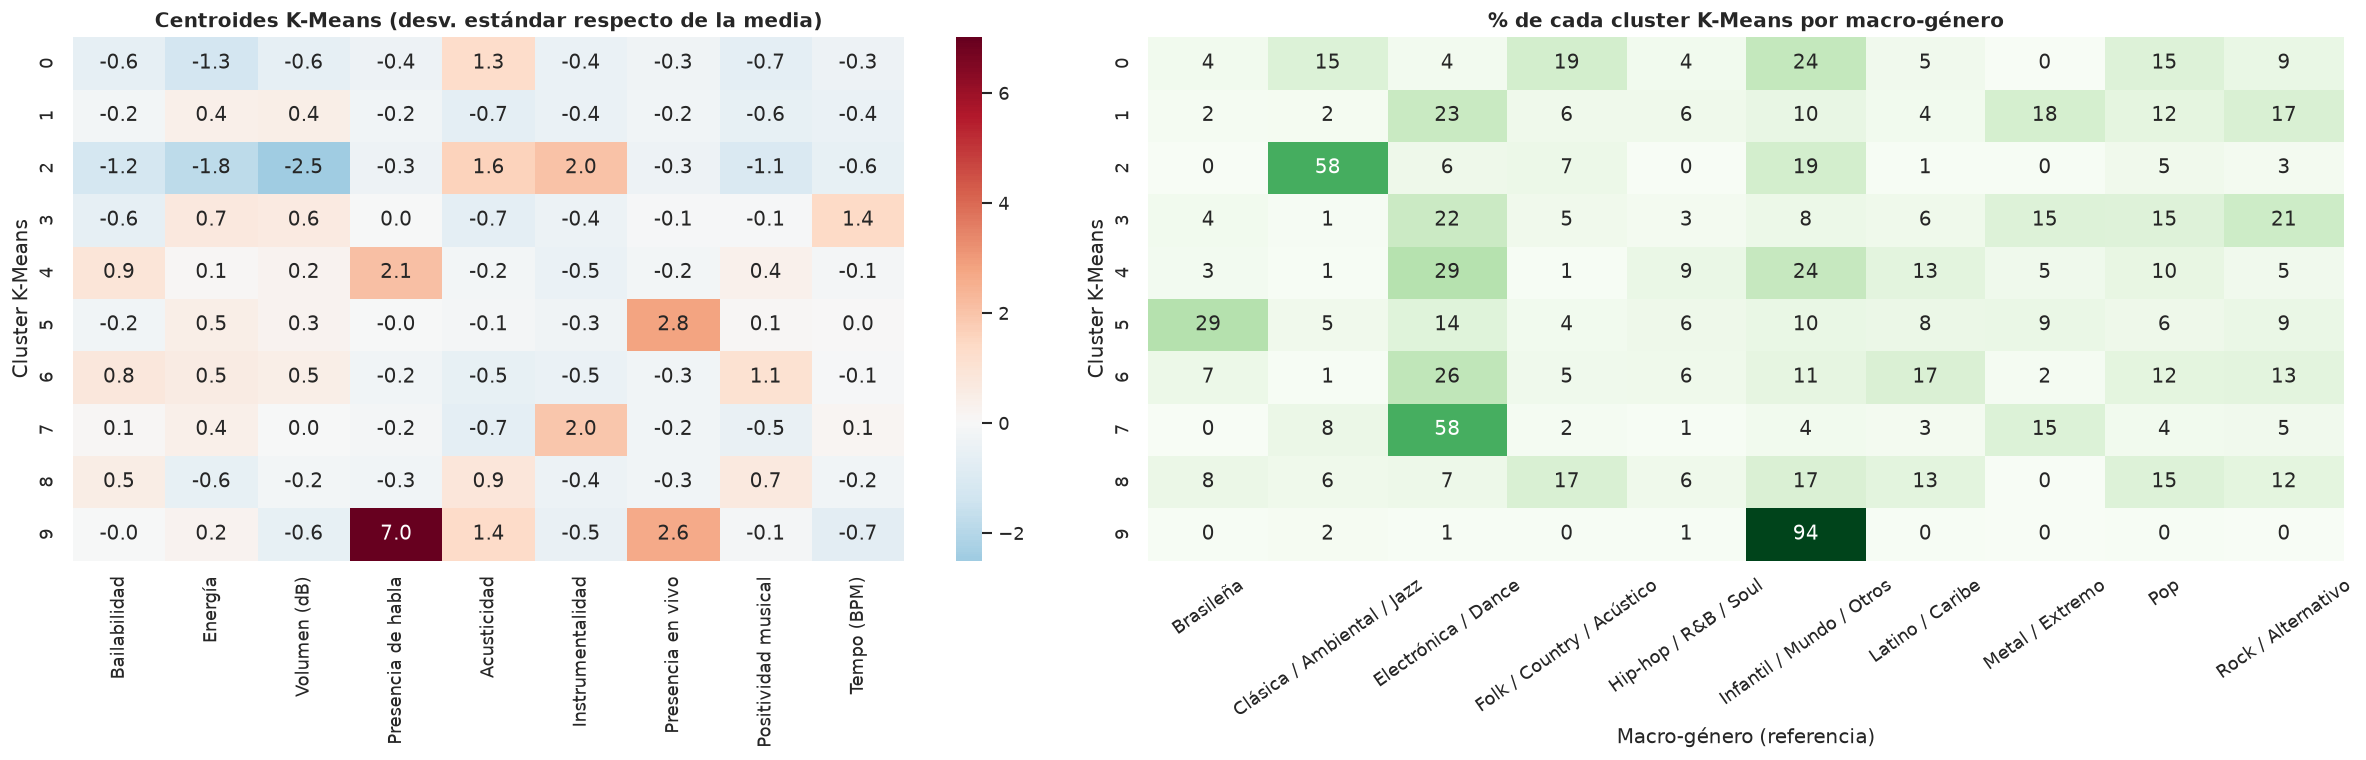

In [34]:
kmeans = KMeans(n_clusters=K_PERFILES, n_init=10, random_state=SEMILLA).fit(Z_train)
perfil_train = kmeans.labels_
perfil_muestra = perfil_train[idx_muestra]
perfil_test_muestra = kmeans.predict(Z_test[idx_muestra_test])
ari_semillas = [adjusted_rand_score(perfil_train,
                                    KMeans(n_clusters=K_PERFILES, n_init=10, random_state=s).fit_predict(Z_train))
                for s in [1, 7, 21, 99]]
metricas_kmeans = {
    'k': K_PERFILES,
    'silueta_train': silhouette_score(Z_muestra, perfil_muestra),
    'silueta_test': silhouette_score(Z_test[idx_muestra_test], perfil_test_muestra),
    'davies_bouldin': davies_bouldin_score(Z_muestra, perfil_muestra),
    'ARI_estabilidad_semillas': float(np.mean(ari_semillas)),
    **metricas_externas(macro_muestra, perfil_muestra),
}
display(pd.Series(metricas_kmeans).round(3).to_frame('valor'))

# Perfil de cada cluster
centroides = pd.DataFrame(escalador_cluster.inverse_transform(kmeans.cluster_centers_), columns=variables_cluster)
centroides_z = pd.DataFrame(kmeans.cluster_centers_, columns=variables_cluster)
info_train = pd.DataFrame({'cluster': perfil_train, 'popularidad': y_train_reg.to_numpy(),
                           'clase': y_train_clf.to_numpy(), 'macrogenero': macro_train,
                           'genero_principal': df_modelo['genero_principal'].iloc[idx_train].to_numpy()})
resumen_perfiles = info_train.groupby('cluster').agg(
    canciones=('popularidad', 'size'), popularidad_media=('popularidad', 'mean'),
    pct_alto=('clase', lambda s: 100 * s.eq('alto').mean()))
resumen_perfiles['pct_catalogo'] = 100 * resumen_perfiles['canciones'] / len(info_train)
resumen_perfiles['macro_dominante'] = info_train.groupby('cluster')['macrogenero'].agg(lambda s: s.value_counts().index[0])
resumen_perfiles['pct_macro_dominante'] = info_train.groupby('cluster')['macrogenero'].agg(
    lambda s: 100 * s.value_counts(normalize=True).iloc[0])
resumen_perfiles['top_generos'] = info_train.groupby('cluster')['genero_principal'].agg(
    lambda s: ', '.join(s.value_counts().head(4).index))
pd.set_option('display.max_colwidth', 80)
display(centroides.round(2).join(resumen_perfiles.round(1)))
pd.reset_option('display.max_colwidth')
resumen_perfiles.to_csv(PROCESSED_DIR / 'kmeans_perfiles.csv')

fig, axes = plt.subplots(1, 2, figsize=(20, 6.5), gridspec_kw={'width_ratios': [1, 1.15]})
sns.heatmap(centroides_z.rename(columns=ETIQUETAS), annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Centroides K-Means (desv. estándar respecto de la media)', fontweight='bold')
axes[0].set_ylabel('Cluster K-Means')
cruce_km = pd.crosstab(perfil_muestra, macro_muestra, normalize='index').mul(100)
sns.heatmap(cruce_km, annot=True, fmt='.0f', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('% de cada cluster K-Means por macro-género', fontweight='bold')
axes[1].set_xlabel('Macro-género (referencia)'); axes[1].set_ylabel('Cluster K-Means')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '10_kmeans_perfiles_vs_macrogenero.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.4.2 ¿Se ven agrupaciones en 3 dimensiones? (PCA)

El **análisis de componentes principales (PCA)** resume las 9 variables de audio en unas pocas
direcciones nuevas (componentes) que conservan la mayor varianza posible. Proyectar las canciones
en las **3 primeras componentes** permite verlas en 3D: si los macro-géneros o los clusters
formaran grupos separados, aparecerían como "nubes" distintas. Se grafica una muestra de 6.000
canciones desde dos ángulos, coloreada por macro-género (referencia) y por cluster K-Means.

Varianza explicada por componente: [32.  16.  13.9] -> total 61.9%


,PC1,PC2,PC3
Bailabilidad,0.2500,0.5600,-0.1100
Energía,0.5100,-0.2800,0.0100
Volumen (dB),0.5200,-0.0800,-0.0500
Presencia de habla,0.1000,0.0500,0.6400
Acusticidad,-0.4400,0.3100,0.2100
Instrumentalidad,-0.2800,-0.3200,-0.1900
Presencia en vivo,0.0900,-0.2000,0.6800
Positividad musical,0.3000,0.5300,-0.0200
Tempo (BPM),0.1900,-0.2800,-0.1600


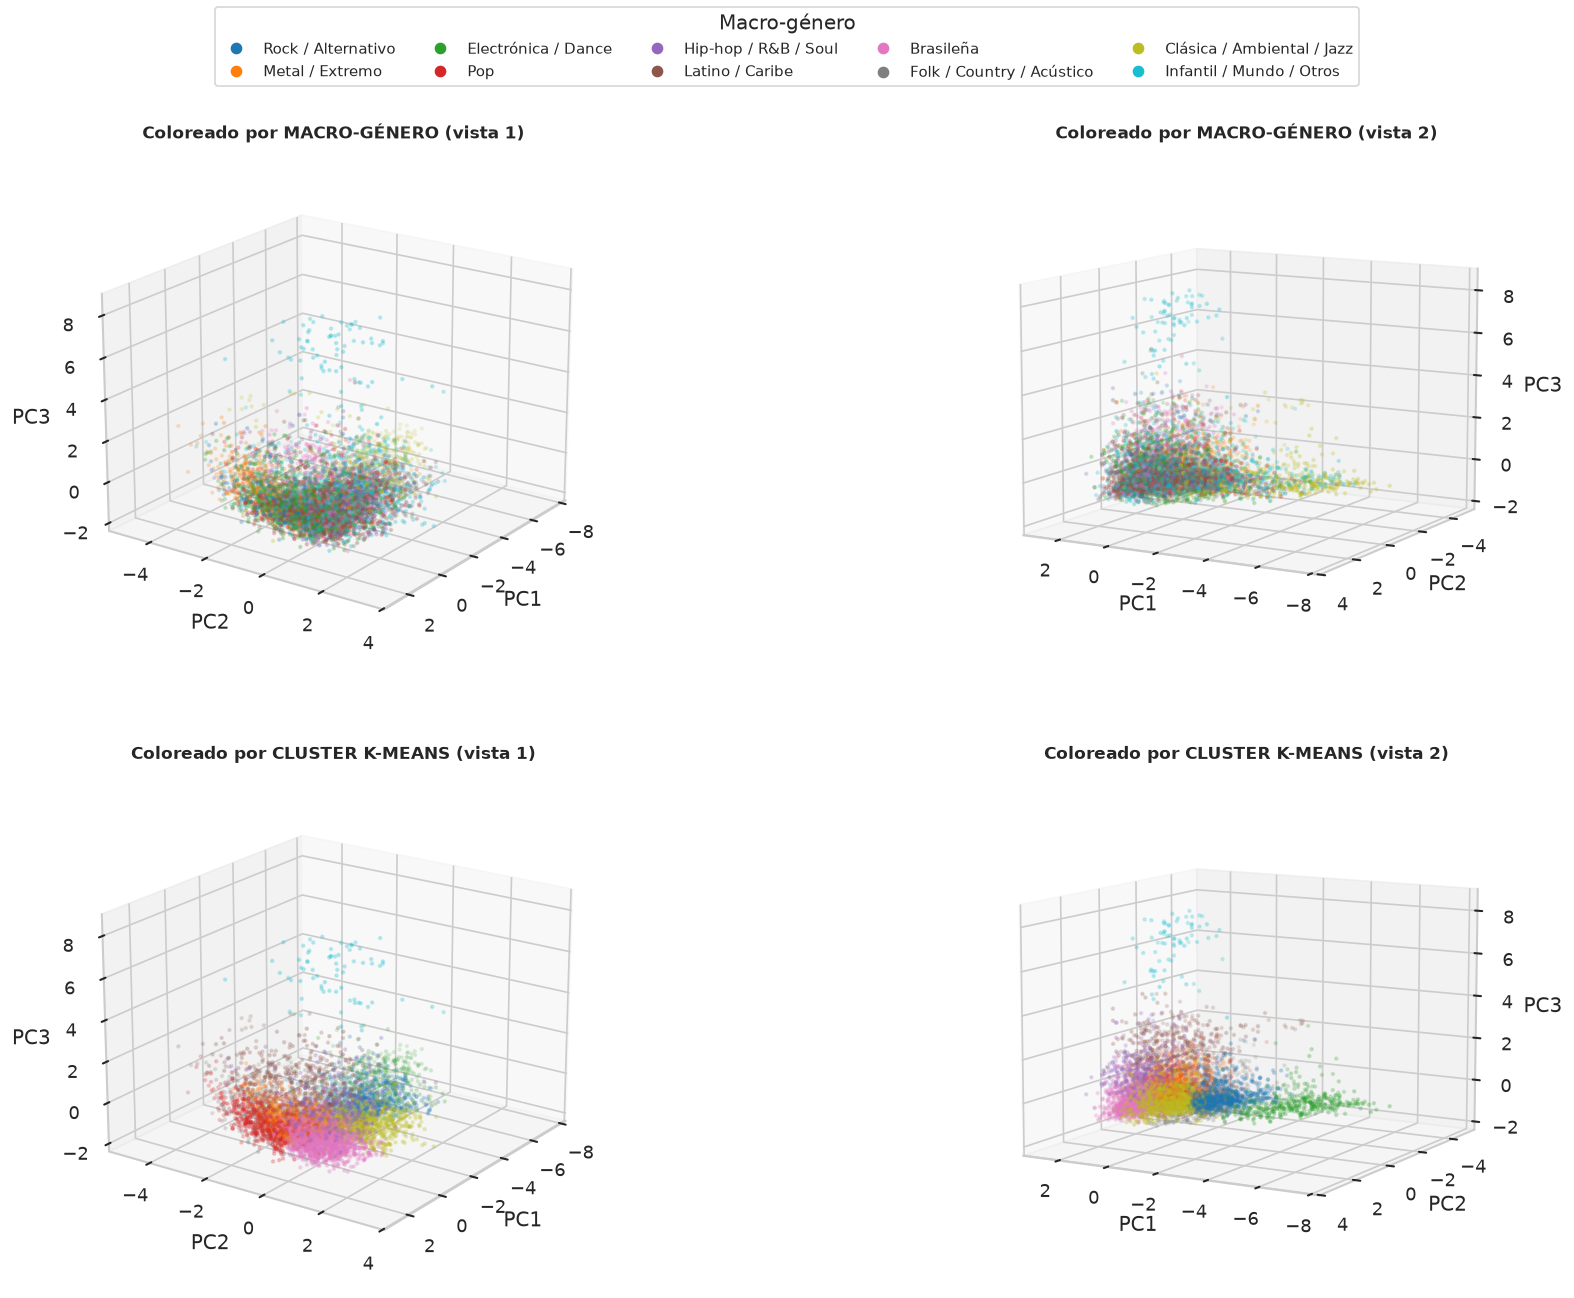

In [35]:
pca3 = PCA(n_components=3, random_state=SEMILLA).fit(Z_train)
cargas = pd.DataFrame(pca3.components_.T, index=[ETIQUETAS[v] for v in variables_cluster],
                      columns=['PC1', 'PC2', 'PC3'])
print('Varianza explicada por componente:', (100 * pca3.explained_variance_ratio_).round(1),
      f'-> total {100 * pca3.explained_variance_ratio_.sum():.1f}%')
display(cargas.round(2))

idx_3d = idx_muestra[:6_000]
P = pca3.transform(Z_train[idx_3d])
paleta_macro = dict(zip(MACROGENEROS, sns.color_palette('tab10', K_MACRO)))
colores_macro = [paleta_macro[m] for m in macro_train[idx_3d]]
colores_km = [sns.color_palette('tab10', K_PERFILES)[c] for c in perfil_train[idx_3d]]

def grafico_3d(fig, posicion, colores, titulo, elev, azim):
    ax = fig.add_subplot(posicion, projection='3d')
    ax.scatter(P[:, 0], P[:, 1], P[:, 2], c=colores, s=3, alpha=0.5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title(titulo, fontweight='bold', fontsize=10); ax.view_init(elev=elev, azim=azim)
    return ax

fig = plt.figure(figsize=(18, 12))
grafico_3d(fig, 221, colores_macro, 'Coloreado por MACRO-GÉNERO (vista 1)', 20, 35)
grafico_3d(fig, 222, colores_macro, 'Coloreado por MACRO-GÉNERO (vista 2)', 10, 120)
grafico_3d(fig, 223, colores_km, 'Coloreado por CLUSTER K-MEANS (vista 1)', 20, 35)
grafico_3d(fig, 224, colores_km, 'Coloreado por CLUSTER K-MEANS (vista 2)', 10, 120)
fig.legend(handles=[plt.Line2D([], [], marker='o', linestyle='', color=c, label=m) for m, c in paleta_macro.items()],
           loc='upper center', ncol=5, fontsize=9, title='Macro-género')
plt.subplots_adjust(top=0.9)
plt.savefig(IMAGES_DIR / '11_pca_3d_kmeans_macrogenero.png', dpi=130, bbox_inches='tight')
plt.show()

#### Interpretación — K-Means frente al macro-género y PCA 3D

**Perfiles encontrados (k = 10).** Nombres asignados a partir de los centroides:

| Cluster | Perfil sonoro | Rasgos (DE vs. media) | Macro-género dominante | % "alto" |
|---|---|---|---|---:|
| 0 | Acústicas melancólicas | acusticidad +1,3, energía −1,3 | Infantil/Mundo (24%), Folk (19%) | 10,2% |
| 1 | Intensas y oscuras | energía/volumen +0,4, positividad −0,6 | Electrónica (23%), Metal (18%), Rock (17%) | **15,7%** |
| 2 | Ambientales / clásicas | volumen −2,5, instrumentalidad +2,0 | **Clásica/Ambiental (58%)** | 6,8% |
| 3 | Rápidas e intensas | tempo +1,4, energía +0,7 | Electrónica (22%), Rock (21%) | 11,9% |
| 4 | Rítmicas con voz hablada | habla +2,1, bailabilidad +0,9 | Electrónica (29%), Mundo (24%), Latino (13%) | 12,1% |
| 5 | En vivo | presencia en vivo +2,8 | **Brasileña (29%)** | 6,2% |
| 6 | Bailables y alegres | positividad +1,1, bailabilidad +0,8 | Electrónica (26%), Latino (17%) | 14,8% |
| 7 | Electrónica instrumental | instrumentalidad +2,0, energía +0,4 | **Electrónica (58%)** | 3,4% |
| 8 | Acústicas alegres | acusticidad +0,9, positividad +0,7 | Folk (17%), Mundo (17%), Pop (15%) | 10,1% |
| 9 | Habladas (comedia) | habla +7,0, en vivo +2,6 | **Infantil/Mundo/Otros (94%)** | 0,5% |

**¿Recupera K-Means los macro-géneros? Solo parcialmente.**
- **NMI = 0,13, ARI = 0,06 y pureza = 30%.** Al asignar a cada canción el macro-género
  mayoritario de su cluster, se acierta el 30% de las veces. Con 10 grupos, el azar daría
  ~10%, y siempre elegir el macro-género más frecuente daría 21%.
- **Clusters que sí corresponden a un macro-género:**
  - comedia (94%);
  - ambiental/clásica (58%);
  - electrónica instrumental (58%);
  - "en vivo", donde la música brasileña es el macro-género más frecuente (29%).
- **El resto de los clusters mezcla macro-géneros.** El metal, el rock y la electrónica
  intensa "suenan" parecido (alta energía y volumen), y el pop, el latino y la música bailable
  comparten bailabilidad y positividad.

**La silueta (0,17) indica una estructura débil.** Se mantiene en prueba (0,16) y es muy
estable entre semillas (ARI 0,99). Con k = 7 la silueta era algo mayor (0,198), pero se usa
k = 10 para alinear el número de grupos con el objetivo (10 macro-géneros).

**PCA 3D.** Las 3 primeras componentes explican el 62% de la varianza del audio:
- **PC1 (32%) = "intensidad"**: energía y volumen positivos, acusticidad negativa.
- **PC2 (16%) = "baile y ánimo"**: bailabilidad y positividad.
- **PC3 (14%) = "voz hablada / en vivo"**: presencia de habla y en vivo.

En el gráfico 3D:
- **coloreada por macro-género**, la nube está **mezclada**: no hay "islas" por género, salvo
  el extremo de PC3 (comedia/hablado) y la cola de PC1 negativo (clásica/ambiental);
- **coloreada por cluster** (los colores de K-Means corresponden a los clusters 0–9, no a la
  leyenda de macro-géneros), K-Means **corta la nube continua en regiones**, como rebanadas de
  un mismo bloque.

Esto confirma visualmente que **el sonido por sí solo separa pocas familias musicales**: la
mayoría de los géneros se distinguen por factores culturales (idioma, escena, mercado) que el
audio no capta.

### 4.5 DBSCAN: cómo agrupa

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) agrupa por **densidad**:

1. Una canción es **núcleo** si tiene al menos `min_samples` canciones (incluida ella misma) a una
   distancia menor que `eps`.
2. Las canciones núcleo que están a menos de `eps` entre sí se encadenan en el **mismo cluster**;
   las canciones no núcleo cercanas a un núcleo se suman a su cluster (**borde**).
3. Las canciones que no están cerca de ningún núcleo quedan como **ruido** (etiqueta −1).

**Diferencias con K-Means:** no hay que fijar el número de grupos (surge de la densidad), los
grupos pueden tener cualquier forma y existe la categoría "ruido". A cambio, depende mucho de
`eps` y le cuesta separar grupos cuando la densidad es pareja.

**Misma tarea que K-Means:** mismas 9 variables estandarizadas, misma muestra de 20.000
canciones y misma evaluación contra el macro-género.

- **`min_samples = 18`** (regla práctica: 2 × número de variables).
- **`eps`** se elige con la **curva de k-distancias** (distancia de cada canción a su vecino
  número 18, ordenada): el **codo** de la curva separa las zonas densas de las dispersas. Se
  detecta como el punto más alejado de la recta entre los extremos (método *Kneedle*). Se
  analiza además la sensibilidad a otros valores de `eps`, incluido su efecto sobre el NMI.

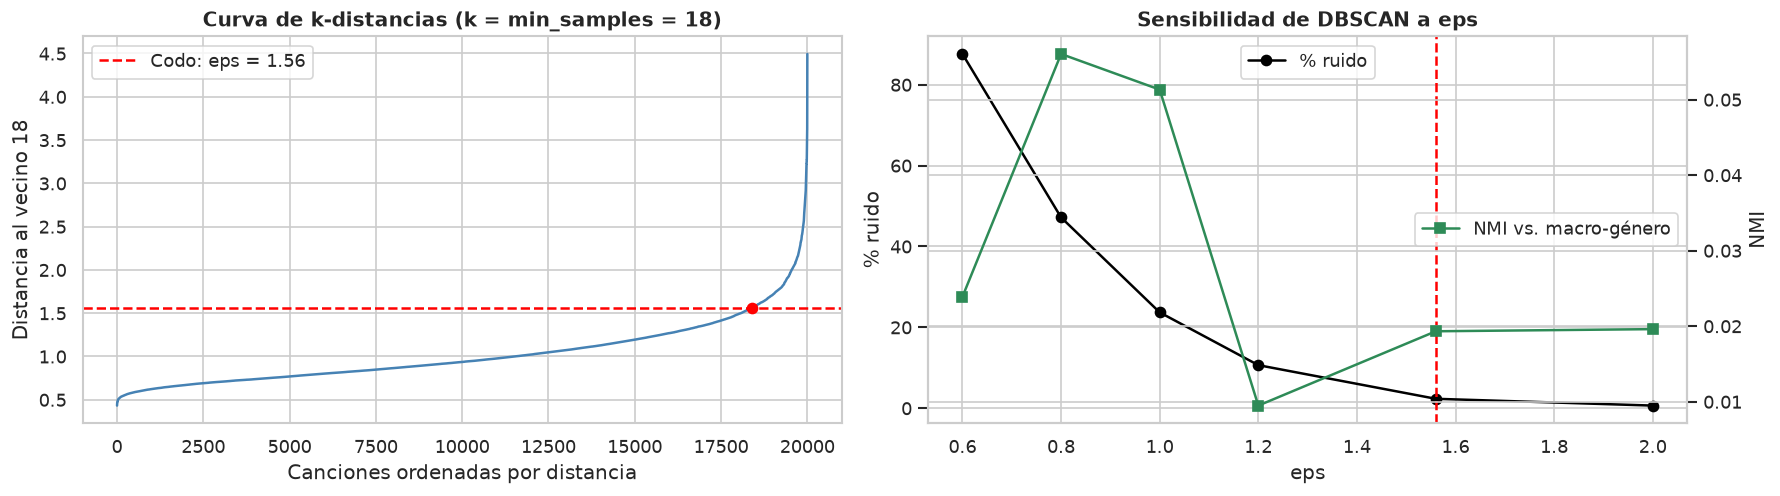

eps elegido por el codo: 1.56


,n_clusters,pct_ruido,pct_cluster_mayor,silueta_sin_ruido,NMI_macro,ARI_macro
eps,,,,,,
0.6000,15,87.5900,10.3400,-0.0790,0.0240,-0.0040
0.8000,6,47.1650,47.5650,0.1120,0.0560,0.0050
1.0000,3,23.6850,71.9250,0.3040,0.0510,0.0160
1.2000,2,10.6350,89.2750,0.5850,0.0090,0.0010
1.5600,2,2.3150,96.9400,0.5710,0.0190,0.0000
2.0000,2,0.6350,98.4400,0.5600,0.0200,0.0000


In [36]:
MIN_SAMPLES = 2 * len(variables_cluster)
distancias_k = np.sort(NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z_muestra).kneighbors(Z_muestra)[0][:, -1])
x_norm = np.linspace(0, 1, len(distancias_k))
y_norm = (distancias_k - distancias_k[0]) / (distancias_k[-1] - distancias_k[0])
i_codo = int(np.argmax(x_norm - y_norm))
EPS = round(float(distancias_k[i_codo]), 2)

filas_eps = []
for eps in sorted({0.6, 0.8, 1.0, 1.2, EPS, 2.0}):
    etiquetas = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Z_muestra)
    validos = etiquetas != -1
    n_clusters = len(set(etiquetas[validos]))
    filas_eps.append({
        'eps': eps, 'n_clusters': n_clusters, 'pct_ruido': 100 * (~validos).mean(),
        'pct_cluster_mayor': 100 * pd.Series(etiquetas[validos]).value_counts().iloc[0] / len(etiquetas) if n_clusters else 0,
        'silueta_sin_ruido': (silhouette_score(Z_muestra[validos], etiquetas[validos], sample_size=8_000,
                                               random_state=SEMILLA) if n_clusters > 1 else np.nan),
        'NMI_macro': normalized_mutual_info_score(macro_muestra, etiquetas),
        'ARI_macro': adjusted_rand_score(macro_muestra, etiquetas),
    })
sensibilidad_eps = pd.DataFrame(filas_eps).set_index('eps')
sensibilidad_eps.to_csv(PROCESSED_DIR / 'dbscan_sensibilidad_eps.csv')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
axes[0].plot(distancias_k, color='steelblue')
axes[0].axhline(EPS, color='red', linestyle='--', label=f'Codo: eps = {EPS}')
axes[0].scatter([i_codo], [EPS], color='red', zorder=3)
axes[0].set_title(f'Curva de k-distancias (k = min_samples = {MIN_SAMPLES})', fontweight='bold')
axes[0].set_xlabel('Canciones ordenadas por distancia'); axes[0].set_ylabel(f'Distancia al vecino {MIN_SAMPLES}')
axes[0].legend()
ax2 = axes[1].twinx()
axes[1].plot(sensibilidad_eps.index, sensibilidad_eps['pct_ruido'], marker='o', color='black', label='% ruido')
ax2.plot(sensibilidad_eps.index, sensibilidad_eps['NMI_macro'], marker='s', color='seagreen', label='NMI vs. macro-género')
axes[1].axvline(EPS, color='red', linestyle='--')
axes[1].set_xlabel('eps'); axes[1].set_ylabel('% ruido'); ax2.set_ylabel('NMI')
axes[1].set_title('Sensibilidad de DBSCAN a eps', fontweight='bold')
axes[1].legend(loc='upper center'); ax2.legend(loc='center right')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '12_dbscan_k_distancias.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'eps elegido por el codo: {EPS}')
display(sensibilidad_eps.round(3))

,valor
eps,1.5600
min_samples,18.0000
n_clusters,2.0000
pct_ruido_train,2.3150
pct_ruido_test,2.8800
silueta_sin_ruido,0.5710
NMI_macro,0.0190
ARI_macro,0.0000
homogeneidad,0.0100
completitud,0.1480


,canciones,popularidad_media,pct_muestra,top_generos
grupo,,,,
Cluster 0,19388,33.4000,96.9000,"deep-house, salsa, acoustic, spanish, malay"
Cluster 1,149,22.8000,0.7000,comedy
Ruido (atípicas),463,27.5000,2.3000,"sleep, comedy, study, new-age, iranian"


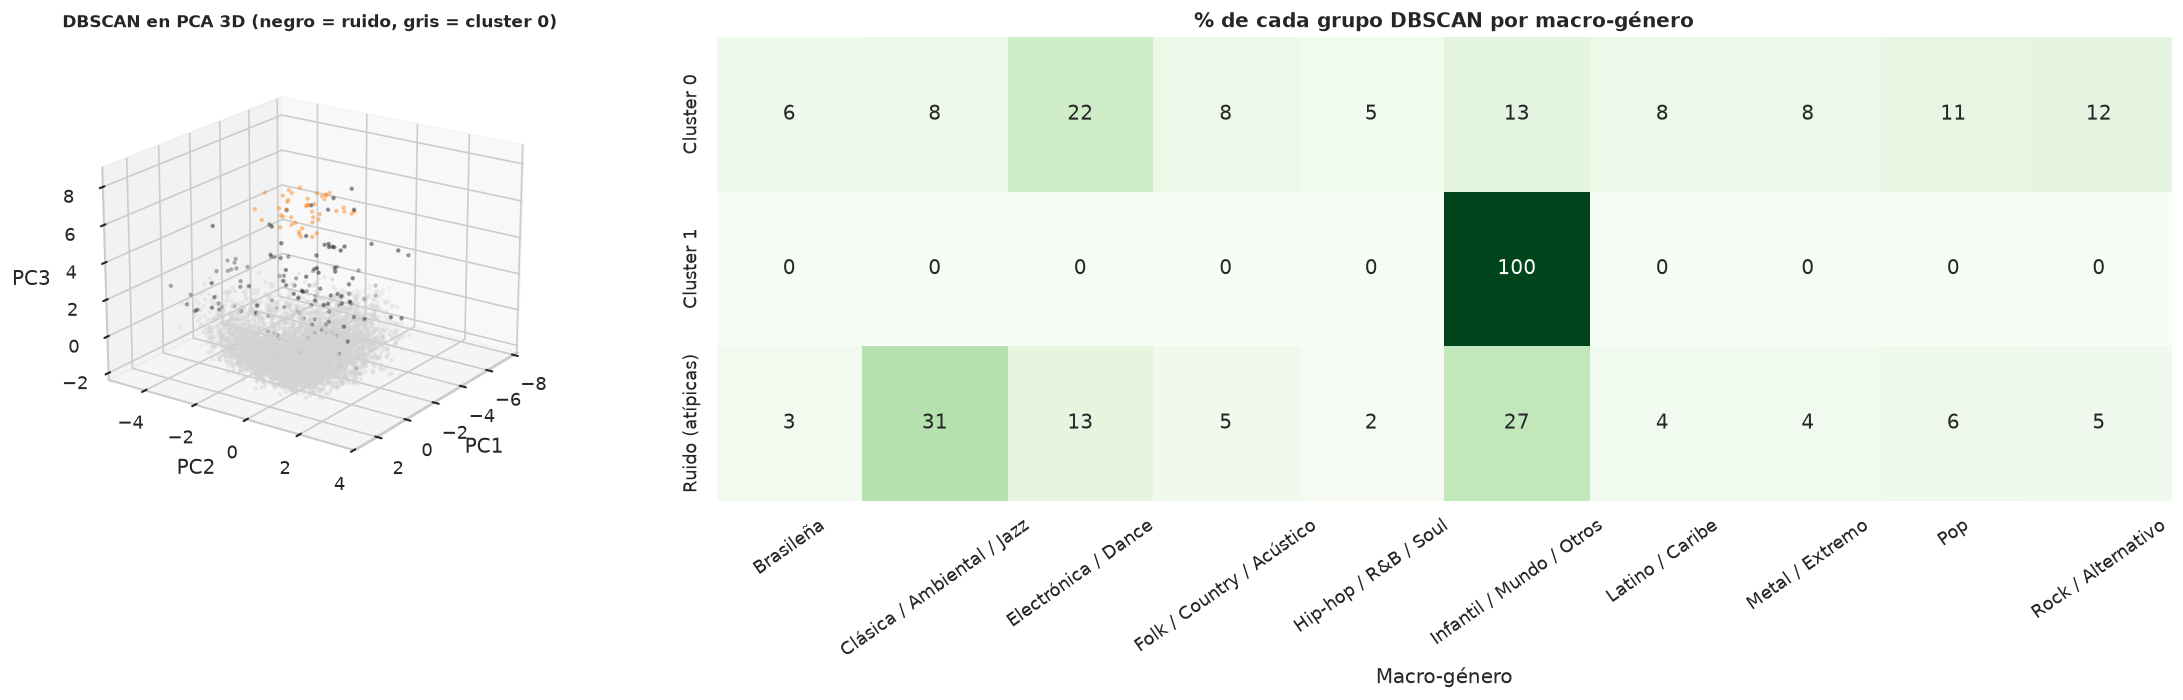

In [37]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(Z_muestra)
etiquetas_db = dbscan.labels_
validos = etiquetas_db != -1
nombre_grupo = lambda c: 'Ruido (atípicas)' if c == -1 else f'Cluster {c}'

# Generalización: cada canción de prueba toma el cluster del núcleo más cercano si está a <= eps; si no, ruido
nucleos = Z_muestra[dbscan.core_sample_indices_]
etiquetas_nucleos = etiquetas_db[dbscan.core_sample_indices_]
dist, vecino = NearestNeighbors(n_neighbors=1).fit(nucleos).kneighbors(Z_test[idx_muestra_test])
etiquetas_test_db = np.where(dist[:, 0] <= EPS, etiquetas_nucleos[vecino[:, 0]], -1)

metricas_dbscan = {
    'eps': EPS, 'min_samples': MIN_SAMPLES, 'n_clusters': int(len(set(etiquetas_db[validos]))),
    'pct_ruido_train': 100 * (~validos).mean(), 'pct_ruido_test': 100 * (etiquetas_test_db == -1).mean(),
    'silueta_sin_ruido': silhouette_score(Z_muestra[validos], etiquetas_db[validos], sample_size=8_000,
                                          random_state=SEMILLA),
    **metricas_externas(macro_muestra, etiquetas_db),
}
display(pd.Series(metricas_dbscan).round(3).to_frame('valor'))

info_db = pd.DataFrame({'grupo': [nombre_grupo(c) for c in etiquetas_db], 'macrogenero': macro_muestra,
                        'popularidad': y_train_reg.to_numpy()[idx_muestra],
                        'genero_principal': df_modelo['genero_principal'].iloc[idx_train].to_numpy()[idx_muestra]})
resumen_db = info_db.groupby('grupo').agg(canciones=('popularidad', 'size'), popularidad_media=('popularidad', 'mean'))
resumen_db['pct_muestra'] = 100 * resumen_db['canciones'] / len(info_db)
resumen_db['top_generos'] = info_db.groupby('grupo')['genero_principal'].agg(lambda s: ', '.join(s.value_counts().head(5).index))
display(resumen_db.round(1))

fig = plt.figure(figsize=(19, 6))
ax3d = fig.add_subplot(131, projection='3d')
P_db = pca3.transform(Z_muestra[:6_000])
col_db = [matplotlib.colors.to_rgba('black' if c == -1 else ('lightgray' if c == 0 else sns.color_palette('tab10')[c % 10]))
          for c in etiquetas_db[:6_000]]
ax3d.scatter(P_db[:, 0], P_db[:, 1], P_db[:, 2], c=col_db, s=3, alpha=0.6)
ax3d.set_title(f'DBSCAN en PCA 3D (negro = ruido, gris = cluster 0)', fontweight='bold', fontsize=10)
ax3d.set_xlabel('PC1'); ax3d.set_ylabel('PC2'); ax3d.set_zlabel('PC3'); ax3d.view_init(20, 35)
ax = fig.add_subplot(1, 3, (2, 3))
cruce_db = pd.crosstab(info_db['grupo'], info_db['macrogenero'], normalize='index').mul(100)
sns.heatmap(cruce_db, annot=True, fmt='.0f', cmap='Greens', cbar=False, ax=ax)
ax.set_title('% de cada grupo DBSCAN por macro-género', fontweight='bold'); ax.set_xlabel('Macro-género'); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '13_dbscan_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretación — DBSCAN frente al macro-género

- **Parámetros:** `min_samples` = 18 y `eps` = 1,56 (codo de la curva de k-distancias).
- **Resultado:** encuentra solo **2 clusters + ruido**:
  - un catálogo principal (97%);
  - un nicho de comedia (0,7%);
  - un 2,3% de canciones atípicas (sleep, study, new-age, iranian), similar en prueba (2,9%).
- **Frente al macro-género, el acuerdo es prácticamente nulo** (NMI 0,019; ARI 0,000): casi
  todas las familias musicales caen en el mismo cluster. La completitud es alta solo porque
  "todo está junto".
- **La sensibilidad a `eps` no cambia la conclusión:**
  - ningún valor supera un NMI de 0,06;
  - con `eps` bajo (0,6–0,8) aparecen más grupos, pero el 47–88% de las canciones queda como
    ruido;
  - con `eps` alto, todo se funde en un solo grupo.
- **Interpretación:** DBSCAN busca **zonas densas separadas por vacíos**, y el espacio de
  audio es un **continuo** sin vacíos entre géneros. Esto se ve también en el PCA 3D: la única
  zona realmente aislada es la del contenido hablado, y DBSCAN la detecta.
- La silueta sin ruido (0,57) es alta, pero **engaña**: mide la separación entre un grupo
  gigante y uno diminuto, no una buena agrupación del catálogo.

### 4.6 K-Means vs. DBSCAN: ¿cuál cumple mejor el objetivo común?

Ambos se evalúan sobre la **misma muestra** (20.000 canciones de entrenamiento) y se verifica la
generalización en 5.000 canciones de prueba. Para DBSCAN el ruido cuenta como un grupo más
(una canción "atípica" no fue asignada a ninguna familia).

,n_grupos,pct_ruido,silueta,davies_bouldin,NMI_macro,ARI_macro,homogeneidad,completitud,pureza,NMI_macro_test
K-Means (k=10),10.0000,0.0000,0.1700,1.4350,0.1320,0.0640,0.1310,0.1330,0.3030,0.1350
DBSCAN (eps=1.56),2.0000,2.3150,0.5710,0.5380,0.0190,0.0000,0.0100,0.1480,0.2250,0.0230


GANADOR (mayor NMI frente al macro-género; desempate ARI): K-Means (k=10)


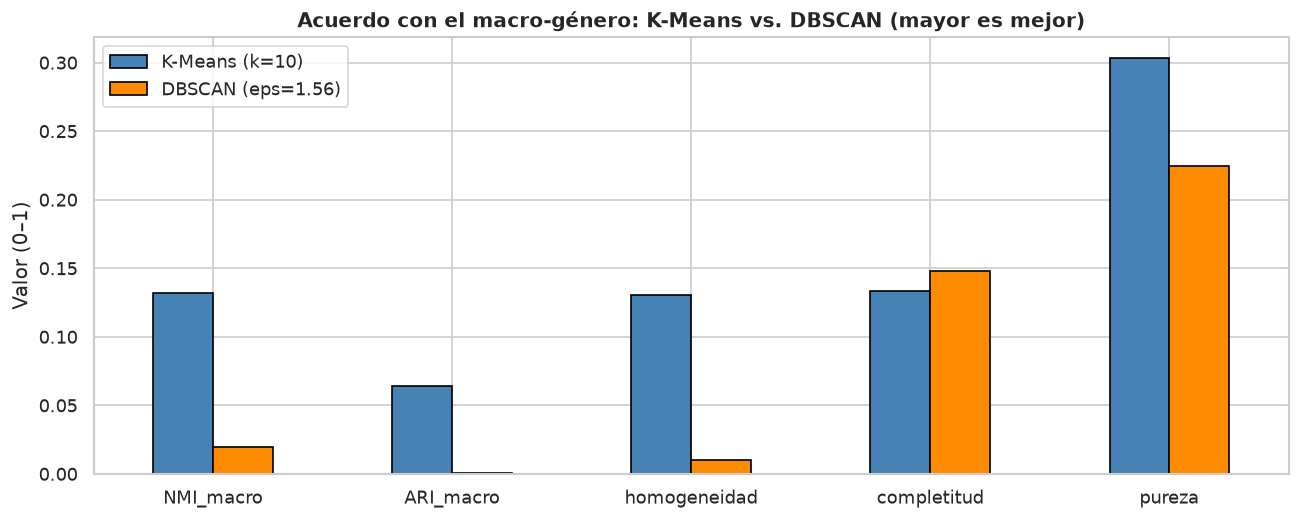

In [38]:
comparacion_ns = pd.DataFrame({
    'K-Means (k=10)': {
        'n_grupos': K_PERFILES, 'pct_ruido': 0.0,
        'silueta': metricas_kmeans['silueta_train'], 'davies_bouldin': metricas_kmeans['davies_bouldin'],
        **metricas_externas(macro_muestra, perfil_muestra),
        'NMI_macro_test': normalized_mutual_info_score(macro_test[idx_muestra_test], perfil_test_muestra),
    },
    f'DBSCAN (eps={EPS})': {
        'n_grupos': metricas_dbscan['n_clusters'], 'pct_ruido': metricas_dbscan['pct_ruido_train'],
        'silueta': metricas_dbscan['silueta_sin_ruido'],
        'davies_bouldin': davies_bouldin_score(Z_muestra[validos], etiquetas_db[validos]),
        **metricas_externas(macro_muestra, etiquetas_db),
        'NMI_macro_test': normalized_mutual_info_score(macro_test[idx_muestra_test], etiquetas_test_db),
    },
}).T
comparacion_ns.to_csv(PROCESSED_DIR / 'comparacion_kmeans_dbscan.csv')
display(comparacion_ns.round(3))

GANADOR_NS = comparacion_ns.sort_values(['NMI_macro', 'ARI_macro'], ascending=False).index[0]
print(f'GANADOR (mayor NMI frente al macro-género; desempate ARI): {GANADOR_NS}')

fig, ax = plt.subplots(figsize=(11, 4.5))
metricas_graf = ['NMI_macro', 'ARI_macro', 'homogeneidad', 'completitud', 'pureza']
comparacion_ns[metricas_graf].T.plot.bar(ax=ax, color=['steelblue', 'darkorange'], edgecolor='black')
ax.set_title('Acuerdo con el macro-género: K-Means vs. DBSCAN (mayor es mejor)', fontweight='bold')
ax.set_ylabel('Valor (0–1)'); ax.tick_params(axis='x', rotation=0); ax.legend(title='')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '13b_comparacion_kmeans_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

#### Veredicto: K-Means gana el objetivo común

| Métrica (misma muestra) | K-Means (k = 10) | DBSCAN (eps = 1,56) | Mejor |
|---|---:|---:|---|
| **NMI vs. macro-género** (criterio) | **0,132** | 0,019 | K-Means |
| ARI vs. macro-género | **0,064** | 0,000 | K-Means |
| Homogeneidad | **0,131** | 0,010 | K-Means |
| Completitud | 0,133 | **0,148** | DBSCAN (trivial: casi todo en un grupo) |
| Pureza | **0,303** | 0,225 | K-Means |
| NMI en prueba | **0,135** | 0,023 | K-Means (generaliza) |
| Silueta | 0,170 | 0,571* | *Engañosa en DBSCAN (99% en un grupo) |
| N.º de grupos / % ruido | 10 / 0% | 2 / 2,3% | — |

- **K-Means es el ganador:** recupera ~7 veces más información sobre el macro-género (NMI)
  que DBSCAN, y lo mantiene en prueba.
- **Ninguno recupera bien los géneros**, porque el audio es un continuo. Aun así, K-Means
  entrega una segmentación **útil para el negocio**: 10 perfiles sonoros interpretables para
  playlists por contexto, varios alineados con familias musicales concretas (clásica,
  electrónica instrumental, brasileña en vivo, comedia).
- **DBSCAN conserva un uso complementario:** detectar el ~2–3% de canciones atípicas, para
  revisión de metadatos y curaduría de nicho.

## Fase 5: Evaluation

Los modelos finales (ajustados en la Fase 4 solo con entrenamiento) se evalúan **una sola
vez** sobre el conjunto de prueba (17.843 canciones nunca vistas, sin claves
artista + título compartidas con entrenamiento).

### 5.1 Regresión en el conjunto de prueba

In [39]:
baseline_reg = Pipeline([('prep', crear_preprocesador()), ('modelo', DummyRegressor())]).fit(X_train, y_train_reg)
predicciones_reg = {'Baseline (media)': baseline_reg.predict(X_test)}
for nombre, modelo in regresores.items():
    predicciones_reg[nombre] = modelo.predict(X_test)

resultados_test_reg = pd.DataFrame({
    nombre: {'MAE': mean_absolute_error(y_test_reg, p),
             'RMSE': root_mean_squared_error(y_test_reg, p),
             'R2': r2_score(y_test_reg, p)}
    for nombre, p in predicciones_reg.items()
}).T
mae_base = resultados_test_reg.loc['Baseline (media)', 'MAE']
resultados_test_reg['mejora_MAE_vs_baseline_%'] = 100 * (1 - resultados_test_reg['MAE'] / mae_base)
resultados_test_reg['MAE_cv'] = resultados_cv_reg['MAE_cv']
resultados_test_reg.to_csv(PROCESSED_DIR / 'resultados_test_regresion.csv')
display(resultados_test_reg.round(3))

MEJOR_REGRESOR = resultados_test_reg.drop('Baseline (media)')['MAE'].idxmin()
mejor_cv_reg = resultados_cv_reg.drop('Baseline (media)')['MAE_cv'].idxmin()
print(f'Mejor regresor en prueba (MAE): {MEJOR_REGRESOR} | mejor en CV: {mejor_cv_reg}')
# La selección oficial se hace con la validación cruzada, para no "elegir con el test".
MEJOR_REGRESOR = mejor_cv_reg

,MAE,RMSE,R2,mejora_MAE_vs_baseline_%,MAE_cv
Baseline (media),17.1670,20.5280,-0.0000,0.0000,17.2680
Árbol de decisión,10.1970,15.3110,0.4440,40.6010,10.4200
KNN,10.7300,15.7240,0.4130,37.4950,11.0800
Random Forest,9.4870,14.4110,0.5070,44.7350,9.6820
HistGradientBoosting,9.2380,14.2050,0.5210,46.1870,9.4220


Mejor regresor en prueba (MAE): HistGradientBoosting | mejor en CV: HistGradientBoosting


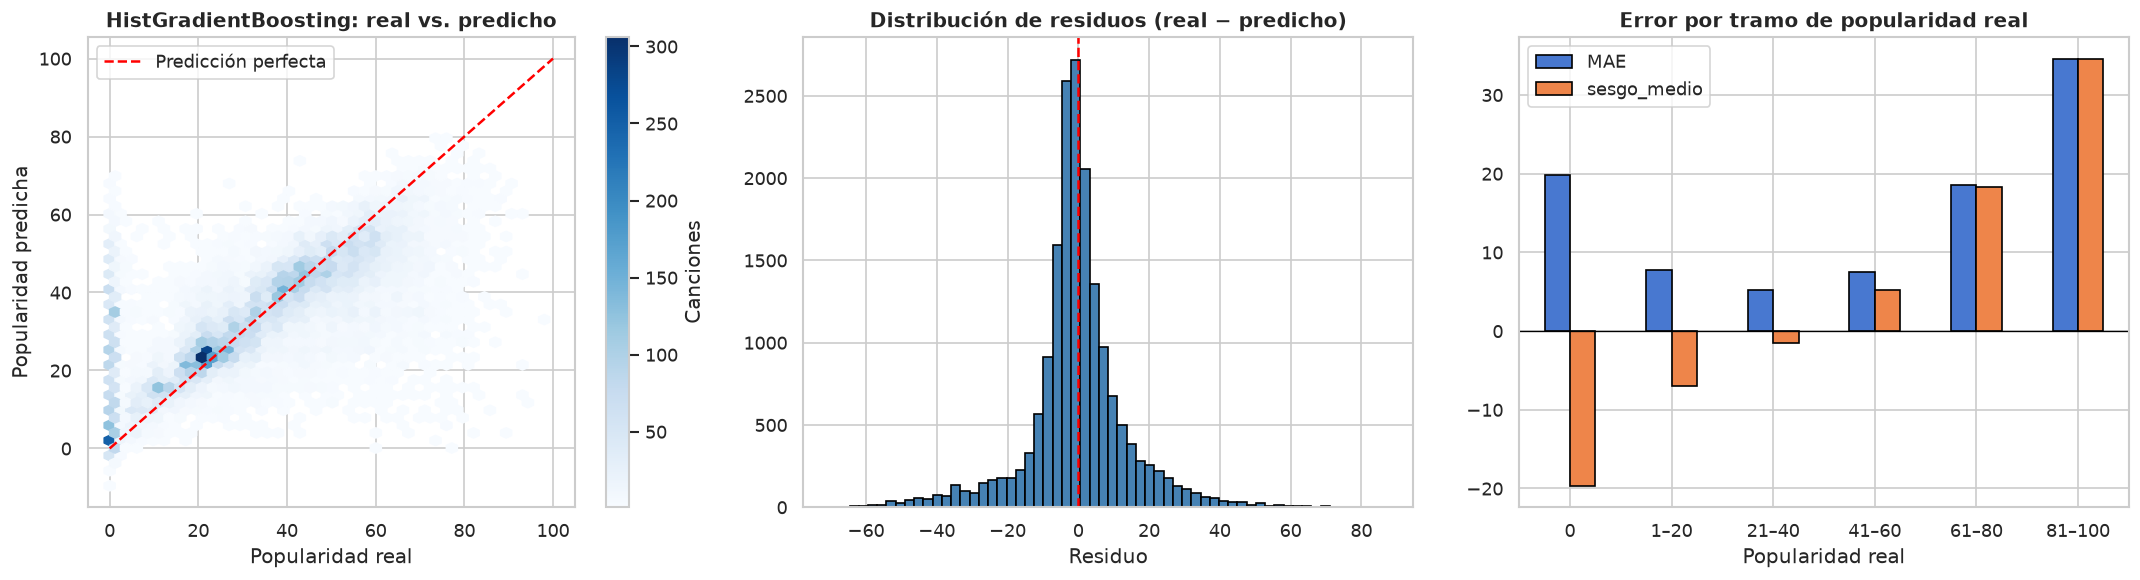

,canciones,MAE,sesgo_medio
tramo,,,
0,1800,19.8100,-19.6600
1–20,3122,7.7500,-6.9900
21–40,6037,5.2700,-1.5800
41–60,5099,7.5500,5.2100
61–80,1689,18.5500,18.2900
81–100,96,34.6200,34.6200


In [40]:
pred = predicciones_reg[MEJOR_REGRESOR]
residuos = y_test_reg.to_numpy() - pred
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hb = axes[0].hexbin(y_test_reg, pred, gridsize=40, cmap='Blues', mincnt=1)
axes[0].plot([0, 100], [0, 100], color='red', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('Popularidad real'); axes[0].set_ylabel('Popularidad predicha')
axes[0].set_title(f'{MEJOR_REGRESOR}: real vs. predicho', fontweight='bold'); axes[0].legend()
fig.colorbar(hb, ax=axes[0], label='Canciones')
axes[1].hist(residuos, bins=60, color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de residuos (real − predicho)', fontweight='bold'); axes[1].set_xlabel('Residuo')
tramos = pd.cut(y_test_reg, [-0.1, 0.5, 20, 40, 60, 80, 100.1], labels=['0', '1–20', '21–40', '41–60', '61–80', '81–100'])
error_tramo = pd.DataFrame({'tramo': tramos, 'error_abs': np.abs(residuos), 'sesgo': residuos}).groupby('tramo', observed=True)
error_tramo.agg(MAE=('error_abs', 'mean'), sesgo_medio=('sesgo', 'mean'))[['MAE', 'sesgo_medio']].plot.bar(ax=axes[2], edgecolor='black')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Error por tramo de popularidad real', fontweight='bold'); axes[2].set_xlabel('Popularidad real')
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '14_regresion_test.png', dpi=150, bbox_inches='tight')
plt.show()
display(error_tramo.agg(canciones=('error_abs', 'size'), MAE=('error_abs', 'mean'), sesgo_medio=('sesgo', 'mean')).round(2))

#### Interpretación — regresión en prueba

- **HistGradientBoosting: MAE 9,24, RMSE 14,21, R² 0,521**, un 46% menos error que el
  baseline. Sin artista, la versión anterior tenía MAE 11,05 y R² 0,41.
- El orden de los modelos se mantiene en prueba: HGB (9,24) < Random Forest (9,49) < árbol de
  decisión (10,20) < KNN (10,73). Los ensambles reducen ~1 punto de MAE respecto del árbol
  individual.
- Las métricas de prueba son iguales o algo mejores que las de CV (MAE 9,42): **no hay
  sobreajuste ni fuga** por el *target encoding*.
- **Dónde falla:** el modelo todavía **se contrae hacia la media**, aunque menos que antes.
  - Las canciones con popularidad 0 se sobreestiman en ~20 puntos (antes ~25). Muchas son
    reediciones con otro ID.
  - Los éxitos de 61–80 se subestiman en ~18 puntos (antes ~23).
  - En el rango 21–40 el MAE es de solo 5,3 puntos.
- **Implicación:** el regresor estima bien el nivel general de una canción. Para
  identificar éxitos puntuales conviene el ranking del clasificador.

### 5.2 Clasificación en el conjunto de prueba

In [41]:
baseline_clf = PipelineImb([('prep', crear_preprocesador()),
                            ('modelo', DummyClassifier(strategy='most_frequent'))]).fit(X_train, y_train_clf)
modelos_eval_clf = {'Baseline (clase mayoritaria)': baseline_clf, **clasificadores}
filas = {}
probabilidades = {}
for nombre, modelo in modelos_eval_clf.items():
    p = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)
    probabilidades[nombre] = pd.DataFrame(proba, columns=modelo.classes_, index=X_test.index)
    filas[nombre] = {
        'balanceo': resultados_cv_clf.loc[nombre, 'balanceo'] if nombre in resultados_cv_clf.index else '—',
        'Accuracy': accuracy_score(y_test_clf, p),
        'Balanced_acc': balanced_accuracy_score(y_test_clf, p),
        'F1_macro': f1_score(y_test_clf, p, average='macro'),
        'Recall_alto': recall_score(y_test_clf, p, labels=['alto'], average='macro', zero_division=0),
        'Precision_alto': precision_score(y_test_clf, p, labels=['alto'], average='macro', zero_division=0),
        'ROC_AUC_ovr': roc_auc_score(y_test_clf, proba, multi_class='ovr', labels=modelo.classes_),
    }
resultados_test_clf = pd.DataFrame(filas).T
resultados_test_clf['AUC_cv'] = resultados_cv_clf['AUC_cv']
resultados_test_clf['F1_macro_cv'] = resultados_cv_clf['F1_macro_cv']
resultados_test_clf.to_csv(PROCESSED_DIR / 'resultados_test_clasificacion.csv')
display(resultados_test_clf.round(3))

print(f'Ganador elegido en CV (ROC-AUC): {MEJOR_CLASIFICADOR}')
print(f'Mayor ROC-AUC en prueba: {resultados_test_clf.drop("Baseline (clase mayoritaria)")["ROC_AUC_ovr"].astype(float).idxmax()}')

,balanceo,Accuracy,Balanced_acc,F1_macro,Recall_alto,Precision_alto,ROC_AUC_ovr,AUC_cv,F1_macro_cv
Baseline (clase mayoritaria),—,0.4485,0.3333,0.2064,0.0000,0.0000,0.5000,0.5000,0.2080
Regresión logística,Sin balanceo,0.7670,0.6508,0.6697,0.3032,0.6409,0.8889,0.8910,0.6720
KNN,Sin balanceo,0.7398,0.6111,0.6285,0.2252,0.6992,0.8688,0.8650,0.6180
Random Forest,Sin balanceo,0.7860,0.6816,0.7008,0.3697,0.6474,0.9063,0.9060,0.6970
HistGradientBoosting,Sin balanceo,0.7897,0.6943,0.7126,0.4092,0.6477,0.9100,0.9090,0.7100


Ganador elegido en CV (ROC-AUC): HistGradientBoosting
Mayor ROC-AUC en prueba: HistGradientBoosting


              precision    recall  f1-score   support

        bajo      0.822     0.856     0.839      8003
       medio      0.779     0.818     0.798      7868
        alto      0.648     0.409     0.502      1972

    accuracy                          0.790     17843
   macro avg      0.749     0.694     0.713     17843
weighted avg      0.784     0.790     0.783     17843



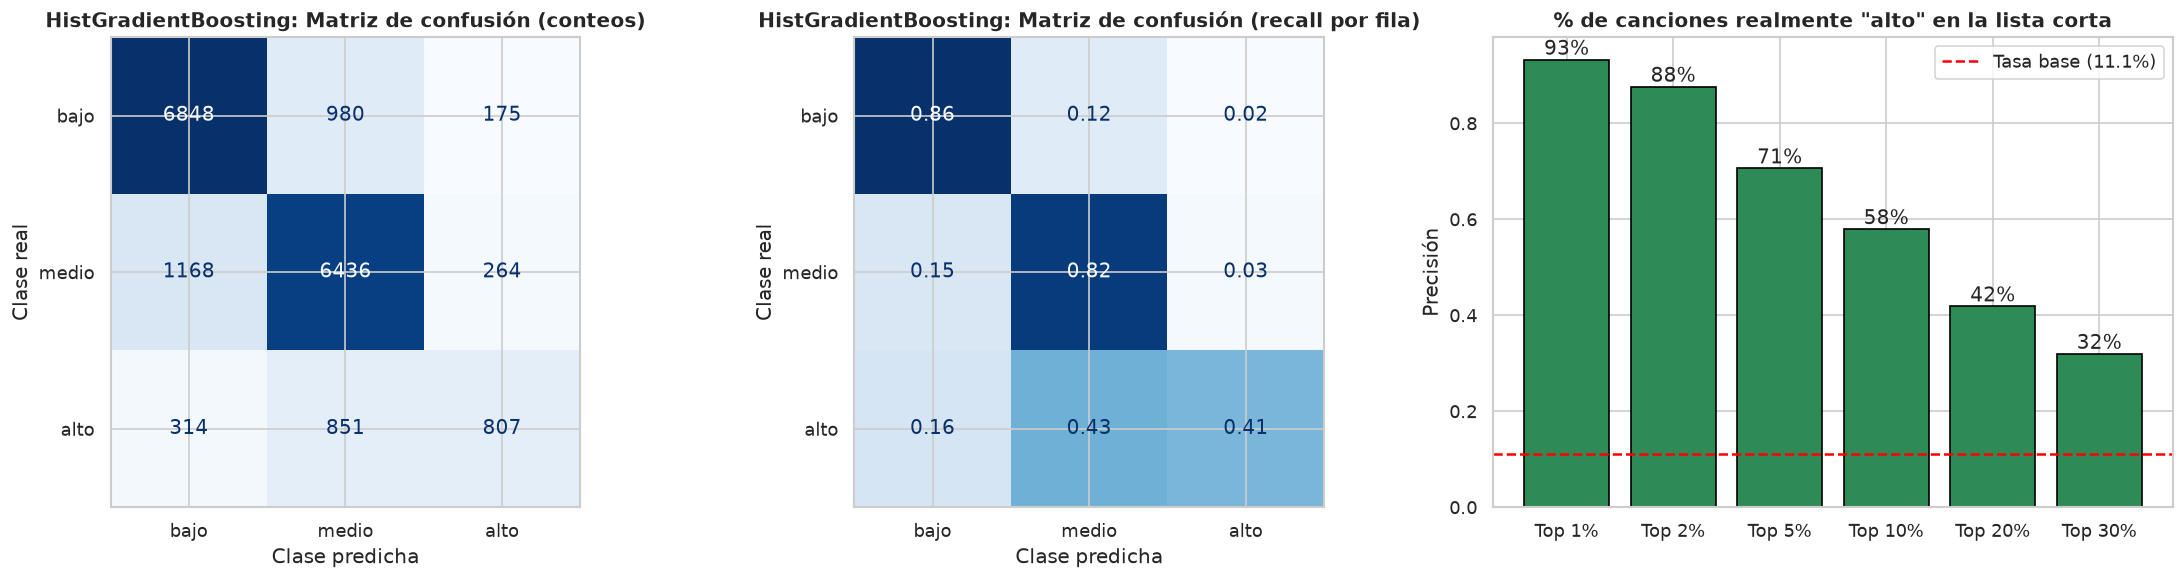

,lista_corta,precision_alto,lift_vs_azar
0,Top 1%,0.9330,8.4380
1,Top 2%,0.8760,7.9300
2,Top 5%,0.7060,6.3910
3,Top 10%,0.5800,5.2440
4,Top 20%,0.4190,3.7890
5,Top 30%,0.3200,2.8930


In [42]:
modelo_clf = clasificadores[MEJOR_CLASIFICADOR]
pred_clf = modelo_clf.predict(X_test)
print(classification_report(y_test_clf, pred_clf, labels=ETIQUETAS_CLASE, digits=3))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, normalizar, titulo in [(axes[0], None, 'Matriz de confusión (conteos)'),
                               (axes[1], 'true', 'Matriz de confusión (recall por fila)')]:
    ConfusionMatrixDisplay.from_predictions(y_test_clf, pred_clf, labels=ETIQUETAS_CLASE, normalize=normalizar,
                                            values_format='.2f' if normalizar else 'd', cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'{MEJOR_CLASIFICADOR}: {titulo}', fontweight='bold')
    ax.set_xlabel('Clase predicha'); ax.set_ylabel('Clase real')

# Lectura de negocio: precisión de una lista corta ordenada por probabilidad de "alto"
p_alto = probabilidades[MEJOR_CLASIFICADOR]['alto']
es_alto = y_test_clf.eq('alto')
porcentajes = [1, 2, 5, 10, 20, 30]
precision_top = [es_alto[p_alto.rank(ascending=False, method='first') <= len(p_alto) * q / 100].mean() for q in porcentajes]
axes[2].bar([f'Top {q}%' for q in porcentajes], precision_top, color='seagreen', edgecolor='black')
axes[2].axhline(es_alto.mean(), color='red', linestyle='--', label=f'Tasa base ({es_alto.mean():.1%})')
for x, v in enumerate(precision_top):
    axes[2].text(x, v, f'{v:.0%}', ha='center', va='bottom')
axes[2].set_title('% de canciones realmente "alto" en la lista corta', fontweight='bold')
axes[2].set_ylabel('Precisión'); axes[2].legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '15_clasificacion_test.png', dpi=150, bbox_inches='tight')
plt.show()
lift = pd.DataFrame({'lista_corta': [f'Top {q}%' for q in porcentajes], 'precision_alto': precision_top})
lift['lift_vs_azar'] = lift['precision_alto'] / es_alto.mean()
display(lift.round(3))

#### 5.2.1 Curvas ROC

1. **Clase "alto" vs. resto, para los 4 modelos:** compara qué modelo ordena mejor las
   canciones según su probabilidad de ser un éxito.
2. **One-vs-rest de las 3 clases para el modelo ganador:** muestra qué clase discrimina mejor.

La diagonal punteada es un clasificador al azar (AUC = 0,5).

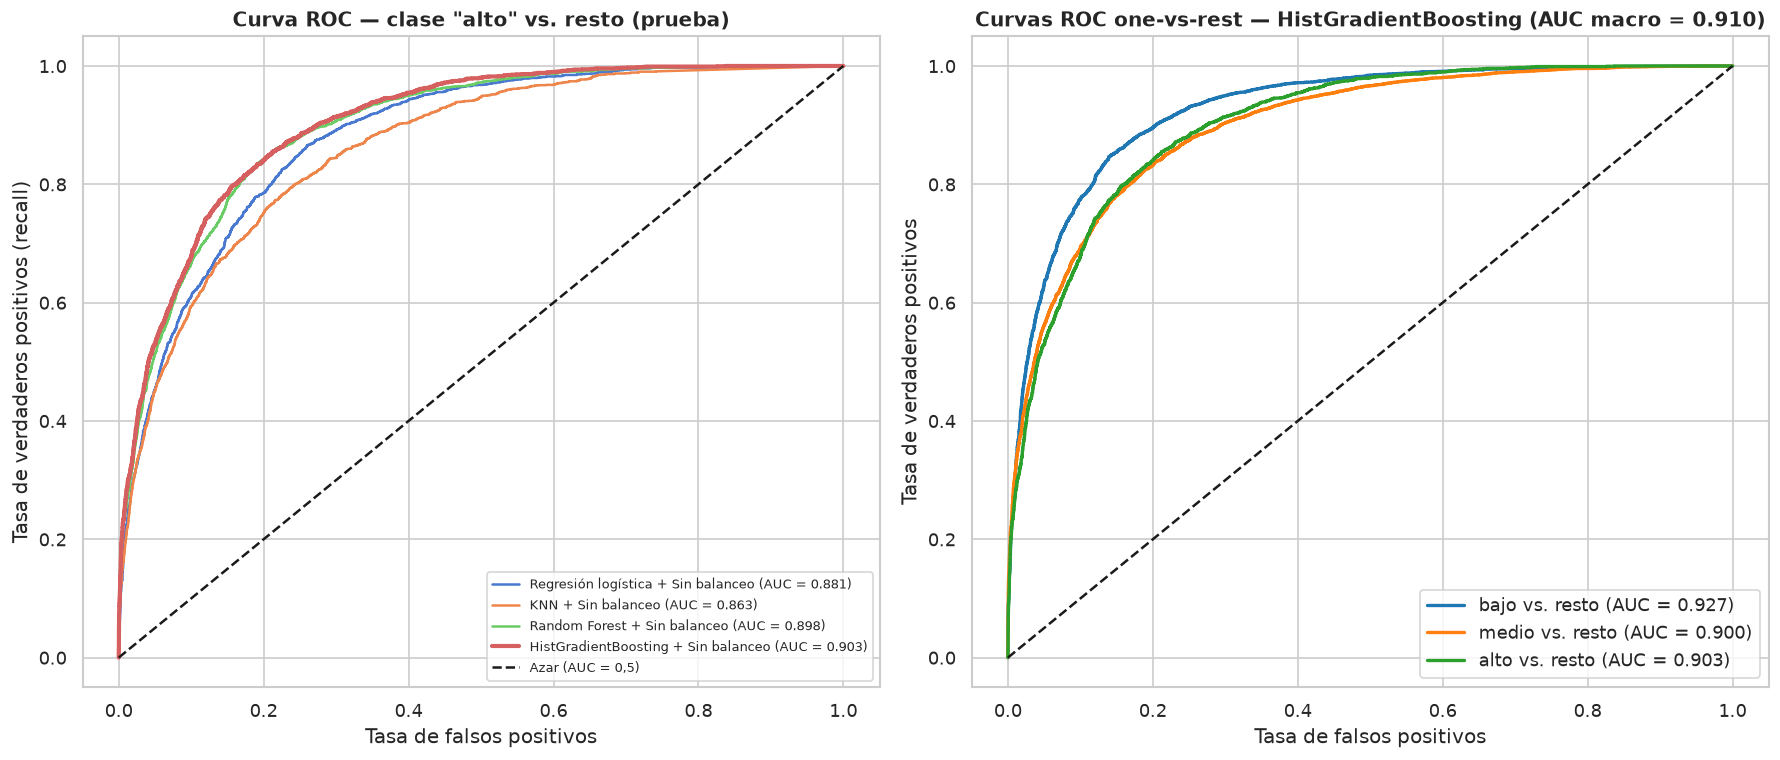

,AUC_alto_vs_resto
modelo,
Regresión logística,0.8812
KNN,0.8626
Random Forest,0.8979
HistGradientBoosting,0.9034


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
es_alto_test = y_test_clf.eq('alto').to_numpy()
filas_auc = []
for nombre in clasificadores:
    fpr, tpr, _ = roc_curve(es_alto_test, probabilidades[nombre]['alto'])
    area = auc(fpr, tpr)
    filas_auc.append({'modelo': nombre, 'AUC_alto_vs_resto': area})
    axes[0].plot(fpr, tpr, linewidth=2.5 if nombre == MEJOR_CLASIFICADOR else 1.5,
                 label=f"{nombre} + {resultados_cv_clf.loc[nombre, 'balanceo']} (AUC = {area:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0,5)')
axes[0].set_title('Curva ROC — clase "alto" vs. resto (prueba)', fontweight='bold')
axes[0].set_xlabel('Tasa de falsos positivos'); axes[0].set_ylabel('Tasa de verdaderos positivos (recall)')
axes[0].legend(fontsize=8, loc='lower right')

colores_clase = {'bajo': 'tab:blue', 'medio': 'tab:orange', 'alto': 'tab:green'}
for clase in ETIQUETAS_CLASE:
    fpr, tpr, _ = roc_curve(y_test_clf.eq(clase).to_numpy(), probabilidades[MEJOR_CLASIFICADOR][clase])
    axes[1].plot(fpr, tpr, color=colores_clase[clase], linewidth=2, label=f'{clase} vs. resto (AUC = {auc(fpr, tpr):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title(f'Curvas ROC one-vs-rest — {MEJOR_CLASIFICADOR} (AUC macro = '
                  f"{resultados_test_clf.loc[MEJOR_CLASIFICADOR, 'ROC_AUC_ovr']:.3f})", fontweight='bold')
axes[1].set_xlabel('Tasa de falsos positivos'); axes[1].set_ylabel('Tasa de verdaderos positivos')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '15b_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()
display(pd.DataFrame(filas_auc).set_index('modelo').round(4))

#### Interpretación — clasificación en prueba y curvas ROC

- **HistGradientBoosting sin balanceo:** ROC-AUC macro 0,910, accuracy 0,790, F1 macro
  0,713. Coincide con la CV (0,909): no hay sobreajuste.
- **Curvas ROC por clase:**
  - "bajo" vs. resto: AUC 0,927, la clase más fácil;
  - "alto" vs. resto: AUC 0,903;
  - "medio" vs. resto: AUC 0,900, la más difícil, porque está entre las otras dos.
- **Curva ROC de "alto" para los 4 modelos:** HGB (0,903) ≥ RF (0,898) > regresión logística
  (0,881) > KNN (0,863). Las curvas de los ensambles quedan por encima en casi todo el
  recorrido.
- **Matiz importante:** con el umbral por defecto, la clase "alto" tiene **precisión 0,65
  pero recall 0,41**. El modelo es conservador: cuando dice "alto" suele acertar, pero deja
  pasar muchos éxitos.
  - La curva ROC muestra que **existe un umbral** con recall ≈ 0,60 y una tasa de falsos
    positivos de ~0,10–0,12.
  - Es decir, el KPI de recall se podría alcanzar **bajando el umbral de "alto"**, sin
    reentrenar ni balancear.
- **Valor de negocio (lista corta):**
  - **el 1% superior por probabilidad de "alto" tiene 93% de éxitos reales** (8,4× la tasa
    base);
  - el 2% superior, 88%;
  - el 5% superior, 71%.

  Para ordenar, el modelo es excelente.

### 5.3 Importancia de variables y sesgo por género

- **Importancia por permutación** (sobre una muestra de 5.000 canciones de prueba): mide
  cuánto empeora el MAE del mejor regresor al desordenar una variable. Las 114 columnas de
  género se permutan **juntas**, como una sola variable "género musical", para que sea
  comparable con las demás. A diferencia de la importancia interna de los árboles, no
  favorece variables con muchos valores distintos.
- **Error por género:** compromiso de la EP1 (matriz de riesgos): el error no debe
  evaluarse solo de forma global.

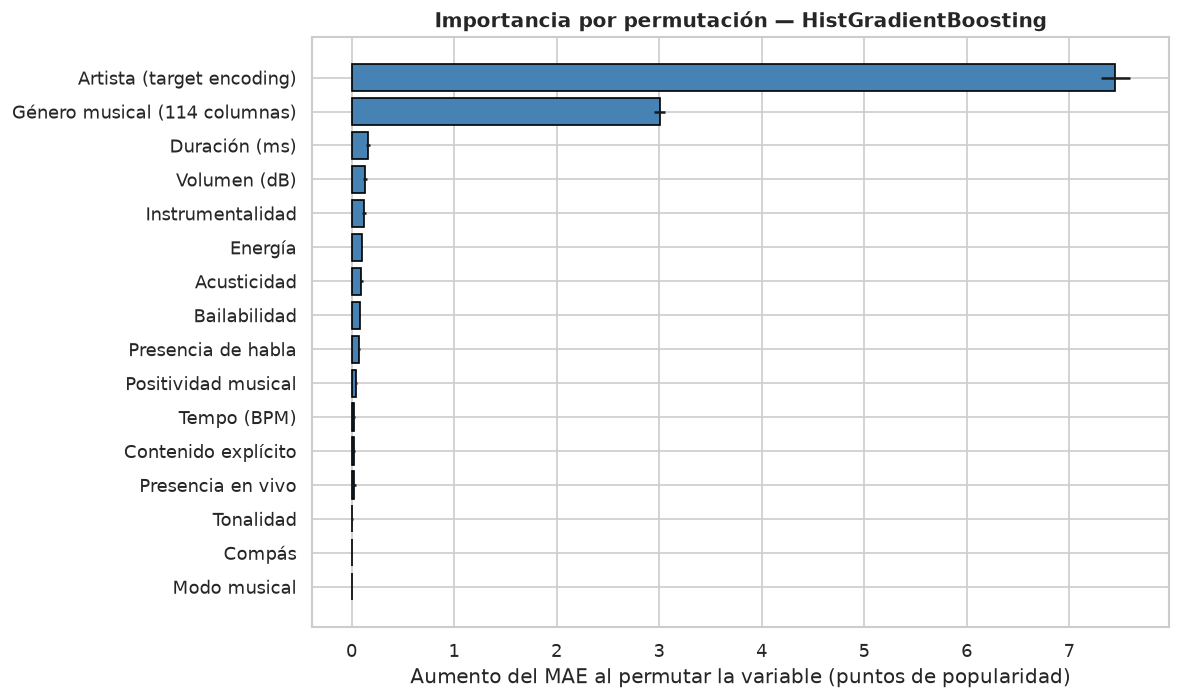

,aumento_MAE,std
variable,,
Artista (target encoding),7.4510,0.1420
Género musical (114 columnas),3.0070,0.0530
Duración (ms),0.1610,0.0230
Volumen (dB),0.1330,0.0180
Instrumentalidad,0.1250,0.0210
Energía,0.1000,0.0060
Acusticidad,0.0950,0.0150
Bailabilidad,0.0800,0.0060
Presencia de habla,0.0720,0.0110


In [44]:
def importancia_permutacion(modelo, X_, y_, grupos_variables, repeticiones=5):
    base = mean_absolute_error(y_, modelo.predict(X_))
    rng_local = np.random.default_rng(SEMILLA)
    filas = []
    for nombre, columnas in grupos_variables.items():
        aumentos = []
        for _ in range(repeticiones):
            Xp = X_.copy()
            orden = rng_local.permutation(len(Xp))
            Xp[columnas] = Xp[columnas].to_numpy()[orden]
            aumentos.append(mean_absolute_error(y_, modelo.predict(Xp)) - base)
        filas.append({'variable': nombre, 'aumento_MAE': np.mean(aumentos), 'std': np.std(aumentos)})
    return pd.DataFrame(filas).set_index('variable').sort_values('aumento_MAE')

muestra_test = X_test.sample(5_000, random_state=SEMILLA)
grupos_variables = {ETIQUETAS[c]: [c] for c in variables_numericas + variables_categoricas_modelo}
grupos_variables['Género musical (114 columnas)'] = columnas_genero
grupos_variables['Artista (target encoding)'] = ['artistas']
importancia = importancia_permutacion(regresores[MEJOR_REGRESOR], muestra_test,
                                      y_test_reg.loc[muestra_test.index], grupos_variables)
importancia.to_csv(PROCESSED_DIR / 'importancia_permutacion.csv')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancia.index, importancia['aumento_MAE'], xerr=importancia['std'], color='steelblue', edgecolor='black')
ax.set_title(f'Importancia por permutación — {MEJOR_REGRESOR}', fontweight='bold')
ax.set_xlabel('Aumento del MAE al permutar la variable (puntos de popularidad)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '16_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
display(importancia.sort_values('aumento_MAE', ascending=False).round(3))

MAE global: 9.24 | MAE por género: mín 2.48, máx 28.92
Géneros con MAE > 1,5 × global: 27 de 114
Género "sleep" (afectado por la limpieza en EP1): MAE 8.20, n = 174


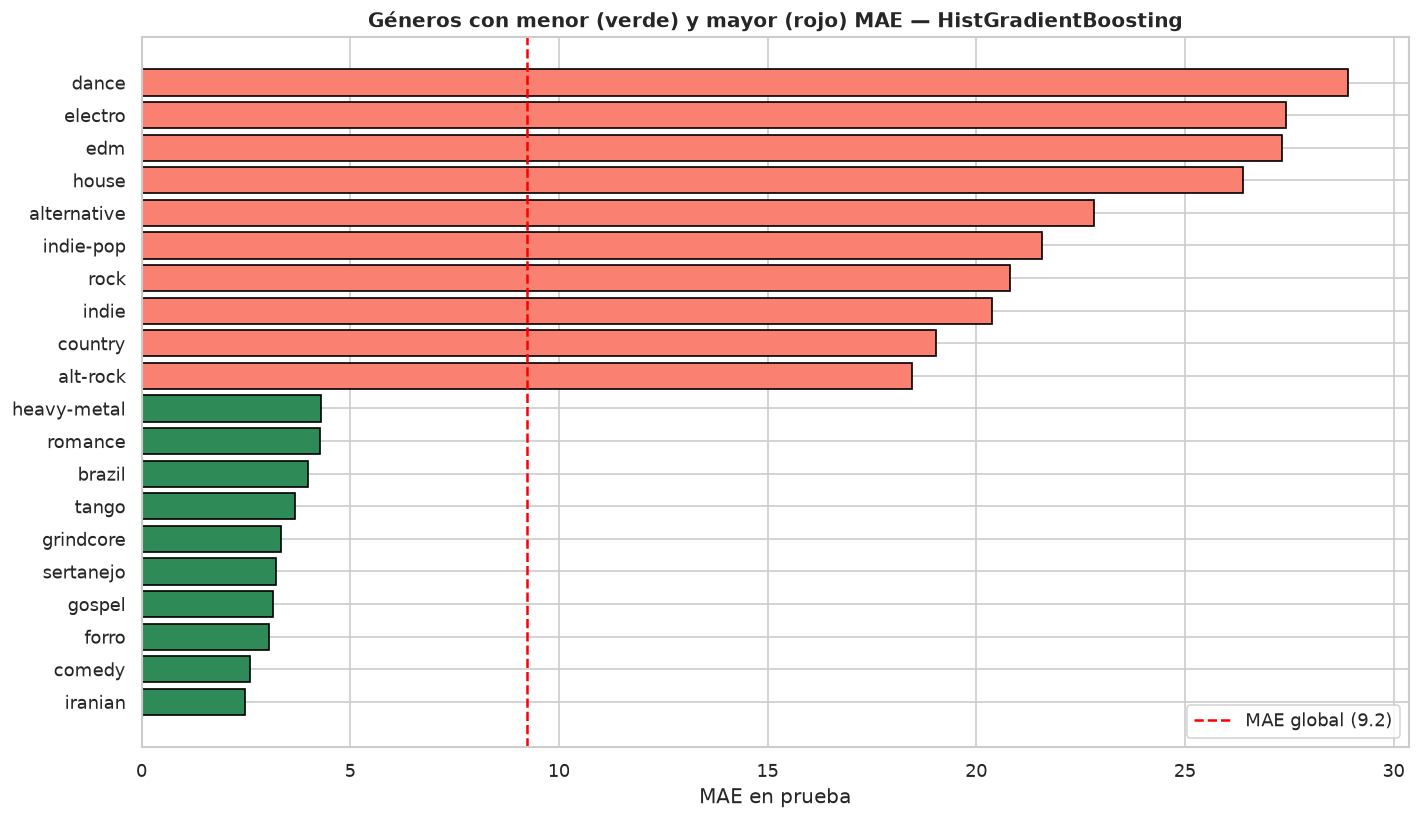

,canciones_test,popularidad_media,MAE,sesgo_medio
genero,,,,
iranian,188,2.0900,2.4800,-0.5300
comedy,185,24.5100,2.6100,0.1200
forro,200,41.6700,3.0500,-0.3700
gospel,195,41.6500,3.1600,-0.7500
sertanejo,181,47.8500,3.2300,0.7200
grindcore,213,14.5400,3.3500,-0.8600
tango,194,20.1200,3.6900,0.1800
brazil,189,45.1800,3.9800,0.5200
romance,166,3.8500,4.2800,-0.3300


Correlación entre popularidad media del género y su MAE: 0.06


In [45]:
filas_genero = []
abs_error = np.abs(y_test_reg.to_numpy() - predicciones_reg[MEJOR_REGRESOR])
for g in columnas_genero:
    mascara = X_test[g].eq(1).to_numpy()
    if mascara.sum() >= 30:
        filas_genero.append({'genero': g.replace('genero_', ''), 'canciones_test': int(mascara.sum()),
                             'popularidad_media': y_test_reg.to_numpy()[mascara].mean(),
                             'MAE': abs_error[mascara].mean(),
                             'sesgo_medio': (y_test_reg.to_numpy() - predicciones_reg[MEJOR_REGRESOR])[mascara].mean()})
error_genero = pd.DataFrame(filas_genero).set_index('genero').sort_values('MAE')
error_genero.to_csv(PROCESSED_DIR / 'errores_por_genero.csv')
mae_global = abs_error.mean()
print(f'MAE global: {mae_global:.2f} | MAE por género: mín {error_genero["MAE"].min():.2f}, '
      f'máx {error_genero["MAE"].max():.2f}')
print(f'Géneros con MAE > 1,5 × global: {(error_genero["MAE"] > 1.5 * mae_global).sum()} de {len(error_genero)}')
if 'sleep' in error_genero.index:
    print(f'Género "sleep" (afectado por la limpieza en EP1): MAE {error_genero.loc["sleep", "MAE"]:.2f}, '
          f'n = {error_genero.loc["sleep", "canciones_test"]}')

fig, ax = plt.subplots(figsize=(12, 7))
extremos = pd.concat([error_genero.head(10), error_genero.tail(10)])
colores = ['seagreen'] * 10 + ['salmon'] * 10
ax.barh(extremos.index, extremos['MAE'], color=colores, edgecolor='black')
ax.axvline(mae_global, color='red', linestyle='--', label=f'MAE global ({mae_global:.1f})')
ax.set_title(f'Géneros con menor (verde) y mayor (rojo) MAE — {MEJOR_REGRESOR}', fontweight='bold')
ax.set_xlabel('MAE en prueba'); ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '17_error_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()
display(extremos.round(2))
print(f'Correlación entre popularidad media del género y su MAE: '
      f'{error_genero["popularidad_media"].corr(error_genero["MAE"]):.2f}')

#### 5.3.1 Desempeño según si el artista es conocido o nuevo

El *target encoding* solo ayuda cuando el artista aparece en entrenamiento. Se separan las
canciones de prueba en **artista conocido** y **artista nuevo**, y se compara el modelo final
con una réplica sin la variable artista (mismos hiperparámetros, entrenada igual).

In [46]:
regresor_sin_artista = clone(regresores[MEJOR_REGRESOR]).set_params(prep=crear_preprocesador(con_artista=False))
regresor_sin_artista.fit(X_train, y_train_reg)
pred_sin_artista = regresor_sin_artista.predict(X_test)
conocido = artista_conocido_test.to_numpy()
filas = []
for grupo_artista, mascara in [('Artista conocido', conocido), ('Artista nuevo', ~conocido), ('Total', np.ones_like(conocido))]:
    yr, yc = y_test_reg.to_numpy()[mascara], y_test_clf.to_numpy()[mascara]
    filas.append({
        'grupo': grupo_artista, 'canciones': int(mascara.sum()),
        'MAE_con_artista': mean_absolute_error(yr, predicciones_reg[MEJOR_REGRESOR][mascara]),
        'MAE_sin_artista': mean_absolute_error(yr, pred_sin_artista[mascara]),
        'R2_con_artista': r2_score(yr, predicciones_reg[MEJOR_REGRESOR][mascara]),
        'R2_sin_artista': r2_score(yr, pred_sin_artista[mascara]),
        f'F1_macro_{MEJOR_CLASIFICADOR}': f1_score(yc, pred_clf[mascara], average='macro'),
        'Recall_alto': recall_score(yc, pred_clf[mascara], labels=['alto'], average='macro', zero_division=0),
    })
desempeno_artista = pd.DataFrame(filas).set_index('grupo')
desempeno_artista.to_csv(PROCESSED_DIR / 'desempeno_artista_conocido_nuevo.csv')
display(desempeno_artista.round(3))

,canciones,MAE_con_artista,MAE_sin_artista,R2_con_artista,R2_sin_artista,F1_macro_HistGradientBoosting,Recall_alto
grupo,,,,,,,
Artista conocido,12888,8.4320,10.6170,0.5730,0.4370,0.7270,0.4120
Artista nuevo,4955,11.3360,12.1710,0.3820,0.3280,0.6700,0.4040
Total,17843,9.2380,11.0480,0.5210,0.4100,0.7130,0.4090


#### Interpretación — importancia, sesgo por género y artistas nuevos

- **Importancia por permutación:**
  - el **artista** es la variable más importante (+7,5 de MAE al permutarlo), seguido por
    el **género** (+3,0);
  - las variables de audio aportan poco por separado (≤ 0,16 cada una), y las más útiles
    son duración, volumen e instrumentalidad;
  - tonalidad, compás y modo no aportan nada.

  **Respuesta al problema de negocio:** la popularidad depende sobre todo de **quién**
  publica la canción y en qué escena (género), no de cómo suena.
- **Sesgo por género:**
  - el MAE va de 2,5 (iranian, comedy) a 28,9 (dance), y en 27 de 114 géneros supera 1,5
    veces el global;
  - el error no depende de la popularidad media del género (r = 0,06), sino de su
    **heterogeneidad**: hay géneros que mezclan éxitos con reediciones de popularidad 0;
  - en electrónica, dance, rock, indie y country, las predicciones deben usarse con cautela;
  - el género `sleep`, el más afectado por la limpieza de EP1, tiene un MAE de 8,2, menor
    que el global: **no se observa perjuicio**.
- **Artista conocido vs. nuevo (5.3.1):**

| Grupo | Canciones | MAE con artista | MAE sin artista | R² con artista | R² sin artista |
|---|---:|---:|---:|---:|---:|
| Artista conocido | 12.888 (72%) | **8,43** | 10,62 | **0,57** | 0,44 |
| Artista nuevo | 4.955 (28%) | 11,34 | 12,17 | 0,38 | 0,33 |

  - La ganancia se concentra en los **artistas ya presentes en el catálogo**.
  - Para artistas nuevos, el modelo con artista sigue algo mejor (MAE 11,3 vs. 12,2),
    porque en una colaboración puede aparecer un artista conocido. Aun así, su desempeño
    es parecido al del modelo sin artista.
  - El F1 macro baja de 0,73 (artista conocido) a 0,67 (artista nuevo); el recall de "alto"
    es similar en ambos grupos (~0,41).
  - **Riesgo ético (efecto Mateo):** el modelo favorece a artistas ya populares. Para
    descubrir talento nuevo debe complementarse con el modelo sin artista y con curaduría
    humana.

### 5.4 Cumplimiento de KPIs

In [47]:
r_reg = resultados_test_reg.loc[MEJOR_REGRESOR]
r_clf = resultados_test_clf.loc[MEJOR_CLASIFICADOR]
kpis = pd.DataFrame([
    ('Cobertura de datos', 'Calidad', '≥ 0,99', len(df_limpio) / len(df_crudo), len(df_limpio) / len(df_crudo) >= 0.99),
    ('Claves artista+título compartidas train/test', 'Calidad', '0', len(compartidas), len(compartidas) == 0),
    (f'MAE ({MEJOR_REGRESOR})', 'Regresión', '< 10', r_reg['MAE'], r_reg['MAE'] < 10),
    (f'RMSE ({MEJOR_REGRESOR})', 'Regresión', '< 15', r_reg['RMSE'], r_reg['RMSE'] < 15),
    (f'R² ({MEJOR_REGRESOR})', 'Regresión', '> 0,20', r_reg['R2'], r_reg['R2'] > 0.20),
    (f'Accuracy ({MEJOR_CLASIFICADOR})', 'Clasificación', '> 0,50', r_clf['Accuracy'], r_clf['Accuracy'] > 0.50),
    (f'F1 macro ({MEJOR_CLASIFICADOR})', 'Clasificación', '> 0,45', r_clf['F1_macro'], r_clf['F1_macro'] > 0.45),
    (f'Recall "alto" ({MEJOR_CLASIFICADOR})', 'Clasificación', '≥ 0,60', r_clf['Recall_alto'], r_clf['Recall_alto'] >= 0.60),
    (f'ROC-AUC macro ({MEJOR_CLASIFICADOR})', 'Clasificación', '≥ 0,80', r_clf['ROC_AUC_ovr'], r_clf['ROC_AUC_ovr'] >= 0.80),
    (f'Silueta K-Means (k={K_PERFILES}, prueba)', 'No supervisado', '≥ 0,15', metricas_kmeans['silueta_test'],
     metricas_kmeans['silueta_test'] >= 0.15),
], columns=['KPI', 'Tipo', 'Umbral', 'Valor', 'Cumple'])
kpis['Valor'] = kpis['Valor'].astype(float).round(3)
kpis['Cumple'] = np.where(kpis['Cumple'], '✅ Sí', '❌ No')
kpis.to_csv(PROCESSED_DIR / 'kpis_ep2.csv', index=False)
display(kpis)

,KPI,Tipo,Umbral,Valor,Cumple
0,Cobertura de datos,Calidad,"≥ 0,99",0.9990,✅ Sí
1,Claves artista+título compartidas train/test,Calidad,0,0.0000,✅ Sí
2,MAE (HistGradientBoosting),Regresión,< 10,9.2380,✅ Sí
3,RMSE (HistGradientBoosting),Regresión,< 15,14.2050,✅ Sí
4,R² (HistGradientBoosting),Regresión,"> 0,20",0.5210,✅ Sí
5,Accuracy (HistGradientBoosting),Clasificación,"> 0,50",0.7900,✅ Sí
6,F1 macro (HistGradientBoosting),Clasificación,"> 0,45",0.7130,✅ Sí
7,"Recall ""alto"" (HistGradientBoosting)",Clasificación,"≥ 0,60",0.4090,❌ No
8,ROC-AUC macro (HistGradientBoosting),Clasificación,"≥ 0,80",0.9100,✅ Sí
9,"Silueta K-Means (k=10, prueba)",No supervisado,"≥ 0,15",0.1640,✅ Sí


#### Interpretación de KPIs

Se cumplen **9 de 10 KPIs**. Los umbrales son los definidos antes de evaluar; no se ajustaron.

- **Regresión:** MAE 9,24 < 10, RMSE 14,21 < 15 y R² 0,52 > 0,20.
- **Clasificación:** ROC-AUC 0,91 ≥ 0,80, accuracy 0,79 y F1 macro 0,71.
- **No supervisado:** la silueta de K-Means en prueba es 0,16 ≥ 0,15, con margen estrecho por
  usar k = 10.
- **❌ Recall de "alto" = 0,41 < 0,60.** Es consecuencia directa de elegir el modelo por
  ROC-AUC: el ganador no usa balanceo y aplica el umbral por defecto.
  - Con el criterio anterior (F1 macro), el ganador era Random Forest + ROS, con recall 0,61.
  - Como la curva ROC muestra que con otro umbral se alcanza recall ≈ 0,60, la solución
    recomendada es **calibrar el umbral de decisión de la clase "alto"** en validación
    cruzada.

**Matiz adicional:** para canciones de artistas nuevos (28% de la prueba), el MAE es 11,3 y
no cumpliría el KPI de regresión.

## Fase 6: Deployment (propuesta)

Se serializan los artefactos necesarios para reutilizar los modelos sin reentrenar.
Cada archivo es un **pipeline completo** (preprocesamiento + modelo), por lo que recibe
las variables originales en el mismo formato que `X` (sección 3.13), incluidas `artistas` y
`nombre_cancion`. Para cargarlos fuera del notebook, la carpeta `src/` (transformador
`CodificadorArtista`) debe estar disponible en el `PYTHONPATH`.

In [48]:
artefactos = {
    'regresor_popularidad.joblib': regresores[MEJOR_REGRESOR],
    'clasificador_popularidad.joblib': clasificadores[MEJOR_CLASIFICADOR],
    'kmeans_perfiles_sonoros.joblib': Pipeline([('escalador', escalador_cluster), ('kmeans', kmeans)]),
}
LIMITE_MB = 50  # GitHub rechaza archivos > 100 MB; se deja margen.
for archivo, objeto in artefactos.items():
    ruta = MODELS_DIR / archivo
    joblib.dump(objeto, ruta, compress=('xz', 6))
    tamano = ruta.stat().st_size / 1e6
    if tamano > LIMITE_MB:
        ruta.unlink()
        print(f'{archivo}: {tamano:.1f} MB > {LIMITE_MB} MB, no se guarda (se regenera ejecutando este notebook).')
    else:
        print(f'{archivo}: {tamano:.2f} MB')

def cargar_o_usar(archivo, objeto_en_memoria):
    ruta = MODELS_DIR / archivo
    return joblib.load(ruta) if ruta.is_file() else objeto_en_memoria

# Ejemplo de uso: cargar y predecir 3 canciones de prueba
regresor_cargado = cargar_o_usar('regresor_popularidad.joblib', regresores[MEJOR_REGRESOR])
clasificador_cargado = cargar_o_usar('clasificador_popularidad.joblib', clasificadores[MEJOR_CLASIFICADOR])
ejemplo = X_test.head(3)
display(pd.DataFrame({
    'cancion': df_modelo['nombre_cancion'].iloc[idx_test[:3]].to_numpy(),
    'popularidad_real': y_test_reg.head(3).to_numpy(),
    'popularidad_predicha': regresor_cargado.predict(ejemplo).round(1),
    'clase_real': y_test_clf.head(3).to_numpy(),
    'clase_predicha': clasificador_cargado.predict(ejemplo),
    'prob_alto': clasificador_cargado.predict_proba(ejemplo)[:, list(clasificador_cargado.classes_).index('alto')].round(3),
}))

regresor_popularidad.joblib: 1.54 MB


clasificador_popularidad.joblib: 2.20 MB
kmeans_perfiles_sonoros.joblib: 0.03 MB


,cancion,popularidad_real,popularidad_predicha,clase_real,clase_predicha,prob_alto
0,Addiction,21.0000,17.2000,bajo,bajo,0.0010
1,"Hips, Tits, Lips, Power!",20.0000,26.6000,bajo,bajo,0.0210
2,Got You On My Mind,58.0000,50.5000,medio,alto,0.5740


**Uso propuesto y monitoreo**

| Aspecto | Propuesta |
|---|---|
| Uso | Herramienta de **apoyo** a la curaduría: ordenar lanzamientos por probabilidad de "alto" y proponer una lista corta para revisión humana; los perfiles sonoros (K-Means) alimentan playlists temáticas y los nichos/atípicas de DBSCAN apoyan la curaduría de catálogos especializados y el control de calidad de metadatos. No se usa para decisiones automáticas sobre artistas. |
| Entradas | Atributos de audio de la API de Spotify, género(s), contenido explícito, tonalidad, modo, compás y artista(s). |
| Monitoreo | Recalcular mensualmente MAE, F1 macro y recall "alto" con canciones nuevas cuya popularidad ya se observó; vigilar la deriva de las variables de entrada (p. ej., distribución de energía y géneros) y el error por género. |
| Reentrenamiento | Cuando el F1 macro caiga más de 0,05 respecto de esta línea base, o se incorporen géneros nuevos. |
| Riesgos | El artista refuerza el **efecto Mateo**: favorece a artistas ya populares y no aporta nada para artistas nuevos (sección 5.3.1). Ciclo de retroalimentación (lo que se promociona se vuelve popular), popularidad dependiente del momento de extracción, sesgo de la limpieza sobre `sleep`. Mantener supervisión humana. |

## Conclusiones y recomendaciones

1. **Metodología:** se completó el ciclo CRISP-DM. La revisión del EP1 corrigió una fuga de
   información real (reediciones), la sobrerrepresentación multi-género y un target de
   clasificación sin significado de negocio.
2. **El artista es el predictor más importante.** Con *target encoding* sin fuga, el R² pasa
   de 0,41 a 0,52. La ganancia se concentra en artistas con historial (efecto Mateo).
3. **Regresión (4 modelos no lineales):** HistGradientBoosting gana (MAE 9,24; R² 0,52). El
   árbol de decisión (MAE 10,20) muestra la base del método, y los ensambles (RF, HGB) reducen
   su error al combinar muchos árboles.
4. **Clasificación (criterio ROC-AUC):**
   - **Ganador: HistGradientBoosting sin balanceo** (AUC 0,91).
   - En el 1% superior del ranking, el 93% son éxitos reales.
   - Con el umbral por defecto, el recall de "alto" es bajo (0,41).
5. **Balanceo (19 combinaciones probadas):**
   - Ninguna técnica mejora el AUC: el balanceo cambia el umbral, no la capacidad de ordenar.
   - Sí sube el recall de "alto" a ~0,7–0,8, con más falsos positivos.
   - `class_weight` es la técnica que mejor equilibra AUC y F1.
6. **No supervisado (mismo objetivo: recuperar el macro-género desde el audio):**
   - **K-Means gana** (NMI 0,13 vs. 0,02; pureza 30% vs. 22%) y entrega 10 perfiles sonoros
     interpretables.
   - **DBSCAN** solo aísla un nicho de comedia y un 2–3% de canciones atípicas.
   - El **PCA 3D** confirma que el audio forma un continuo sin "islas" por género.
7. **Hallazgo central:** la popularidad, y también la identidad de género, dependen mucho más
   de **quién** publica (artista) y de su **contexto cultural** que de **cómo suena** la
   canción.
8. **Recomendaciones:**
   - Usar el clasificador para **rankear** lanzamientos (lista corta para curadores), con
     revisión humana.
   - Si se requiere etiquetar "alto" con recall ≥ 0,60, **bajar el umbral de decisión**
     (calibrado en validación cruzada) o usar `class_weight`.
   - Para artistas nuevos, consultar también el modelo sin artista.
   - Usar los perfiles K-Means para playlists por contexto, y las atípicas de DBSCAN para
     revisión de metadatos.